device: cpu
FEDERATED MULTITASK + MIDDLE MRI FUSION + OPTUNA
SEEDS 42-46 | T2 + T4 + T6 | 100 FL ROUNDS

[1] Loading data once for all horizons.
[FOUND] Demographics.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/Demographics.csv
[FOUND] Epworth_Sleepiness_Scale.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/Epworth_Sleepiness_Scale.csv
[FOUND] MDS-UPDRS_Part_I.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/MDS-UPDRS_Part_I.csv
[FOUND] MDS-UPDRS_Part_IV.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/MDS-UPDRS_Part_IV.csv
[FOUND] REM_Sleep_Behavior.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/REM_Sleep_Behavior.csv
[FOUND] SCOPA-AUT.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladie/SCOPA-AUT.csv
[FOUND] Geriatric_Depression_Scale.csv -> /kaggle/input/datasets/ANONYMIZED_USER/dataset-maladie/dataset maladi

[I 2026-08-29 13:30:39,402] A new study created in memory with name: no-name-993fb09d-30f0-469f-9eb9-5c065080d4d0


[I 2026-08-29 13:30:57,142] Trial 0 finished with value: 0.4436933100223541 and parameters: {'lr': 0.00043284502212938834, 'dropout': 0.4802857225639665, 'class_power': 1.731993941811405, 'focal_gamma_sub': 2.197316968394073, 'focal_gamma_dep': 1.312037280884873, 'focal_gamma_lvl': 1.3119890406724053, 'mri_proj_dim': 64, 'd_model': 256, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 512, 'gru_hidden': 64, 'gru_layers': 1, 'shared_dim': 256, 'weight_decay': 2.5081156860452307e-05, 'input_noise_std': 0.02571172192068058, 'label_smoothing': 0.05924145688620425}. Best is trial 0 with value: 0.4436933100223541.
[I 2026-08-29 13:31:09,017] Trial 1 finished with value: 0.5516417026519775 and parameters: {'lr': 0.00011992724522955161, 'dropout': 0.34301794076057535, 'class_power': 1.1705241236872914, 'focal_gamma_sub': 1.130103185970559, 'focal_gamma_dep': 2.8977710745066663, 'focal_gamma_lvl': 2.9312640661491187, 'mri_proj_dim': 32, 'd_model': 64, 'nhead': 8, 'num_layers': 2, 'dim_feedforwar

BEST PARAMS: {'lr': 0.00033803867040308394, 'dropout': 0.1023988731823269, 'class_power': 1.9695371107878659, 'focal_gamma_sub': 1.7346300757182669, 'focal_gamma_dep': 2.0050624353495925, 'focal_gamma_lvl': 1.9099560445743173, 'mri_proj_dim': 128, 'd_model': 128, 'nhead': 2, 'num_layers': 3, 'dim_feedforward': 1024, 'gru_hidden': 32, 'gru_layers': 2, 'shared_dim': 128, 'weight_decay': 0.0009532933710210794, 'input_noise_std': 0.04677809380407124, 'label_smoothing': 0.0016169242872281237, 'class_power_subtype': 1.9695371107878659, 'label_smoothing_subtype': 0.0016169242872281237}
BEST CV SCORE: 0.9190828204154968

----------------------------------------------------------------------
T2 | FINAL FIXED SPLIT 70/15/15 | SEED 42
----------------------------------------------------------------------
[T2][Split 70/15/15] Training mode: federated (IMPROVED)

[NON-IID CLIENTS] (separation par patient verifiee: aucun doublon)
mode=label_modality | dirichlet_alpha=12.000 | n_clients=3
Client 1: n

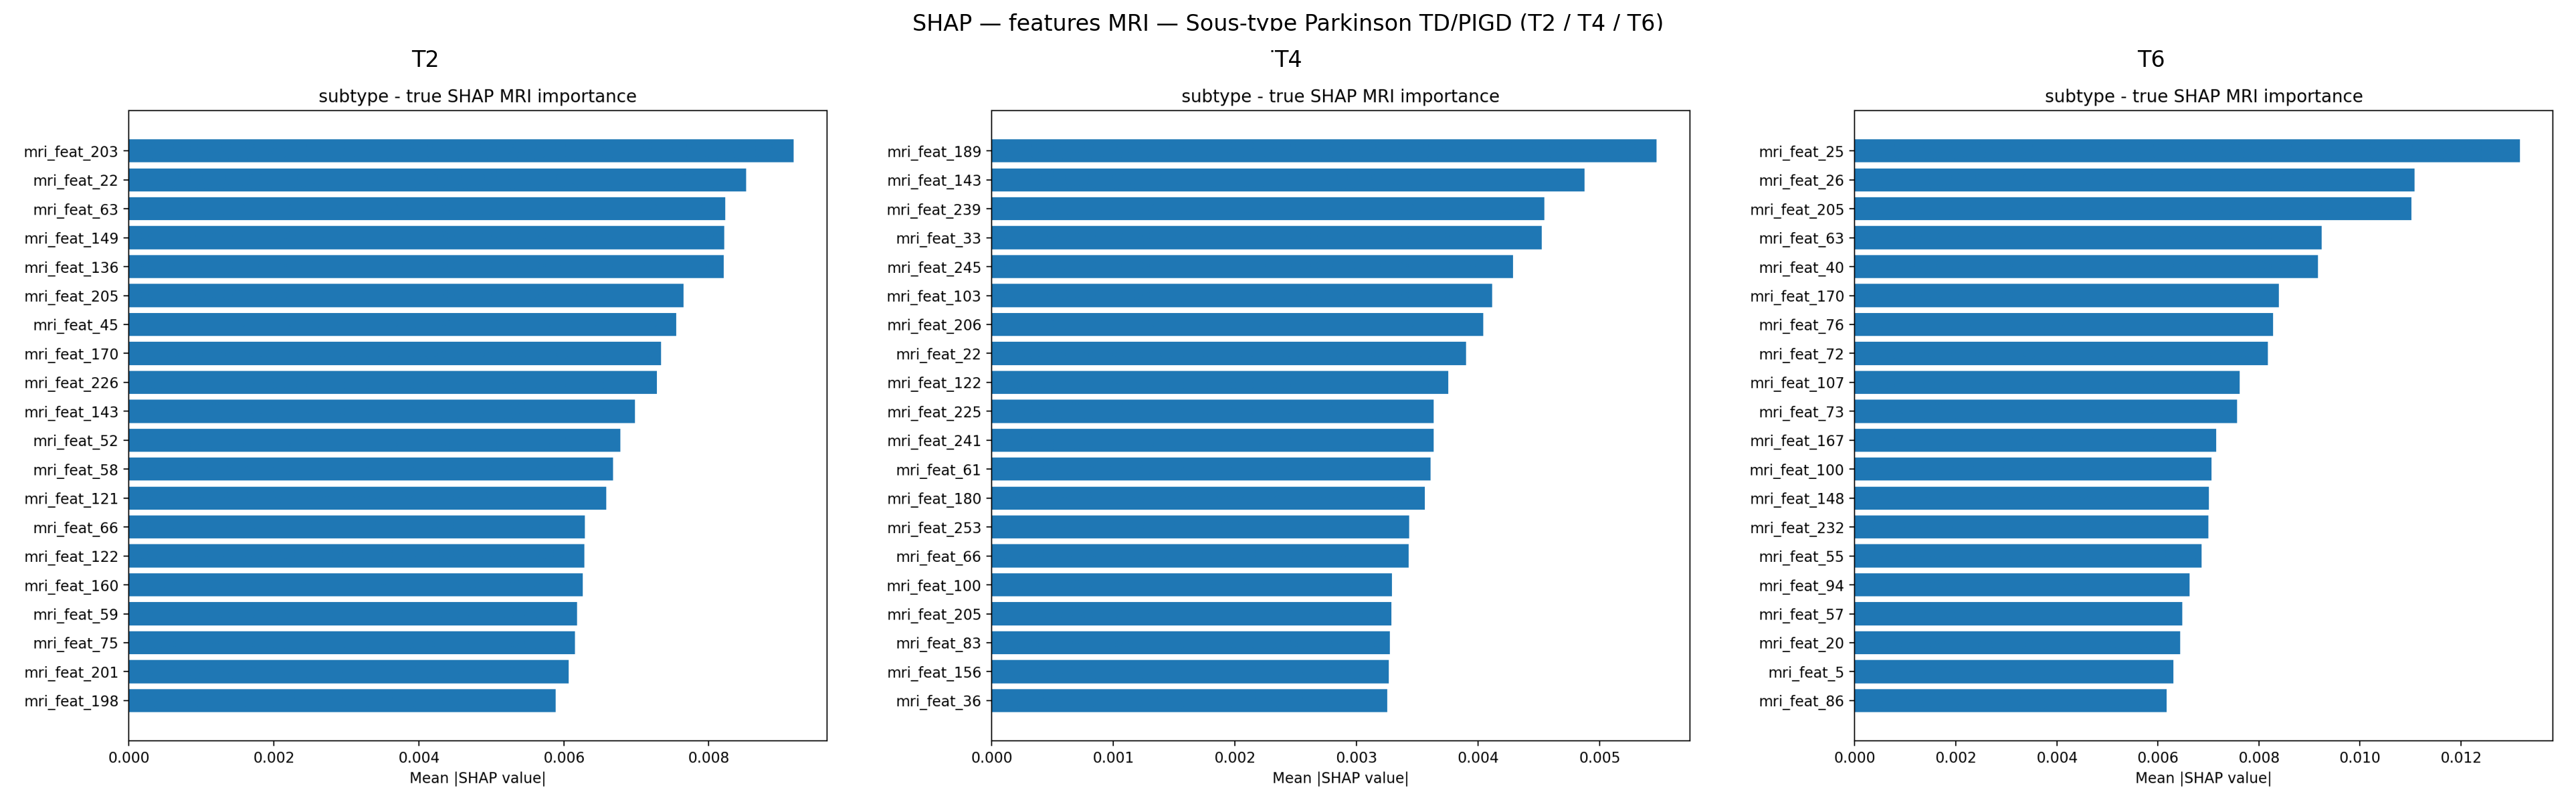

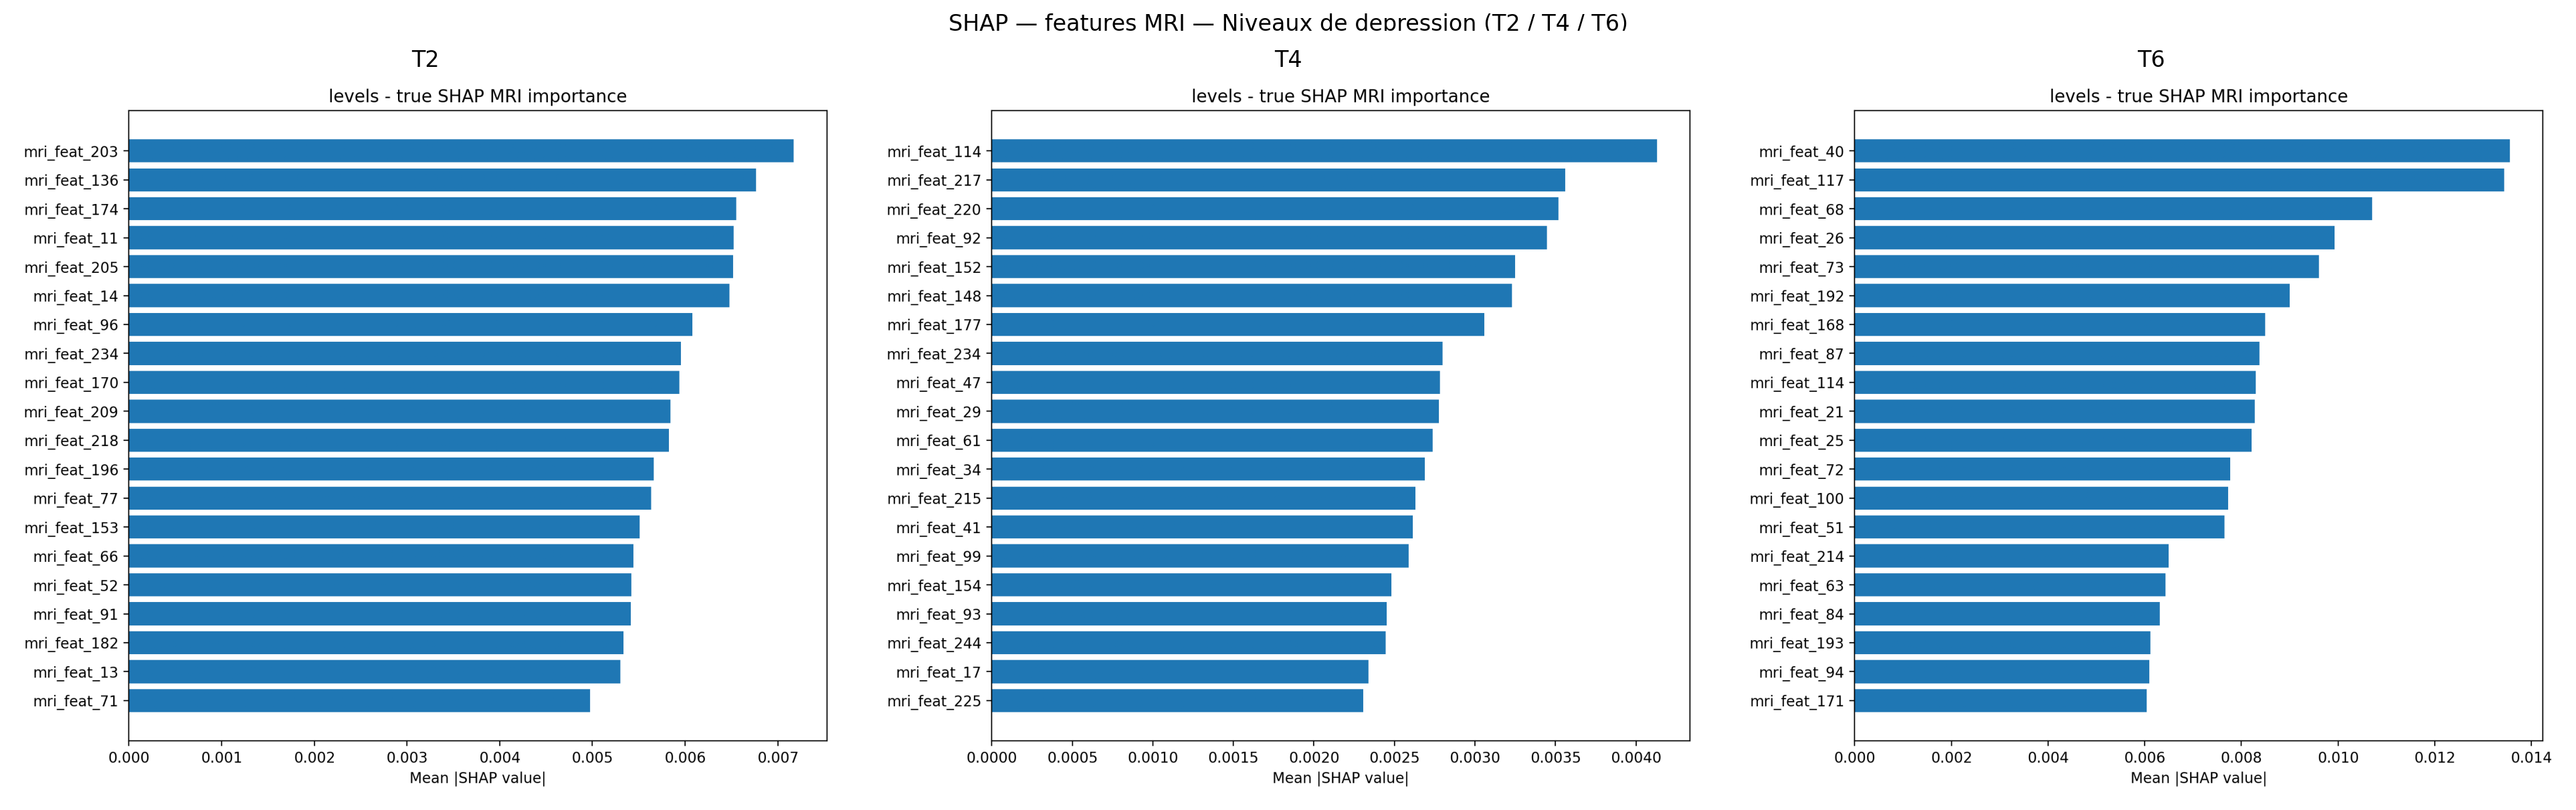

In [1]:
# ==========================================================
# COMPLETE FINAL CODE WITH FL IMPROVEMENTS - ALL HORIZONS (T2, T4, T6)
# ALL HORIZONS USE IMPROVED FEDERATED LEARNING
# IMPROVED MULTITASK HYBRID MODEL + PRE-EXTRACTED MRI FEATURES
# MIDDLE FUSION: MRI injected inside Transformer-BiGRU temporal encoder
# CORRECTED: one sampler call, reduced fusion dimension, no NaN CV print
# T2 / T4 / T6 + OPTUNA + FIXED 70/15/15 SPLIT (NO 5-FOLD CV)
# FEDERATED LEARNING (SIMULATED NON-IID CLIENTS) WITH ADVANCED FL TECHNIQUES
# CPU VERSION - KAGGLE READY
# ==========================================================

import re
import gc
import json
import copy
import random
import warnings
import pickle
from pathlib import Path
from functools import reduce
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

try:
    import torch
except RuntimeError as e:
    if "TORCH_LIBRARY" in str(e) and "triton" in str(e):
        raise RuntimeError("Kaggle Torch/Triton est déjà corrompu dans ce kernel. Fais Runtime -> Restart session, puis Run all. Ne relance pas une cellule torch seule après cette erreur.") from e
    raise
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Explainability deps
# SHAP is mandatory in this version. If shap is not installed, the notebook stops
# with a clear error instead of silently skipping SHAP.
try:
    from captum.attr import IntegratedGradients as CaptumIntegratedGradients
    HAS_CAPTUM = True
except Exception:
    CaptumIntegratedGradients = None
    HAS_CAPTUM = False

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    raise ImportError(
        "SHAP is mandatory in this notebook. Install it before running: pip install shap"
    ) from e

warnings.filterwarnings("ignore")

# ==========================================================
# 0) CONFIG
# ==========================================================
OUT_DIR = Path("/kaggle/working/final_federated_multitask_mri_parallel_latefusion_100rounds")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
SEEDS = [42, 43, 44, 45, 46]
device = torch.device("cpu")
print("device:", device)

HORIZONS = {
    "T2": {"months": [0, 12], "last_month": 12},
    "T4": {"months": [0, 12, 24, 36], "last_month": 36},
    "T6": {"months": [0, 12, 24, 36, 48, 60], "last_month": 60},
}

HORIZON_FED_CFG = {
    "T2": {
        # Base
        "local_epochs": 2,
        "client_batch_size": 32,
        # FL algorithms
        "use_fedprox": False,
        "fedprox_mu": 0.0,
        "use_scaffold": False,
        "use_moon": False,
        "moon_mu": 0.0,
        "moon_temperature": 0.5,
        "use_qfedavg_fairness": False,
        "qfed_q": 0.0,
        "qfed_clip_min": 1.0,
        "qfed_clip_max": 1.0,
        # Task weighting
        "use_dynamic_task_weighting": False,
        "dynamic_task_alpha": 0.15,
        # Personalization -> OFF for T2
        "use_reputation_agg": False,
        "reputation_var_lambda": 0.0,
        "use_light_personalization": False,
        "personalize_heads": False,
        "personalization_strength": 0.0,
        # Aggregation -> simple and stable
        "agg_mode": "simple",
        "head_agg_scale": 1.00,
        # Sampling
        "levels_sampler_boost": 1.00,
        "levels_power": 1.00,
        "levels_class_power": 1.05,
        "levels_max_weight": 6.0,
        # Clients
        "soft_client_mix": 0.20,
        "client_partition_mode": "label_modality",
        "dirichlet_alpha": 12.0,
        # Participation
        "participation_rate": 1.0,
        "fed_patience": 30,
        "min_delta": 1e-5,
        "ema_global": 0.0,
        "levels_ce_mix": 0.00,
        # Rounds
        "search_use_fed": False,
        "search_rounds": 0,
        "final_rounds": 100,
        # Penalties
        "fairness_lambda": 0.0,
        "sim_weight": 0.0,
        "stab_weight": 0.0,
        "grad_clip": 1.0,
        # Server
        "use_fed": True,
        "use_fedadam": False,
        "server_lr": 1.0,
        "server_beta1": 0.90,
        "server_beta2": 0.99,
        "server_tau": 1.0e-3,
        # Robustness
        "client_drop_rate": 0.00,
        "min_available_clients": 3,
        "use_staleness_weighting": False,
        "staleness_beta": 0.0,
        # Conservative FL for T2
        "use_weight_normalization": False,
        "warmup_rounds": 0,
        "adaptive_local_lr": False,
        "lr_decay_rate": 1.0,
        "min_lr": 1e-5,
        "use_local_early_stopping": False,
        "local_patience": 10,
        "adaptive_participation": False,
        "participation_decay": 1.0,
        "min_participation_rate": 1.0,
        "use_adaptive_client_weights": False,
        "use_uncertainty_aggregation": True,
        "uncertainty_weight": 0.20,
        "use_dp": True,
        "dp_noise_multiplier": 0.08,
        "dp_max_grad_norm": 1.0,
        "dp_delta": 1e-5,
    },
    "T4": {
        "local_epochs": 6,
        "client_batch_size": 20,
        "use_fedprox": False,
        "fedprox_mu": 0.0,
        "use_dynamic_task_weighting": True,
        "dynamic_task_alpha": 0.20,
        "use_reputation_agg": False,
        "reputation_var_lambda": 0.22,
        "use_light_personalization": True,
        "personalize_heads": True,
        "personalization_strength": 0.18,
        "use_scaffold": False,
        "agg_mode": "layerwise",
        "head_agg_scale": 1.00,
        "levels_sampler_boost": 1.25,
        "levels_power": 1.10,
        "levels_class_power": 1.35,
        "levels_max_weight": 10.0,
        "soft_client_mix": 0.42,
        "client_partition_mode": "dirichlet_hybrid",
        "dirichlet_alpha": 10.0,
        "participation_rate": 1.0,
        "fed_patience": 55,
        "min_delta": 1e-5,
        "ema_global": 0.10,
        "levels_ce_mix": 0.08,
        "search_use_fed": False,
        "search_rounds": 0,
        "final_rounds": 100,
        "fairness_lambda": 0.0,
        "sim_weight": 0.0,
        "stab_weight": 0.0,
        "grad_clip": 1.0,
        "use_fed": True,
        "use_fedadam": False,
        "server_lr": 0.85,
        "server_beta1": 0.90,
        "server_beta2": 0.995,
        "server_tau": 1.0e-3,
        "use_moon": False,
        "moon_mu": 0.05,
        "moon_temperature": 0.5,
        "client_drop_rate": 0.00,
        "min_available_clients": 2,
        "use_staleness_weighting": False,
        "staleness_beta": 0.06,
        "use_qfedavg_fairness": False,
        "qfed_q": 0.35,
        "qfed_clip_min": 0.75,
        "qfed_clip_max": 1.50,
        "use_weight_normalization": True,
        "warmup_rounds": 18,
        "adaptive_local_lr": True,
        "lr_decay_rate": 0.975,
        "min_lr": 1e-5,
        "use_local_early_stopping": True,
        "local_patience": 3,
        "adaptive_participation": True,
        "participation_decay": 0.975,
        "min_participation_rate": 0.60,
        "use_adaptive_client_weights": True,
        "use_uncertainty_aggregation": True,
        "uncertainty_weight": 0.20,
        "use_dp": True,
        "dp_noise_multiplier": 0.08,
        "dp_max_grad_norm": 1.0,
        "dp_delta": 1e-5,
    },
    "T6": {
        # Same FL family as T4, but tuned for the harder 60-month horizon
        "local_epochs": 7,
        "client_batch_size": 16,
        "use_fedprox": False,
        "fedprox_mu": 0.0,
        "use_dynamic_task_weighting": True,
        "dynamic_task_alpha": 0.24,
        "use_reputation_agg": False,
        "reputation_var_lambda": 0.22,
        "use_light_personalization": True,
        "personalize_heads": True,
        "personalization_strength": 0.22,
        "use_scaffold": False,
        "agg_mode": "layerwise",
        "head_agg_scale": 1.00,
        "levels_sampler_boost": 1.45,
        "levels_power": 1.22,
        "levels_class_power": 1.55,
        "levels_max_weight": 14.0,
        "soft_client_mix": 0.50,
        "client_partition_mode": "dirichlet_hybrid",
        "dirichlet_alpha": 12.0,
        "participation_rate": 1.0,
        "fed_patience": 75,
        "min_delta": 1e-5,
        "ema_global": 0.12,
        "levels_ce_mix": 0.14,
        "search_use_fed": False,
        "search_rounds": 0,
        "final_rounds": 100,
        "fairness_lambda": 0.0,
        "sim_weight": 0.0,
        "stab_weight": 0.0,
        "grad_clip": 1.0,
        "use_fed": True,
        "use_fedadam": False,
        "server_lr": 0.80,
        "server_beta1": 0.90,
        "server_beta2": 0.995,
        "server_tau": 1.0e-3,
        "use_moon": False,
        "moon_mu": 0.05,
        "moon_temperature": 0.5,
        "client_drop_rate": 0.00,
        "min_available_clients": 2,
        "use_staleness_weighting": False,
        "staleness_beta": 0.06,
        "use_qfedavg_fairness": False,
        "qfed_q": 0.35,
        "qfed_clip_min": 0.75,
        "qfed_clip_max": 1.50,
        "use_weight_normalization": True,
        "warmup_rounds": 24,
        "adaptive_local_lr": True,
        "lr_decay_rate": 0.982,
        "min_lr": 1e-5,
        "use_local_early_stopping": True,
        "local_patience": 4,
        "adaptive_participation": True,
        "participation_decay": 0.99,
        "min_participation_rate": 0.75,
        "use_adaptive_client_weights": True,
        "use_uncertainty_aggregation": True,
        "uncertainty_weight": 0.15,
        "use_dp": True,
        "dp_noise_multiplier": 0.06,
        "dp_max_grad_norm": 1.0,
        "dp_delta": 1e-5,
    },
}

MRI_FEAT_DIM = 256
MRI_MISSING_FILL = -1.0

MONTH_TO_INDEX = {0: 0, 12: 1, 24: 2, 36: 3, 48: 4, 60: 5}

for _hz in HORIZON_FED_CFG:
    HORIZON_FED_CFG[_hz]["horizon_name"] = _hz

FED_ROUNDS = 100
USE_FED = True

# Global run/training settings
RUN_OPTUNA = True   # Optuna activated before the 100-round FL run
# T2 et T6 gardent 24 essais pour couvrir la dimension label_smoothing ajoutee
# au search space (T6: IMPROVEMENT, depression/levels decouples de subtype).
# T4 garde exactement le comportement de t4_t6.ipynb (18 essais, search space
# inchange).
N_TRIALS_BY_HORIZON = {"T2": 24, "T4": 18, "T6": 24}
USE_KFOLD = False
N_SPLITS = 1
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
INNER_VAL_RATIO = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)  # 0.17647 => 15% validation from full dataset

SEARCH_EPOCHS = 15
FINAL_EPOCHS = 100
PATIENCE = 15

BATCH_SIZE = 64
NUM_WORKERS = 0
PIN_MEMORY = False

N_CLIENTS = 3
MIN_CLIENT_SIZE = 8
FED_EARLY_STOPPING = True


# ==========================================================
# 1) SEED
# ==========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

def autocast_context():
    return nullcontext()


def finite_float(x, default=0.0):
    """Return a safe finite Python float to avoid NaN scores breaking CV/FL."""
    try:
        x = float(x)
        if np.isfinite(x):
            return x
    except Exception:
        pass
    return float(default)


# ==========================================================
# 2) FILE HELPERS
# ==========================================================
def find_file(filename):
    base = Path("/kaggle/input")
    matches = list(base.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} introuvable dans /kaggle/input")
    print(f"[FOUND] {filename} -> {matches[0]}")
    return matches[0]

def find_mri_feature_file():
    candidates = list(Path("/kaggle/input").rglob("mri_featuress.csv"))
    if len(candidates) == 0:
        raise FileNotFoundError("mri_featuress.csv introuvable dans /kaggle/input")
    print("[FOUND] MRI feature file ->", candidates[0])
    return candidates[0]

def read_csv_robust(path):
    return pd.read_csv(
        path,
        encoding="latin1",
        sep=None,
        engine="python",
        on_bad_lines="skip"
    )

# ==========================================================
# 3) MERGE HELPERS
# ==========================================================
KEYS = ["PATNO", "EVENT_ID"]
DATE_CANDIDATES = ["INFODT", "VISITDT", "DATE", "EXAMDATE", "TESTDATE"]

ADMIN_WORDS = [
    "REC_ID", "PAG_NAME", "ORIG_ENTRY", "LAST_UPDATE",
    "ENTRY", "UPDATE", "NUPSOURC", "PTCGBOTH",
    "INFODT", "VISITDT", "EXAMDATE", "TESTDATE", "DATE"
]

LEAKY_CONTAINS = [
    "ESS_TOTAL", "SCORE_GDS", "SCAUTOT", "RBDTOT",
    "NP1RTOT", "NP2PTOT", "NP3TOT", "NHY"
]

_FR_MONTH = {
    "janv": "Jan", "févr": "Feb", "fevr": "Feb", "mars": "Mar", "avr": "Apr",
    "mai": "May", "juin": "Jun", "juil": "Jul", "août": "Aug", "aout": "Aug",
    "sept": "Sep", "oct": "Oct", "nov": "Nov", "déc": "Dec", "dec": "Dec"
}

def norm_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().upper() for c in df.columns]
    return df

def coerce_keys(df):
    df = df.copy()
    if "PATNO" in df.columns:
        df["PATNO"] = pd.to_numeric(df["PATNO"], errors="coerce").astype("Int64")
    if "EVENT_ID" in df.columns:
        df["EVENT_ID"] = df["EVENT_ID"].astype(str).str.upper().str.strip()
    return df

def detect_date_col(df):
    for c in DATE_CANDIDATES:
        if c in df.columns:
            return c
    return None

def parse_date_series(s):
    s = s.astype(str).str.strip()
    for fr, en in _FR_MONTH.items():
        s = s.str.replace(fr, en, regex=False)
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

def dedup_by_key_keep_latest(df, keys=None):
    df = df.copy()
    if keys is None:
        keys = [k for k in ["PATNO", "EVENT_ID"] if k in df.columns]

    if len(keys) == 0:
        return df.drop_duplicates(keep="last")

    dcol = detect_date_col(df)
    if dcol is not None:
        df["_DATE_TMP_"] = parse_date_series(df[dcol])
        df = df.sort_values(keys + ["_DATE_TMP_"])
        df = df.drop_duplicates(keys, keep="last")
        df = df.drop(columns=["_DATE_TMP_"])
    else:
        df = df.drop_duplicates(keys, keep="last")
    return df

def prefix_features(df, prefix, protected=("PATNO", "EVENT_ID")):
    df = df.copy()
    rename_map = {}
    for c in df.columns:
        if c not in protected:
            rename_map[c] = f"{prefix}{c}"
    return df.rename(columns=rename_map)

def event_id_to_month(x):
    x = str(x).strip().upper()
    if x == "BL":
        return 0
    m = re.fullmatch(r"V(\d+)", x)
    if m:
        v = int(m.group(1))
        return (v - 2) * 6
    return np.nan

def drop_admin_cols_safe(df):
    drop_cols = []
    for c in df.columns:
        cu = c.upper()
        if cu in KEYS:
            continue
        if any(w in cu for w in ADMIN_WORDS):
            drop_cols.append(c)
    return df.drop(columns=drop_cols, errors="ignore")

def drop_leaky_cols_safe(df):
    drop_cols = []
    for c in df.columns:
        cu = c.upper()
        if cu in KEYS:
            continue
        if any(w in cu for w in LEAKY_CONTAINS):
            drop_cols.append(c)
    return df.drop(columns=drop_cols, errors="ignore")

def filter_to_pd(participant_status):
    df = participant_status.copy()
    candidate_cols = [c for c in df.columns if ("COHORT" in c or "STATUS" in c or "DEF" in c)]
    if len(candidate_cols) == 0:
        txt = df.astype(str).agg(" ".join, axis=1)
    else:
        txt = pd.Series("", index=df.index)
        for c in candidate_cols:
            txt = txt.astype(str) + " " + df[c].astype(str)
    mask = txt.str.contains("PARKINSON", case=False, na=False)
    keep_pat = df.loc[mask, "PATNO"].dropna().astype(int).unique()
    return set(keep_pat)

# ==========================================================
# 4) LOAD DATA
# ==========================================================
def load_all_clinical_and_mri():
    demo_path   = find_file("Demographics.csv")
    ess_path    = find_file("Epworth_Sleepiness_Scale.csv")
    up1_path    = find_file("MDS-UPDRS_Part_I.csv")
    up4_path    = find_file("MDS-UPDRS_Part_IV.csv")
    rem_path    = find_file("REM_Sleep_Behavior.csv")
    scopa_path  = find_file("SCOPA-AUT.csv")
    gds_path    = find_file("Geriatric_Depression_Scale.csv")
    status_path = find_file("Participant_Status.csv")
    up23_path   = find_file("UPDRS_PartII_PartIII.xlsx")
    mri_path    = find_mri_feature_file()

    demo = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(demo_path))), keys=["PATNO", "EVENT_ID"]),
        "DEMO__"
    )
    ess = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(ess_path))), keys=["PATNO", "EVENT_ID"]),
        "ESS__"
    )
    up1 = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(up1_path))), keys=["PATNO", "EVENT_ID"]),
        "UP1__"
    )
    up4 = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(up4_path))), keys=["PATNO", "EVENT_ID"]),
        "UP4__"
    )
    rem = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(rem_path))), keys=["PATNO", "EVENT_ID"]),
        "REM__"
    )
    scopa = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(scopa_path))), keys=["PATNO", "EVENT_ID"]),
        "SCOPA__"
    )
    gds = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(read_csv_robust(gds_path))), keys=["PATNO", "EVENT_ID"]),
        "GDS__"
    )

    status = dedup_by_key_keep_latest(
        coerce_keys(norm_cols(read_csv_robust(status_path))), keys=["PATNO"]
    )

    up23 = pd.read_excel(up23_path)
    up23 = prefix_features(
        dedup_by_key_keep_latest(coerce_keys(norm_cols(up23)), keys=["PATNO", "EVENT_ID"]),
        "UP23__"
    )

    demo  = drop_leaky_cols_safe(drop_admin_cols_safe(demo))
    ess   = drop_leaky_cols_safe(drop_admin_cols_safe(ess))
    up1   = drop_leaky_cols_safe(drop_admin_cols_safe(up1))
    up4   = drop_leaky_cols_safe(drop_admin_cols_safe(up4))
    rem   = drop_leaky_cols_safe(drop_admin_cols_safe(rem))
    scopa = drop_leaky_cols_safe(drop_admin_cols_safe(scopa))
    gds   = drop_leaky_cols_safe(drop_admin_cols_safe(gds))
    up23  = drop_leaky_cols_safe(drop_admin_cols_safe(up23))

    dfs = [demo, ess, up1, up4, rem, scopa, gds, up23]
    df_seq = reduce(lambda left, right: pd.merge(left, right, on=KEYS, how="outer"), dfs)

    status = coerce_keys(norm_cols(status))
    pd_patients = filter_to_pd(status)
    df_seq = df_seq[df_seq["PATNO"].isin(pd_patients)].copy()

    df_seq["MONTH"] = df_seq["EVENT_ID"].apply(event_id_to_month)
    df_seq = df_seq[df_seq["MONTH"].notna()].copy()
    df_seq["MONTH"] = df_seq["MONTH"].astype(int)
    df_seq = df_seq.sort_values(["PATNO", "MONTH"])
    df_seq = df_seq.drop_duplicates(subset=["PATNO", "MONTH"], keep="last").copy()

    print("Merged clinical shape:", df_seq.shape)

    mri_feat_dict, mri_feature_cols = load_preextracted_mri_features(mri_path)
    return df_seq, mri_feat_dict, mri_feature_cols

# ==========================================================
# 5) LABELS
# ==========================================================
def build_labels(df_seq):
    df_seq = df_seq.copy()

    if "GDS__DEPRESSION" not in df_seq.columns:
        gds_score_candidates = [c for c in df_seq.columns if "GDS" in c and ("TOTAL" in c or "SCORE" in c)]
        if len(gds_score_candidates) == 0:
            raise ValueError("No GDS score column found.")
        gds_score_col = gds_score_candidates[0]
        score = pd.to_numeric(df_seq[gds_score_col], errors="coerce")
        df_seq["GDS__DEPRESSION"] = (score >= 5).astype("Float64")

    if "GDS__LEVELS" not in df_seq.columns:
        gds_score_candidates = [c for c in df_seq.columns if "GDS" in c and ("TOTAL" in c or "SCORE" in c)]
        if len(gds_score_candidates) == 0:
            raise ValueError("No GDS score column found.")
        gds_score_col = gds_score_candidates[0]
        score = pd.to_numeric(df_seq[gds_score_col], errors="coerce")

        levels = pd.Series(np.nan, index=df_seq.index)
        levels[(score >= 0) & (score <= 4)] = 0
        levels[(score >= 5) & (score <= 8)] = 1
        levels[(score >= 9) & (score <= 11)] = 2
        levels[(score >= 12)] = 3
        df_seq["GDS__LEVELS"] = levels.astype("Float64")

    if "SUBTYPE_BIN" not in df_seq.columns:
        ratio_candidates = [c for c in df_seq.columns if "RATIO" in c.upper()]
        td_candidates = [c for c in df_seq.columns if "SCORE TD" in c.upper()]
        pigd_candidates = [c for c in df_seq.columns if "SCORE PIGD" in c.upper()]

        subtype = pd.Series(np.nan, index=df_seq.index)

        if len(ratio_candidates) > 0:
            ratio = pd.to_numeric(df_seq[ratio_candidates[0]], errors="coerce")
            subtype[ratio >= 1.15] = 1
            subtype[ratio <= 0.90] = 2
        elif len(td_candidates) > 0 and len(pigd_candidates) > 0:
            td = pd.to_numeric(df_seq[td_candidates[0]], errors="coerce")
            pigd = pd.to_numeric(df_seq[pigd_candidates[0]], errors="coerce")
            ratio = td / pigd.replace(0, np.nan)
            subtype[ratio >= 1.15] = 1
            subtype[ratio <= 0.90] = 2
        else:
            raise ValueError("Impossible de construire SUBTYPE_BIN")

        df_seq["SUBTYPE_BIN"] = subtype.astype("Float64")

    print("Labels ready.")
    return df_seq

# ==========================================================
# 6) FEATURE SELECTION
# ==========================================================
def prepare_feature_columns(df_seq):
    protected_cols = [
        "PATNO", "EVENT_ID", "MONTH",
        "GDS__DEPRESSION", "GDS__LEVELS", "SUBTYPE_BIN"
    ]

    for c in df_seq.columns:
        if c not in ["PATNO", "EVENT_ID"]:
            df_seq[c] = pd.to_numeric(df_seq[c], errors="ignore")

    numeric_cols = []
    for c in df_seq.columns:
        if c in protected_cols:
            continue
        if pd.api.types.is_numeric_dtype(df_seq[c]):
            numeric_cols.append(c)

    feature_cols_model = []
    for c in numeric_cols:
        miss = df_seq[c].isna().mean()
        protected_prefix = c.startswith(("ESS__", "REM__", "SCOPA__", "GDS__", "UP1__", "UP4__", "UP23__", "DEMO__"))
        if miss <= 0.90 or protected_prefix:
            feature_cols_model.append(c)

    print("Clinical feature columns:", len(feature_cols_model))
    return df_seq, feature_cols_model

# ==========================================================
# 7) LOAD MRI FEATURES
# ==========================================================
def load_preextracted_mri_features(mri_file):
    mri_df = pd.read_csv(mri_file)
    mri_df.columns = [str(c).strip() for c in mri_df.columns]

    if "PATNO" not in mri_df.columns:
        raise ValueError("MRI file must contain PATNO column")

    mri_df["PATNO"] = pd.to_numeric(mri_df["PATNO"], errors="coerce").astype("Int64")
    feat_cols = [c for c in mri_df.columns if c.lower().startswith("mri_feat")]

    if len(feat_cols) != MRI_FEAT_DIM:
        raise ValueError(f"Expected {MRI_FEAT_DIM} MRI features, but found {len(feat_cols)}.")

    if "mri_available" not in mri_df.columns:
        mri_df["mri_available"] = 1

    mri_df = mri_df.dropna(subset=["PATNO"]).copy()
    mri_df["PATNO"] = mri_df["PATNO"].astype(int)

    feat_dict = {}
    for _, row in mri_df.iterrows():
        patno = int(row["PATNO"])
        available = float(row["mri_available"])

        if available > 0.5:
            feat = row[feat_cols].to_numpy(dtype=np.float32)
            feat_dict[patno] = {"feat": feat, "available": 1.0}
        else:
            feat_dict[patno] = {
                "feat": np.full(MRI_FEAT_DIM, MRI_MISSING_FILL, dtype=np.float32),
                "available": 0.0
            }

    print("MRI patients loaded:", len(feat_dict))
    print("MRI feature dim:", len(feat_cols))
    return feat_dict, feat_cols

# ==========================================================
# 8) BUILD MULTITASK SEQUENCES
# ==========================================================
def make_multitask_sequences(df_seq, feature_cols, months, last_month, mri_feat_dict):
    Xc_list, Xmri_list, Xflag_list, pat_list = [], [], [], []
    y_subtype_list, m_subtype_list = [], []
    y_depbin_list, m_depbin_list = [], []
    y_levels_list, m_levels_list = [], []
    month_idx_list = []

    for patno, g in df_seq.groupby("PATNO"):
        g = g.copy().sort_values("MONTH").drop_duplicates(subset=["MONTH"], keep="last").set_index("MONTH")

        if last_month not in g.index:
            continue

        gg = g.reindex(months)
        Xc = gg[feature_cols].to_numpy(dtype=np.float32)
        month_idx = np.array([MONTH_TO_INDEX[m] for m in months], dtype=np.int64)

        row_last = g.loc[last_month]
        if isinstance(row_last, pd.DataFrame):
            row_last = row_last.iloc[-1]

        y_subtype = row_last["SUBTYPE_BIN"] if "SUBTYPE_BIN" in row_last.index else pd.NA
        y_depbin  = row_last["GDS__DEPRESSION"] if "GDS__DEPRESSION" in row_last.index else pd.NA
        y_levels  = row_last["GDS__LEVELS"] if "GDS__LEVELS" in row_last.index else pd.NA

        has_any = ((not pd.isna(y_subtype)) or (not pd.isna(y_depbin)) or (not pd.isna(y_levels)))
        if not has_any:
            continue

        if int(patno) in mri_feat_dict:
            xmri = mri_feat_dict[int(patno)]["feat"].astype(np.float32)
            xflag = np.array([mri_feat_dict[int(patno)]["available"]], dtype=np.float32)
        else:
            xmri = np.full(MRI_FEAT_DIM, MRI_MISSING_FILL, dtype=np.float32)
            xflag = np.array([0.0], dtype=np.float32)

        Xc_list.append(Xc)
        Xmri_list.append(xmri)
        Xflag_list.append(xflag)
        pat_list.append(int(patno))
        month_idx_list.append(month_idx)

        if pd.isna(y_subtype):
            y_subtype_list.append(-1)
            m_subtype_list.append(0.0)
        else:
            val = int(y_subtype)
            if val in [1, 2]:
                val = val - 1
            y_subtype_list.append(val)
            m_subtype_list.append(1.0)

        if pd.isna(y_depbin):
            y_depbin_list.append(-1)
            m_depbin_list.append(0.0)
        else:
            y_depbin_list.append(int(y_depbin))
            m_depbin_list.append(1.0)

        if pd.isna(y_levels):
            y_levels_list.append(-1)
            m_levels_list.append(0.0)
        else:
            y_levels_list.append(int(y_levels))
            m_levels_list.append(1.0)

    if len(Xc_list) == 0:
        raise ValueError("Aucune séquence construite.")

    return {
        "X": np.stack(Xc_list).astype(np.float32),
        "Xmri": np.stack(Xmri_list).astype(np.float32),
        "Xflag": np.stack(Xflag_list).astype(np.float32),
        "month_idx": np.stack(month_idx_list).astype(np.int64),
        "pat": np.array(pat_list, dtype=np.int64),
        "y_subtype": np.array(y_subtype_list, dtype=np.int64),
        "m_subtype": np.array(m_subtype_list, dtype=np.float32),
        "y_depbin": np.array(y_depbin_list, dtype=np.int64),
        "m_depbin": np.array(m_depbin_list, dtype=np.float32),
        "y_levels": np.array(y_levels_list, dtype=np.int64),
        "m_levels": np.array(m_levels_list, dtype=np.float32),
    }

# ==========================================================
# 9) PREPROCESSING
# ==========================================================
def fit_preprocess_train_only_with_mask(X_train):
    X_train = X_train.astype(np.float32)
    N, T, F = X_train.shape

    mask = np.isfinite(X_train).astype(np.float32)
    flat = X_train.reshape(-1, F)

    med = np.nanmedian(flat, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)

    flat_imp = flat.copy()
    inds = np.where(~np.isfinite(flat_imp))
    flat_imp[inds] = np.take(med, inds[1])

    scaler = MinMaxScaler()
    flat_scaled = scaler.fit_transform(flat_imp)
    X_scaled = flat_scaled.reshape(N, T, F).astype(np.float32)

    X_out = np.concatenate([X_scaled, mask], axis=-1).astype(np.float32)
    return X_out, med.astype(np.float32), scaler

def transform_with_train_params_with_mask(X, med, scaler):
    X = X.astype(np.float32)
    N, T, F = X.shape

    mask = np.isfinite(X).astype(np.float32)
    flat = X.reshape(-1, F)

    flat_imp = flat.copy()
    inds = np.where(~np.isfinite(flat_imp))
    flat_imp[inds] = np.take(med, inds[1])

    flat_scaled = scaler.transform(flat_imp)
    X_scaled = flat_scaled.reshape(N, T, F).astype(np.float32)

    X_out = np.concatenate([X_scaled, mask], axis=-1).astype(np.float32)
    return X_out

def fit_preprocess_mri_train_only(Xmri_train, Xflag_train, missing_fill=MRI_MISSING_FILL):
    Xmri_train = Xmri_train.astype(np.float32)
    available_mask = (Xflag_train.reshape(-1) > 0.5)

    scaler = StandardScaler()

    if available_mask.sum() > 1:
        scaler.fit(Xmri_train[available_mask])
        Xmri_scaled = Xmri_train.copy()
        Xmri_scaled[available_mask] = scaler.transform(Xmri_scaled[available_mask])
    else:
        scaler.fit(np.zeros((2, Xmri_train.shape[1]), dtype=np.float32))
        Xmri_scaled = Xmri_train.copy()

    Xmri_scaled[~available_mask] = missing_fill
    return Xmri_scaled.astype(np.float32), scaler

def transform_mri_with_train_params(Xmri, Xflag, scaler, missing_fill=MRI_MISSING_FILL):
    Xmri = Xmri.astype(np.float32)
    available_mask = (Xflag.reshape(-1) > 0.5)
    Xmri_scaled = Xmri.copy()

    if available_mask.sum() > 0:
        Xmri_scaled[available_mask] = scaler.transform(Xmri_scaled[available_mask])

    Xmri_scaled[~available_mask] = missing_fill
    return Xmri_scaled.astype(np.float32)

# ==========================================================
# 10) LOSSES
# ==========================================================
def inverse_freq_weights(y, n_classes, power=1.0, max_w=8.0):
    y = np.asarray(y, dtype=np.int64)
    counts = np.bincount(y, minlength=n_classes).astype(np.float32)
    counts[counts == 0] = 1.0
    w = (counts.sum() / counts) ** power
    w = w / w.mean()
    w = np.clip(w, 1.0, max_w)
    return torch.tensor(w, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    # IMPROVEMENT (T2): added optional label_smoothing (default 0.0 = identical to the
    # original behaviour). A small amount of label smoothing (e.g. 0.03-0.05)
    # is a well-established, low-risk regularizer that tends to improve
    # generalization and calibration, especially combined with class-weighted
    # focal loss on imbalanced clinical classes.
    def __init__(self, gamma=2.0, weight=None, reduction="mean", label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits, targets, weight=self.weight, reduction="none",
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

def masked_focal_loss(logits, y, mask, focal_loss_fn):
    valid = mask > 0.5
    if valid.sum() == 0:
        return logits.sum() * 0.0
    return focal_loss_fn(logits[valid], y[valid])

def masked_ce_loss(logits, y, mask, weight=None, label_smoothing=0.0):
    valid = mask > 0.5
    if valid.sum() == 0:
        return logits.sum() * 0.0
    return F.cross_entropy(logits[valid], y[valid], weight=weight, label_smoothing=label_smoothing)

def compute_multitask_val_loss(model, loader, focal_sub, focal_dep, focal_lvl, w_lvl, levels_ce_mix=0.0):
    """
    Calcule la VRAIE validation loss multitache (meme formule que la train loss),
    sur un DataLoader complet. Utilisee pour tracer Train Loss vs Val Loss.
    """
    was_training = model.training
    model.eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for batch in loader:
            x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]
            out_s, out_d, out_l = model(x_clin, x_mri, x_flag, midx)

            loss_s = masked_focal_loss(out_s, ys, ms, focal_sub)
            loss_d = masked_focal_loss(out_d, yd, md, focal_dep)
            loss_l_focal = masked_focal_loss(out_l, yl, ml, focal_lvl)
            loss_l_ce = masked_ce_loss(out_l, yl, ml, weight=w_lvl)
            loss_l = (1.0 - levels_ce_mix) * loss_l_focal + levels_ce_mix * loss_l_ce

            loss = loss_s + loss_d + loss_l
            total_loss += float(loss.item())
            n_batches += 1
    if was_training:
        model.train()
    return total_loss / max(n_batches, 1)

def compute_global_score_weighted(res_sub, res_dep, res_lvl, h_name):
    if h_name == "T2":
        weights = np.array([1, 1, 1, 1, 1, 1], dtype=np.float32)
    elif h_name == "T4":
        weights = np.array([1.0, 1.0, 1.0, 1.0, 1.4, 1.4], dtype=np.float32)
    else:
        weights = np.array([1.0, 1.0, 1.0, 1.0, 1.7, 1.7], dtype=np.float32)

    vals = np.array([
        res_sub["balanced_accuracy"], res_sub["f1_macro"],
        res_dep["balanced_accuracy"], res_dep["f1_macro"],
        res_lvl["balanced_accuracy"], res_lvl["f1_macro"],
    ], dtype=np.float32)

    ok = np.isfinite(vals)
    if ok.sum() == 0:
        return np.nan
    return float((vals[ok] * weights[ok]).sum() / weights[ok].sum())

def ema_merge_state_dict(prev_state, new_state, alpha=0.0):
    if alpha <= 0.0:
        return new_state
    merged = {}
    for k in new_state.keys():
        merged[k] = (1.0 - alpha) * new_state[k].float() + alpha * prev_state[k].float()
    return merged

def get_dynamic_task_weights(loss_s, loss_d, loss_l, alpha=0.25, eps=1e-8):
    losses = torch.stack([loss_s.detach(), loss_d.detach(), loss_l.detach()])
    losses = torch.clamp(losses, min=eps)
    base = losses / losses.sum()
    uniform = torch.ones_like(base) / len(base)
    weights = alpha * base + (1.0 - alpha) * uniform
    weights = weights / weights.sum()
    return weights

def multitask_dynamic_loss(loss_s, loss_d, loss_l, alpha=0.25):
    w = get_dynamic_task_weights(loss_s, loss_d, loss_l, alpha=alpha)
    return w[0] * loss_s + w[1] * loss_d + w[2] * loss_l, w

def multitask_plain_monitor_loss(loss_s, loss_d, loss_l):
    return loss_s + loss_d + loss_l


def safe_state_clone(state_dict):
    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}


def cosine_representation_loss(local_repr, global_repr, prev_repr=None, temperature=0.5, eps=1e-8):
    local_n = F.normalize(local_repr, dim=1, eps=eps)
    global_n = F.normalize(global_repr.detach(), dim=1, eps=eps)
    pos = torch.sum(local_n * global_n, dim=1) / max(float(temperature), eps)

    if prev_repr is None:
        return (1.0 - pos).mean()

    prev_n = F.normalize(prev_repr.detach(), dim=1, eps=eps)
    neg = torch.sum(local_n * prev_n, dim=1) / max(float(temperature), eps)
    logits = torch.stack([pos, neg], dim=1)
    targets = torch.zeros(local_repr.size(0), dtype=torch.long, device=local_repr.device)
    return F.cross_entropy(logits, targets)


def add_dp_noise_to_grads(model, noise_multiplier=0.0, max_grad_norm=1.0, batch_size=1):
    if noise_multiplier <= 0.0:
        return
    scale = float(noise_multiplier) * float(max_grad_norm) / max(float(batch_size), 1.0)
    for p in model.parameters():
        if p.grad is None:
            continue
        noise = torch.randn_like(p.grad) * scale
        p.grad.add_(noise)


def apply_dp_step(model, max_grad_norm=1.0, noise_multiplier=0.0, batch_size=1):
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
    add_dp_noise_to_grads(
        model,
        noise_multiplier=noise_multiplier,
        max_grad_norm=max_grad_norm,
        batch_size=batch_size,
    )


def compute_prediction_uncertainty_from_logits(logits):
    probs = F.softmax(logits, dim=1)
    ent = -(probs * torch.log(probs.clamp_min(1e-8))).sum(dim=1)
    return ent


def compute_multitask_uncertainty(model, data_loader):
    if data_loader is None:
        return np.nan

    model.eval()
    entropies = []
    with torch.no_grad():
        for batch in data_loader:
            x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]
            out_s, out_d, out_l, _ = model(x_clin, x_mri, x_flag, midx, return_features=True)

            ent_s = compute_prediction_uncertainty_from_logits(out_s)
            ent_d = compute_prediction_uncertainty_from_logits(out_d)
            ent_l = compute_prediction_uncertainty_from_logits(out_l)

            if (ms > 0.5).any():
                entropies.append(float(ent_s[ms > 0.5].mean().item()))
            if (md > 0.5).any():
                entropies.append(float(ent_d[md > 0.5].mean().item()))
            if (ml > 0.5).any():
                entropies.append(float(ent_l[ml > 0.5].mean().item()))

    model.train()
    if len(entropies) == 0:
        return np.nan
    return float(np.mean(entropies))


def apply_uncertainty_to_weight(base_weight, uncertainty, alpha=0.3):
    if uncertainty is None or (isinstance(uncertainty, float) and not np.isfinite(uncertainty)):
        return float(base_weight), 1.0
    factor = 1.0 / (1.0 + float(alpha) * max(float(uncertainty), 0.0))
    return float(base_weight) * factor, factor


def apply_staleness_to_weight(base_weight, staleness_rounds=0, beta=0.0):
    if beta <= 0.0 or staleness_rounds <= 0:
        return float(base_weight), 1.0
    factor = float(np.exp(-beta * float(staleness_rounds)))
    return float(base_weight) * factor, factor


def qfed_adjust_weights(base_weights, client_losses, q=0.25, clip_min=0.75, clip_max=1.50, eps=1e-8):
    if len(base_weights) == 0:
        return [], []
    arr_w = np.asarray(base_weights, dtype=np.float64)
    arr_l = np.asarray(client_losses, dtype=np.float64)
    safe_losses = np.where(np.isfinite(arr_l), np.maximum(arr_l, eps), np.nan)
    if np.all(~np.isfinite(safe_losses)):
        return arr_w.tolist(), [1.0] * len(arr_w)
    mean_loss = np.nanmean(safe_losses)
    mean_loss = float(max(mean_loss, eps))
    rel = np.power(np.clip(safe_losses / mean_loss, eps, None), float(max(q, 0.0)))
    rel = np.clip(rel, float(clip_min), float(clip_max))
    rel = np.where(np.isfinite(rel), rel, 1.0)
    new_w = arr_w * rel
    return new_w.tolist(), rel.tolist()


def init_server_optimizer_state(model):
    m = {k: torch.zeros_like(v.detach().cpu().float()) for k, v in model.state_dict().items()}
    v = {k: torch.zeros_like(v.detach().cpu().float()) for k, v in model.state_dict().items()}
    return {"m": m, "v": v, "step": 0}


def fedadam_update(global_state, aggregated_state, opt_state, server_lr=1.0, beta1=0.9, beta2=0.99, tau=1e-3, skip_heads=False):
    opt_state["step"] += 1
    t = opt_state["step"]
    new_state = {}
    for k in global_state.keys():
        if skip_heads and k.startswith("head_"):
            new_state[k] = global_state[k].detach().cpu().clone()
            continue
        delta = (aggregated_state[k].float() - global_state[k].float()).detach().cpu()
        opt_state["m"][k] = beta1 * opt_state["m"][k] + (1.0 - beta1) * delta
        opt_state["v"][k] = beta2 * opt_state["v"][k] + (1.0 - beta2) * (delta * delta)
        m_hat = opt_state["m"][k] / (1.0 - (beta1 ** t))
        v_hat = opt_state["v"][k] / (1.0 - (beta2 ** t))
        new_state[k] = (global_state[k].float() + server_lr * m_hat / (torch.sqrt(v_hat) + tau)).detach().cpu().clone()
    return new_state, opt_state


# ==========================================================
# 11) FONCTIONS FL AMÉLIORÉES
# ==========================================================

def normalize_client_weights(weights, method="softmax"):
    if len(weights) == 0:
        return []
    
    weights = np.array(weights, dtype=np.float64)
    weights = np.clip(weights, 1e-8, 1e8)
    
    if method == "softmax":
        exp_w = np.exp(weights - np.max(weights))
        normalized = exp_w / (exp_w.sum() + 1e-8)
    else:
        weights = np.clip(weights, 0.1, 10.0)
        normalized = weights / (weights.sum() + 1e-8)
    
    return normalized.tolist()


def warmup_aggregation(global_state, aggregated_state, round, warmup_rounds=10):
    if round >= warmup_rounds or warmup_rounds <= 0:
        return aggregated_state
    
    alpha = round / warmup_rounds
    alpha = min(1.0, max(0.0, alpha))
    
    warmup_state = {}
    for k in global_state.keys():
        global_tensor = global_state[k].float()
        agg_tensor = aggregated_state[k].float()
        warmup_state[k] = (1 - alpha) * global_tensor + alpha * agg_tensor
    
    return warmup_state


def adaptive_local_learning_rate(base_lr, round, total_rounds, decay_rate=0.95, min_lr=1e-5):
    lr = base_lr * (decay_rate ** round)
    return max(min_lr, lr)


def local_early_stopping(val_losses, patience=2, min_delta=1e-4):
    if len(val_losses) < patience + 1:
        return False
    
    recent_losses = val_losses[-patience-1:]
    best_loss = min(recent_losses[:-1])
    current_loss = recent_losses[-1]
    
    if current_loss > best_loss - min_delta:
        return True
    
    return False


def adaptive_participation_rate(round, initial_rate=1.0, min_rate=0.3, decay=0.95):
    rate = max(min_rate, initial_rate * (decay ** round))
    return rate


def adaptive_client_weight(client_size, client_stats, local_sd, global_sd, 
                           round, total_rounds, fed_cfg):
    size_weight = max(0.1, 1.0 - round / total_rounds)
    rep_weight = 0.5
    stab_weight = round / total_rounds
    sim_weight = round / total_rounds
    
    size_term = np.sqrt(max(float(client_size), 1.0)) ** size_weight
    
    if fed_cfg.get("use_reputation_agg", False):
        rep = compute_client_reputation(
            client_stats.get("sub_loss", 0),
            client_stats.get("dep_loss", 0),
            client_stats.get("lvl_loss", 0),
            lam_var=fed_cfg.get("reputation_var_lambda", 0.22)
        )
    else:
        rep = 1.0
    rep = rep ** rep_weight
    
    delta_norm, _ = compute_update_stats(local_sd, global_sd)
    stability = 1.0 / (1.0 + fed_cfg.get("stab_weight", 0.0) * delta_norm)
    stability = stability ** stab_weight
    
    _, cosine_like = compute_update_stats(local_sd, global_sd)
    similarity = (cosine_like + 1.0) / 2.0
    similarity = np.clip(similarity, 0.20, 1.0)
    similarity = similarity ** sim_weight
    
    weight = size_term * rep * stability * similarity
    
    return float(weight)


def compute_fl_communication_metrics(model, history, n_clients_total, target_accuracy=None):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    model_size_bytes = param_size + buffer_size
    model_size_mb = model_size_bytes / (1024 ** 2)
    
    n_rounds = len(history["val_score"])
    avg_clients_per_round = np.mean(history["participating_clients"]) if history["participating_clients"] else n_clients_total
    
    cost_per_round_mb = model_size_mb * 2 * avg_clients_per_round
    total_cost_mb = cost_per_round_mb * n_rounds
    total_cost_gb = total_cost_mb / 1024
    
    rounds_to_target = None
    cost_to_target_mb = None
    if target_accuracy is not None:
        for i, score in enumerate(history["val_score"]):
            if score >= target_accuracy:
                rounds_to_target = i + 1
                cost_to_target_mb = model_size_mb * 2 * avg_clients_per_round * rounds_to_target
                break
    
    metrics = {
        "model_size_mb": round(model_size_mb, 2),
        "total_rounds": n_rounds,
        "avg_clients_per_round": round(avg_clients_per_round, 1),
        "cost_per_round_mb": round(cost_per_round_mb, 2),
        "total_communication_mb": round(total_cost_mb, 2),
        "total_communication_gb": round(total_cost_gb, 3),
        "rounds_to_convergence": rounds_to_target,
        "cost_to_convergence_mb": round(cost_to_target_mb, 2) if cost_to_target_mb else None,
        "final_global_score": round(finite_float(history["val_score"][-1], 0.0), 4) if history["val_score"] else 0,
        "best_global_score": round(float(np.nanmax(np.asarray(history["val_score"], dtype=float))), 4) if history["val_score"] else 0,
    }
    
    return metrics


# ==========================================================
# 12) MODEL ARCHITECTURE
# Transformer-BiGRU INPUT = CLINICAL ONLY
# TRANSFORMER AND BiGRU RUN IN PARALLEL (NOT IN SERIES)
# MRI IS FUSED AT THE END WITH 3 VECTORS: tr_ctx, gru_last, mri_ctx
# LATE FUSION (3-BRANCH VARIANT) + TIME EMBEDDING
# ==========================================================

class TaskHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class MRIProjector(nn.Module):
    def __init__(self, in_dim=256, hidden_dim=128, out_dim=64, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class MultitaskLateFusionIRMParallel(nn.Module):
    """
    Multitask MRI LATE-FUSION model (3-branch parallel variant) used as the local FL model.

    Difference vs middle fusion:
      1) Clinical features are projected to d_model and combined with a time embedding.
      2) The Transformer encoder and the BiGRU encoder BOTH read this SAME clinical
         sequence directly and independently -> PARALLEL branches (not chained in series).
      3) The Transformer branch is attention-pooled into a context vector tr_ctx.
      4) The BiGRU branch keeps its last (bidirectional) hidden state as gru_last.
      5) MRI features + MRI-availability flag are projected into a separate,
         non-temporal context vector mri_ctx (independent third branch).
      6) The three context vectors (tr_ctx, gru_last, mri_ctx) are concatenated
         and fused AFTER the temporal encoders -> late fusion, 3-vector variant.
    """
    def __init__(
        self,
        clinical_input_dim,
        mri_input_dim=256,
        mri_proj_dim=64,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        gru_hidden=64,
        gru_layers=1,
        shared_dim=128,
        dropout=0.30,
        input_noise_std=0.01,
    ):
        super().__init__()
        self.input_noise_std = float(input_noise_std)
        self.d_model = int(d_model)

        self.time_embed = nn.Embedding(6, d_model)

        self.clinical_proj = nn.Sequential(
            nn.Linear(clinical_input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ---- Branch 1: Transformer encoder (parallel) ----
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.tr_norm = nn.LayerNorm(d_model)

        self.attn = nn.Sequential(
            nn.Linear(d_model, max(16, d_model // 2)),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(max(16, d_model // 2), 1),
        )

        # ---- Branch 2: BiGRU encoder (parallel, reads the SAME clinical sequence) ----
        self.gru = nn.GRU(
            input_size=d_model,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_layers > 1 else 0.0,
        )
        self.gru_norm = nn.LayerNorm(2 * gru_hidden)

        # ---- Branch 3: MRI context (non-temporal, fused only at the end) ----
        self.mri_projector = MRIProjector(
            in_dim=mri_input_dim,
            hidden_dim=max(96, mri_proj_dim * 2),
            out_dim=mri_proj_dim,
            dropout=dropout,
        )
        self.mri_ctx_branch = nn.Sequential(
            nn.Linear(mri_proj_dim + 1, d_model),   # +1 = MRI availability flag
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ---- Late fusion of the 3 context vectors: tr_ctx, gru_last, mri_ctx ----
        fusion_dim = d_model + 2 * gru_hidden + d_model
        self.late_fusion = nn.Sequential(
            nn.Linear(fusion_dim, shared_dim),
            nn.LayerNorm(shared_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(shared_dim, shared_dim),
            nn.LayerNorm(shared_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.head_subtype = TaskHead(shared_dim, 64, 2, dropout)
        self.head_depbin = TaskHead(shared_dim, 64, 2, dropout)
        self.head_levels = TaskHead(shared_dim, 96, 4, dropout)

    def forward(self, x_clin, x_mri, x_flag, month_idx, return_features=False):
        if self.training and self.input_noise_std > 0:
            x_clin = x_clin + torch.randn_like(x_clin) * self.input_noise_std

        batch_size, time_steps, _ = x_clin.shape

        # Clinical temporal sequence: shared input fed to BOTH parallel branches.
        z_clin = self.clinical_proj(x_clin)
        z_clin = z_clin + self.time_embed(month_idx)

        # ---- Branch 1: Transformer (parallel, independent of GRU) ----
        z_tr = self.transformer(z_clin)
        z_tr = self.tr_norm(z_tr)
        attn_scores = self.attn(z_tr).squeeze(-1)
        attn_w = torch.softmax(attn_scores, dim=1)
        tr_ctx = torch.sum(z_tr * attn_w.unsqueeze(-1), dim=1)

        # ---- Branch 2: BiGRU (parallel, independent of Transformer, same input z_clin) ----
        z_gru, _ = self.gru(z_clin)
        gru_last = self.gru_norm(z_gru[:, -1, :])

        # ---- Branch 3: MRI context (non-temporal, separate branch) ----
        z_mri = self.mri_projector(x_mri)
        mri_in = torch.cat([z_mri, x_flag], dim=1)
        mri_ctx = self.mri_ctx_branch(mri_in)

        # ---- Late fusion: concatenate the 3 vectors, then fuse ----
        fused = torch.cat([tr_ctx, gru_last, mri_ctx], dim=1)
        z_shared = self.late_fusion(fused)

        out_subtype = self.head_subtype(z_shared)
        out_depbin = self.head_depbin(z_shared)
        out_levels = self.head_levels(z_shared)

        if return_features:
            return out_subtype, out_depbin, out_levels, z_shared
        return out_subtype, out_depbin, out_levels


def build_model(params, clinical_input_dim):
    d_model = int(params["d_model"])
    nhead = int(params["nhead"])
    if d_model % nhead != 0:
        nhead = 4 if d_model % 4 == 0 else 2

    return MultitaskLateFusionIRMParallel(
        clinical_input_dim=clinical_input_dim,
        mri_input_dim=MRI_FEAT_DIM,
        mri_proj_dim=params["mri_proj_dim"],
        d_model=d_model,
        nhead=nhead,
        num_layers=params["num_layers"],
        dim_feedforward=params["dim_feedforward"],
        gru_hidden=params["gru_hidden"],
        gru_layers=params["gru_layers"],
        shared_dim=params["shared_dim"],
        dropout=params["dropout"],
        input_noise_std=params["input_noise_std"],
    ).to(device)


# ==========================================================
# 13) DATA UTILS
# ==========================================================
def slice_multitask_data(data, idx):
    return {
        "X": data["X"][idx],
        "Xmri": data["Xmri"][idx],
        "Xflag": data["Xflag"][idx],
        "month_idx": data["month_idx"][idx],
        "pat": data["pat"][idx],
        "y_subtype": data["y_subtype"][idx],
        "m_subtype": data["m_subtype"][idx],
        "y_depbin": data["y_depbin"][idx],
        "m_depbin": data["m_depbin"][idx],
        "y_levels": data["y_levels"][idx],
        "m_levels": data["m_levels"][idx],
    }

def build_loader(Xc, Xmri, Xflag, Midx, ys, ms, yd, md, yl, ml, batch_size=32, shuffle=False, sampler=None):
    ds = TensorDataset(
        torch.tensor(Xc, dtype=torch.float32),
        torch.tensor(Xmri, dtype=torch.float32),
        torch.tensor(Xflag, dtype=torch.float32),
        torch.tensor(Midx, dtype=torch.long),
        torch.tensor(ys, dtype=torch.long),
        torch.tensor(ms, dtype=torch.float32),
        torch.tensor(yd, dtype=torch.long),
        torch.tensor(md, dtype=torch.float32),
        torch.tensor(yl, dtype=torch.long),
        torch.tensor(ml, dtype=torch.float32),
    )
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

def make_weights_and_sampler(train_data, power=1.2, levels_boost=1.15, levels_power=1.05):
    valid_sub = train_data["m_subtype"] > 0.5
    valid_dep = train_data["m_depbin"] > 0.5
    valid_lvl = train_data["m_levels"] > 0.5

    sample_w = np.ones(len(train_data["pat"]), dtype=np.float32)

    if valid_sub.sum() > 0:
        cnt = np.bincount(train_data["y_subtype"][valid_sub], minlength=2).astype(np.float32)
        cnt[cnt == 0] = 1.0
        ws = 1.0 / (cnt ** 0.9)
        sample_w += np.where(valid_sub, ws[np.clip(train_data["y_subtype"], 0, 1)], 0.0)

    if valid_dep.sum() > 0:
        cnt = np.bincount(train_data["y_depbin"][valid_dep], minlength=2).astype(np.float32)
        cnt[cnt == 0] = 1.0
        wd = 1.0 / (cnt ** 0.9)
        sample_w += np.where(valid_dep, wd[np.clip(train_data["y_depbin"], 0, 1)], 0.0)

    if valid_lvl.sum() > 0:
        cnt = np.bincount(train_data["y_levels"][valid_lvl], minlength=4).astype(np.float32)
        cnt[cnt == 0] = 1.0
        wl = 1.0 / (cnt ** levels_power)
        sample_w += levels_boost * np.where(valid_lvl, wl[np.clip(train_data["y_levels"], 0, 3)], 0.0)

    sample_w = torch.tensor(sample_w, dtype=torch.float32)
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    return sampler


# ==========================================================
# 14) CLIENT SPLIT + FED HELPERS
# ==========================================================
def soften_client_partitions(clients, idx_all, mix_ratio=0.0, seed=42):
    if mix_ratio <= 0:
        return [np.unique(c).astype(int) for c in clients]

    rng = np.random.RandomState(seed)
    clients = [np.unique(c).astype(int) for c in clients]
    idx_all = np.unique(idx_all).astype(int)

    client_sets = [set(c.tolist()) for c in clients]
    union_assigned = set().union(*client_sets) if len(client_sets) else set()
    leftovers = np.array([i for i in idx_all if i not in union_assigned], dtype=int)

    shared_pool = []
    for i in range(len(clients)):
        c = clients[i].copy()
        if len(c) <= 1:
            continue
        n_move = int(round(len(c) * mix_ratio))
        n_move = min(n_move, max(0, len(c) - 1))
        if n_move <= 0:
            continue
        chosen = rng.choice(c, size=n_move, replace=False)
        shared_pool.extend(chosen.tolist())
        chosen_set = set(chosen.tolist())
        clients[i] = np.array([x for x in c if x not in chosen_set], dtype=int)

    if len(leftovers) > 0:
        shared_pool.extend(leftovers.tolist())

    if len(shared_pool) > 0:
        shared_pool = np.array(shared_pool, dtype=int)
        rng.shuffle(shared_pool)
        parts = np.array_split(shared_pool, len(clients))
        clients = [np.unique(np.concatenate([clients[i], parts[i]])).astype(int) for i in range(len(clients))]

    return clients


def assert_disjoint_clients(clients, context=""):
    """
    Verifie qu'aucun patient (index) n'apparait dans plus d'un client.
    Leve une AssertionError explicite sinon (fail-fast, pas de fuite silencieuse).
    """
    seen = set()
    for cid, c in enumerate(clients):
        c_set = set(np.asarray(c).tolist())
        overlap = seen & c_set
        if overlap:
            raise AssertionError(
                f"[{context}] Patients dupliques entre clients FL: {sorted(overlap)[:10]}"
                f" (total {len(overlap)} doublons) -- separation par patient violee."
            )
        seen |= c_set
    return True


def build_label_modality_clients(train_data, n_clients=3, min_client_size=8, seed=42, soft_client_mix=0.0):
    rng = np.random.RandomState(seed)
    idx_all = np.arange(len(train_data["pat"]))

    y_sub = train_data["y_subtype"]
    m_sub = train_data["m_subtype"] > 0.5
    y_dep = train_data["y_depbin"]
    m_dep = train_data["m_depbin"] > 0.5
    mri_avail = train_data["Xflag"].reshape(-1) > 0.5

    td = m_sub & (y_sub == 0)
    pigd = m_sub & (y_sub == 1)
    dep = m_dep & (y_dep == 1)
    nodep = m_dep & (y_dep == 0)

    # CORRECTIF: assignation par priorite mutuellement exclusive.
    # Un patient qui matche plusieurs conditions (ex: TD + MRI + NoDep) n'est
    # assigne qu'UNE seule fois, au premier groupe prioritaire qui le concerne.
    mask_c1 = td & mri_avail
    mask_c2 = pigd & dep & (~mask_c1)
    mask_c3 = (nodep | (~mri_avail)) & (~mask_c1) & (~mask_c2)

    c1 = idx_all[mask_c1]
    c2 = idx_all[mask_c2]
    c3 = idx_all[mask_c3]

    clients = [c1, c2, c3]
    assert_disjoint_clients(clients, context="build_label_modality_clients:masques")

    assigned = set(np.concatenate([c for c in clients if len(c) > 0]).tolist()) if any(len(c) > 0 for c in clients) else set()
    leftovers = np.array([i for i in idx_all if i not in assigned], dtype=int)

    if len(leftovers) > 0:
        rng.shuffle(leftovers)
        extra_splits = np.array_split(leftovers, n_clients)
        clients = [np.unique(np.concatenate([clients[i], extra_splits[i]])).astype(int) for i in range(n_clients)]

    assert_disjoint_clients(clients, context="build_label_modality_clients:leftovers")

    clients = soften_client_partitions(clients, idx_all, mix_ratio=soft_client_mix, seed=seed + 19)
    clients = rebalance_small_clients(clients, idx_all, min_client_size=min_client_size, seed=seed + 31)
    assert_disjoint_clients(clients, context="build_label_modality_clients:final")
    return clients


def build_hybrid_dirichlet_clients(train_data, n_clients=3, alpha=0.5, min_client_size=8, seed=42, soft_client_mix=0.0):
    rng = np.random.RandomState(seed)
    idx_all = np.arange(len(train_data["pat"]))

    y_sub = np.where(train_data["m_subtype"] > 0.5, np.clip(train_data["y_subtype"], 0, 1), 0)
    y_dep = np.where(train_data["m_depbin"] > 0.5, np.clip(train_data["y_depbin"], 0, 1), 0)
    y_lvl = np.where(train_data["m_levels"] > 0.5, np.clip(train_data["y_levels"], 0, 3), 0)
    mri_bin = (train_data["Xflag"].reshape(-1) > 0.5).astype(int)

    composite = y_sub + 2 * y_dep + 4 * y_lvl + 16 * mri_bin
    clients = [[] for _ in range(n_clients)]

    for cls in np.unique(composite):
        cls_idx = idx_all[composite == cls]
        rng.shuffle(cls_idx)
        if len(cls_idx) == 0:
            continue
        props = rng.dirichlet(np.ones(n_clients) * alpha)
        splits = (np.cumsum(props) * len(cls_idx)).astype(int)[:-1]
        parts = np.split(cls_idx, splits)
        for i, part in enumerate(parts):
            clients[i].extend(part.tolist())

    clients = [np.unique(np.array(c, dtype=int)).astype(int) for c in clients]
    assert_disjoint_clients(clients, context="build_hybrid_dirichlet_clients:dirichlet")

    clients = soften_client_partitions(clients, idx_all, mix_ratio=soft_client_mix, seed=seed + 19)
    clients = rebalance_small_clients(clients, idx_all, min_client_size=min_client_size, seed=seed + 31)
    assert_disjoint_clients(clients, context="build_hybrid_dirichlet_clients:final")
    return clients


def rebalance_small_clients(clients, idx_all, min_client_size=8, seed=42):
    """
    CORRECTIF: le rebalancement DEPLACE desormais les patients du client donneur
    vers le client receveur (au lieu de les copier). Chaque patient reste donc
    assigne a un seul client, meme apres reequilibrage.
    Un donneur ne descend jamais lui-meme sous min_client_size si on peut l'eviter.
    """
    rng = np.random.RandomState(seed)
    clients = [np.unique(c).astype(int) for c in clients]

    for i in range(len(clients)):
        if len(clients[i]) >= min_client_size:
            continue
        need = min_client_size - len(clients[i])
        cur_set = set(clients[i].tolist())
        borrowed = []

        while need > 0:
            donor_ids = sorted(range(len(clients)), key=lambda d: -len(clients[d]))
            progressed = False
            for d in donor_ids:
                if d == i or need <= 0:
                    continue
                donor_pool = [x for x in clients[d] if x not in cur_set]
                if len(donor_pool) == 0:
                    continue
                # Le donneur ne descend pas sous min_client_size si evitable
                max_takable = max(0, len(clients[d]) - min_client_size)
                if max_takable <= 0:
                    max_takable = len(donor_pool)  # cas extreme: pas le choix
                take = min(need, max_takable, max(1, len(donor_pool) // 4))
                if take <= 0:
                    continue
                chosen = rng.choice(donor_pool, size=take, replace=False)
                chosen_set = set(chosen.tolist())

                # RETRAIT effectif chez le donneur (evite la duplication)
                clients[d] = np.array(
                    [x for x in clients[d] if x not in chosen_set], dtype=int
                )

                borrowed.extend(chosen.tolist())
                cur_set.update(chosen_set)
                need -= take
                progressed = True

            if not progressed:
                break

        if len(borrowed) > 0:
            clients[i] = np.unique(np.concatenate([clients[i], np.array(borrowed, dtype=int)])).astype(int)

    if any(len(c) == 0 for c in clients):
        shuffled = idx_all.copy()
        rng.shuffle(shuffled)
        clients = [arr.astype(int) for arr in np.array_split(shuffled, len(clients))]

    assert_disjoint_clients(clients, context="rebalance_small_clients:final")
    return clients



def build_clients(train_data, n_clients=3, min_client_size=8, seed=42, soft_client_mix=0.0,
                  mode="label_modality", dirichlet_alpha=0.5, verbose=True):
    if mode == "dirichlet_hybrid":
        clients = build_hybrid_dirichlet_clients(
            train_data,
            n_clients=n_clients,
            alpha=dirichlet_alpha,
            min_client_size=min_client_size,
            seed=seed,
            soft_client_mix=soft_client_mix,
        )
    else:
        clients = build_label_modality_clients(
            train_data,
            n_clients=n_clients,
            min_client_size=min_client_size,
            seed=seed,
            soft_client_mix=soft_client_mix,
        )

    # CORRECTIF: controle final garanti -- aucun patient ne doit apparaitre
    # dans plus d'un client, quel que soit le mode choisi.
    assert_disjoint_clients(clients, context="build_clients:final_check")
    total_assigned = sum(len(c) for c in clients)
    total_unique = len(set(np.concatenate(clients).tolist())) if len(clients) else 0
    assert total_assigned == total_unique, (
        f"Incoherence: {total_assigned} patients assignes vs {total_unique} patients uniques."
    )

    if verbose:
        print("\n[NON-IID CLIENTS] (separation par patient verifiee: aucun doublon)")
        print(f"mode={mode} | dirichlet_alpha={dirichlet_alpha:.3f} | n_clients={n_clients}")
        for i, c in enumerate(clients, start=1):
            sub_valid = train_data["m_subtype"][c] > 0.5
            dep_valid = train_data["m_depbin"][c] > 0.5
            lvl_valid = train_data["m_levels"][c] > 0.5
            mri_rate = float(train_data["Xflag"][c].mean()) if len(c) else 0.0
            td_count = int(((train_data["y_subtype"][c] == 0) & sub_valid).sum())
            pigd_count = int(((train_data["y_subtype"][c] == 1) & sub_valid).sum())
            nodep_count = int(((train_data["y_depbin"][c] == 0) & dep_valid).sum())
            dep_count = int(((train_data["y_depbin"][c] == 1) & dep_valid).sum())
            print(
                f"Client {i}: n={len(c)} | TD={td_count}, PIGD={pigd_count} | "
                f"NoDep={nodep_count}, Dep={dep_count} | MRI rate={mri_rate:.2f} | Levels valid={(lvl_valid).sum()}"
            )
    return clients


def compute_client_reputation(loss_s, loss_d, loss_l, lam_var=0.3, eps=1e-8):
    arr = np.array([loss_s, loss_d, loss_l], dtype=np.float32)
    mean_loss = float(arr.mean())
    var_loss = float(arr.var())
    return 1.0 / (mean_loss + lam_var * var_loss + eps)


def get_head_keys_from_state_dict(state_dict):
    return [k for k in state_dict.keys() if k.startswith("head_")]


def extract_head_state(state_dict):
    return {k: v.detach().cpu().clone() for k, v in state_dict.items() if k.startswith("head_")}


def inject_personal_heads(model, personal_head_state, blend_alpha=1.0):
    if personal_head_state is None:
        return
    blend_alpha = float(np.clip(blend_alpha, 0.0, 1.0))
    sd = model.state_dict()
    for k, v in personal_head_state.items():
        if k in sd:
            base = sd[k].detach().cpu().clone().float()
            personal = v.detach().cpu().clone().float()
            sd[k] = ((1.0 - blend_alpha) * base + blend_alpha * personal).type_as(sd[k])
    model.load_state_dict(sd)


def extract_backbone_state(state_dict):
    return {k: v.detach().cpu().clone() for k, v in state_dict.items() if not k.startswith("head_")}


def init_control_variates_from_model(model):
    ctrl = {}
    for name, p in model.named_parameters():
        ctrl[name] = torch.zeros_like(p.detach().cpu())
    return ctrl


def get_layer_scale(name, h_name, head_agg_scale=1.0):
    if name.startswith("head_"):
        return head_agg_scale

    if h_name == "T2":
        if "transformer" in name:
            return 0.98
        if "gru" in name:
            return 0.95
        if "shared" in name:
            return 0.93
        if "mri_projector" in name:
            return 0.95
        if "cross_gate" in name:
            return 0.94
        if "input_proj" in name or "input_norm" in name or "time_embed" in name:
            return 0.98
        return 0.98

    if h_name == "T4":
        if "transformer" in name:
            return 1.00
        if "gru" in name:
            return 0.92
        if "shared" in name:
            return 0.88
        if "mri_projector" in name:
            return 0.84
        if "cross_gate" in name:
            return 0.82
        if "input_proj" in name or "input_norm" in name or "time_embed" in name:
            return 0.95
        return 0.97

    if h_name == "T6":
        if "transformer" in name:
            return 1.00
        if "gru" in name:
            return 0.95
        if "shared" in name:
            return 0.92
        if "mri_projector" in name:
            return 0.88
        if "cross_gate" in name:
            return 0.86
        if "input_proj" in name or "input_norm" in name or "time_embed" in name:
            return 0.97
        return 0.99

    return 1.0


def compute_update_stats(local_sd, global_sd, personalize_heads=False):
    sq = 0.0
    g_sq = 0.0
    dot = 0.0
    for k in global_sd.keys():
        if personalize_heads and k.startswith("head_"):
            continue
        gv = global_sd[k].float().reshape(-1)
        dv = (local_sd[k].float() - global_sd[k].float()).reshape(-1)
        sq += torch.sum(dv * dv).item()
        g_sq += torch.sum(gv * gv).item()
        dot += torch.sum(dv * gv).item()
    delta_norm = float(np.sqrt(max(sq, 1e-12)))
    cosine_like = float(dot / (np.sqrt(max(sq, 1e-12)) * np.sqrt(max(g_sq, 1e-12)) + 1e-12))
    return delta_norm, cosine_like


def compute_client_weight(client_size, client_stats, local_sd, global_sd, fed_cfg, 
                          personalize_heads=False, staleness_rounds=0,
                          round=0, total_rounds=100):
    if fed_cfg.get("use_adaptive_client_weights", False):
        return adaptive_client_weight(
            client_size, client_stats, local_sd, global_sd,
            round, total_rounds, fed_cfg
        ), {}
    
    rep = 1.0
    if fed_cfg.get("use_reputation_agg", False):
        rep = compute_client_reputation(
            client_stats.get("sub_loss", 0),
            client_stats.get("dep_loss", 0),
            client_stats.get("lvl_loss", 0),
            lam_var=fed_cfg.get("reputation_var_lambda", 0.22),
        )

    delta_norm, cosine_like = compute_update_stats(
        local_sd,
        global_sd,
        personalize_heads=personalize_heads
    )

    stability = 1.0 / (1.0 + fed_cfg.get("stab_weight", 0.0) * delta_norm)

    similarity = (cosine_like + 1.0) / 2.0
    similarity = float(np.clip(similarity, 0.20, 1.0))
    similarity = (1.0 - fed_cfg.get("sim_weight", 0.0)) + fed_cfg.get("sim_weight", 0.0) * similarity

    horizon_name = fed_cfg.get("horizon_name", "")
    size_term = max(float(client_size), 1.0) ** (0.35 if horizon_name == "T6" else 0.5)

    weight = size_term * rep * stability * similarity

    uncertainty = client_stats.get("uncertainty", np.nan)
    uncertainty_factor = 1.0
    if fed_cfg.get("use_uncertainty_aggregation", False):
        weight, uncertainty_factor = apply_uncertainty_to_weight(
            weight,
            uncertainty=uncertainty,
            alpha=fed_cfg.get("uncertainty_weight", 0.3),
        )

    weight, stale_factor = apply_staleness_to_weight(
        weight,
        staleness_rounds=staleness_rounds,
        beta=fed_cfg.get("staleness_beta", 0.0) if fed_cfg.get("use_staleness_weighting", False) else 0.0,
    )

    meta = {
        "rep": float(rep),
        "delta_norm": float(delta_norm),
        "cosine_like": float(cosine_like),
        "stability": float(stability),
        "similarity": float(similarity),
        "staleness_rounds": int(staleness_rounds),
        "stale_factor": float(stale_factor),
        "raw_total_loss": float(client_stats.get("total_loss", np.nan)),
        "uncertainty": float(uncertainty) if np.isfinite(uncertainty) else np.nan,
        "uncertainty_factor": float(uncertainty_factor),
        "weight": float(weight),
    }
    return float(weight), meta


def layerwise_fedavg_state_dict(state_dicts, weights, h_name, head_agg_scale=1.0, skip_heads=False):
    if len(state_dicts) == 0:
        raise ValueError("No client state_dicts to aggregate.")

    safe_weights = []
    for w in weights:
        if w is None or not np.isfinite(w) or w <= 0:
            safe_weights.append(0.0)
        else:
            safe_weights.append(float(w))
    total = float(sum(safe_weights))
    if total <= 0:
        safe_weights = [1.0] * len(state_dicts)
        total = float(len(state_dicts))

    new_state = {}
    keys = state_dicts[0].keys()
    for k in keys:
        if skip_heads and k.startswith("head_"):
            continue
        scale = get_layer_scale(k, h_name, head_agg_scale=head_agg_scale)
        acc = None
        denom = 0.0
        for i, sd in enumerate(state_dicts):
            coeff = (safe_weights[i] / total) * scale
            tensor = sd[k].float()
            denom += coeff
            acc = tensor * coeff if acc is None else acc + tensor * coeff
        new_state[k] = acc / max(denom, 1e-8)
    return new_state


def merge_backbone_with_global(global_model, backbone_state):
    merged = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}
    for k, v in backbone_state.items():
        merged[k] = v.detach().cpu().clone()
    return merged


def scaffold_apply_correction(model, control_global, control_local):
    for name, p in model.named_parameters():
        if p.grad is None:
            continue
        cg = control_global[name].to(p.grad.device)
        cl = control_local[name].to(p.grad.device)
        p.grad = p.grad + (cl - cg)


def scaffold_update_local_control(global_model, local_model, control_global, control_local, lr, local_steps):
    new_local = {}
    delta_local = {}
    denom = max(float(lr) * max(1, int(local_steps)), 1e-8)
    global_named = dict(global_model.named_parameters())
    local_named = dict(local_model.named_parameters())
    for name in global_named.keys():
        w_global = global_named[name].detach().cpu()
        w_local = local_named[name].detach().cpu()
        c_global = control_global[name]
        c_local = control_local[name]
        c_new = c_local - c_global + (w_global - w_local) / denom
        new_local[name] = c_new.detach().cpu().clone()
        delta_local[name] = (c_new - c_local).detach().cpu().clone()
    return new_local, delta_local


def aggregate_control_variates(control_global, delta_controls, participation_weights):
    if len(delta_controls) == 0:
        return control_global
    weights = np.array([max(float(w), 0.0) for w in participation_weights], dtype=np.float64)
    if weights.sum() <= 0:
        weights = np.ones(len(delta_controls), dtype=np.float64)
    weights = weights / weights.sum()
    new_global = {k: v.detach().cpu().clone() for k, v in control_global.items()}
    for name in new_global.keys():
        acc = None
        for w, delta in zip(weights, delta_controls):
            term = delta[name].float() * float(w)
            acc = term if acc is None else acc + term
        new_global[name] = (new_global[name].float() + acc).detach().cpu().clone()
    return new_global


def simple_fedavg_state_dict(state_dicts, weights):
    if len(state_dicts) == 0:
        raise ValueError("No client state_dicts to aggregate.")
    
    safe_weights = []
    for w in weights:
        if w is None or not np.isfinite(w) or w <= 0:
            safe_weights.append(0.0)
        else:
            safe_weights.append(float(w))
    total = float(sum(safe_weights))
    if total <= 0:
        safe_weights = [1.0] * len(state_dicts)
        total = float(len(state_dicts))
    
    new_state = {}
    keys = state_dicts[0].keys()
    for k in keys:
        acc = None
        for i, sd in enumerate(state_dicts):
            coeff = safe_weights[i] / total
            tensor = sd[k].float()
            acc = tensor * coeff if acc is None else acc + tensor * coeff
        new_state[k] = acc
    return new_state


# ==========================================================
# 15) METRICS / REPORTS
# ==========================================================
def masked_metrics_full(y_true, y_pred, y_mask, n_classes):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_mask = np.asarray(y_mask).astype(bool)

    if y_mask.sum() == 0:
        return {
            "accuracy": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "f1_macro": np.nan,
            "balanced_accuracy": np.nan,
            "confusion_matrix": [],
            "classification_report": "No valid data."
        }

    yt = y_true[y_mask]
    yp = y_pred[y_mask]

    return {
        "accuracy": float(accuracy_score(yt, yp)),
        "precision_macro": float(precision_score(yt, yp, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(yt, yp, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(yt, yp, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "confusion_matrix": confusion_matrix(yt, yp, labels=list(range(n_classes))).tolist(),
        "classification_report": classification_report(yt, yp, digits=4, zero_division=0)
    }

def evaluate_model(model, loader, h_name="T2"):
    model.eval()

    all_sub_t, all_sub_p, all_sub_m = [], [], []
    all_dep_t, all_dep_p, all_dep_m = [], [], []
    all_lvl_t, all_lvl_p, all_lvl_m = [], [], []

    with torch.no_grad():
        for batch in loader:
            x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]
            out_s, out_d, out_l, feat_local = model(x_clin, x_mri, x_flag, midx, return_features=True)

            pred_s = out_s.argmax(dim=1)
            pred_d = out_d.argmax(dim=1)
            pred_l = out_l.argmax(dim=1)

            all_sub_t.extend(ys.cpu().numpy().tolist())
            all_sub_p.extend(pred_s.cpu().numpy().tolist())
            all_sub_m.extend(ms.cpu().numpy().tolist())

            all_dep_t.extend(yd.cpu().numpy().tolist())
            all_dep_p.extend(pred_d.cpu().numpy().tolist())
            all_dep_m.extend(md.cpu().numpy().tolist())

            all_lvl_t.extend(yl.cpu().numpy().tolist())
            all_lvl_p.extend(pred_l.cpu().numpy().tolist())
            all_lvl_m.extend(ml.cpu().numpy().tolist())

    res_sub = masked_metrics_full(all_sub_t, all_sub_p, all_sub_m, 2)
    res_dep = masked_metrics_full(all_dep_t, all_dep_p, all_dep_m, 2)
    res_lvl = masked_metrics_full(all_lvl_t, all_lvl_p, all_lvl_m, 4)

    global_score = compute_global_score_weighted(res_sub, res_dep, res_lvl, h_name)

    return {
        "subtype": res_sub,
        "depression": res_dep,
        "levels": res_lvl,
        "global_score": float(global_score)
    }


def predict_to_dataframe(model, Xc, Xmri, Xflag, Midx, ys, ms, yd, md, yl, ml, pats):
    loader = build_loader(Xc, Xmri, Xflag, Midx, ys, ms, yd, md, yl, ml, batch_size=64, shuffle=False)
    model.eval()

    rows = []
    cursor = 0

    with torch.no_grad():
        for batch in loader:
            x_clin, x_mri, x_flag, midx, ysb, msb, ydb, mdb, ylb, mlb = [b.to(device) for b in batch]
            out_s, out_d, out_l, feat_local = model(x_clin, x_mri, x_flag, midx, return_features=True)

            ps = out_s.argmax(dim=1).cpu().numpy()
            pdp = out_d.argmax(dim=1).cpu().numpy()
            pl = out_l.argmax(dim=1).cpu().numpy()

            bs = len(ps)
            pat_batch = pats[cursor:cursor + bs]
            cursor += bs

            for i in range(bs):
                rows.append({
                    "PATNO": int(pat_batch[i]),
                    "subtype_true": int(ysb[i].cpu().item()),
                    "subtype_pred": int(ps[i]),
                    "subtype_mask": float(msb[i].cpu().item()),
                    "depression_true": int(ydb[i].cpu().item()),
                    "depression_pred": int(pdp[i]),
                    "depression_mask": float(mdb[i].cpu().item()),
                    "levels_true": int(ylb[i].cpu().item()),
                    "levels_pred": int(pl[i]),
                    "levels_mask": float(mlb[i].cpu().item()),
                })

    return pd.DataFrame(rows)


def evaluate_federated_personalized(global_model, personal_head_states, eval_data, params, h_name, med_vec, scaler, scaler_mri, fed_cfg):
    Xev_c = transform_with_train_params_with_mask(eval_data["X"], med_vec, scaler)
    Xmri_ev = transform_mri_with_train_params(eval_data["Xmri"], eval_data["Xflag"], scaler_mri)
    clinical_input_dim = Xev_c.shape[-1]

    eval_clients = build_clients(
        eval_data,
        n_clients=N_CLIENTS,
        min_client_size=MIN_CLIENT_SIZE,
        seed=SEED,
        soft_client_mix=fed_cfg.get("soft_client_mix", 0.0),
        mode=fed_cfg.get("client_partition_mode", "label_modality"),
        dirichlet_alpha=fed_cfg.get("dirichlet_alpha", 0.5),
        verbose=False,
    )

    pred_parts = []
    global_state = safe_state_clone(global_model.state_dict())

    for cid, cidx in enumerate(eval_clients):
        if len(cidx) == 0:
            continue
        local_model = build_model(params, clinical_input_dim=clinical_input_dim)
        local_model.load_state_dict(copy.deepcopy(global_state))

        if fed_cfg.get("personalize_heads", False):
            inject_personal_heads(local_model, personal_head_states.get(cid), blend_alpha=1.0)

        part_df = predict_to_dataframe(
            model=local_model,
            Xc=Xev_c[cidx],
            Xmri=Xmri_ev[cidx],
            Xflag=eval_data["Xflag"][cidx],
            Midx=eval_data["month_idx"][cidx],
            ys=eval_data["y_subtype"][cidx],
            ms=eval_data["m_subtype"][cidx],
            yd=eval_data["y_depbin"][cidx],
            md=eval_data["m_depbin"][cidx],
            yl=eval_data["y_levels"][cidx],
            ml=eval_data["m_levels"][cidx],
            pats=eval_data["pat"][cidx],
        )
        pred_parts.append(part_df)

        del local_model
        gc.collect()

    if len(pred_parts) == 0:
        return {
            "subtype": {"accuracy": np.nan, "precision_macro": np.nan, "recall_macro": np.nan, "f1_macro": np.nan, "balanced_accuracy": np.nan, "confusion_matrix": [], "classification_report": "No valid data."},
            "depression": {"accuracy": np.nan, "precision_macro": np.nan, "recall_macro": np.nan, "f1_macro": np.nan, "balanced_accuracy": np.nan, "confusion_matrix": [], "classification_report": "No valid data."},
            "levels": {"accuracy": np.nan, "precision_macro": np.nan, "recall_macro": np.nan, "f1_macro": np.nan, "balanced_accuracy": np.nan, "confusion_matrix": [], "classification_report": "No valid data."},
            "global_score": np.nan,
        }, pd.DataFrame()

    pred_df = pd.concat(pred_parts, axis=0, ignore_index=True).sort_values("PATNO").reset_index(drop=True)
    metrics = summarize_prediction_dataframe(pred_df)
    metrics["global_score"] = compute_global_score_weighted(metrics["subtype"], metrics["depression"], metrics["levels"], h_name)
    return metrics, pred_df

def print_metrics(tag, metrics):
    print(f"\n===== {tag} =====")
    print("[Subtype]")
    print(f"ACC={metrics['subtype']['accuracy']:.4f} | PRE={metrics['subtype']['precision_macro']:.4f} | REC={metrics['subtype']['recall_macro']:.4f} | F1={metrics['subtype']['f1_macro']:.4f} | BAcc={metrics['subtype']['balanced_accuracy']:.4f}")
    print("[Depression]")
    print(f"ACC={metrics['depression']['accuracy']:.4f} | PRE={metrics['depression']['precision_macro']:.4f} | REC={metrics['depression']['recall_macro']:.4f} | F1={metrics['depression']['f1_macro']:.4f} | BAcc={metrics['depression']['balanced_accuracy']:.4f}")
    print("[Levels]")
    print(f"ACC={metrics['levels']['accuracy']:.4f} | PRE={metrics['levels']['precision_macro']:.4f} | REC={metrics['levels']['recall_macro']:.4f} | F1={metrics['levels']['f1_macro']:.4f} | BAcc={metrics['levels']['balanced_accuracy']:.4f}")

def summarize_prediction_dataframe(pred_df):
    subtype_metrics = masked_metrics_full(
        pred_df["subtype_true"].to_numpy(),
        pred_df["subtype_pred"].to_numpy(),
        pred_df["subtype_mask"].to_numpy(),
        n_classes=2
    )
    depression_metrics = masked_metrics_full(
        pred_df["depression_true"].to_numpy(),
        pred_df["depression_pred"].to_numpy(),
        pred_df["depression_mask"].to_numpy(),
        n_classes=2
    )
    levels_metrics = masked_metrics_full(
        pred_df["levels_true"].to_numpy(),
        pred_df["levels_pred"].to_numpy(),
        pred_df["levels_mask"].to_numpy(),
        n_classes=4
    )

    global_score = np.nanmean([
        subtype_metrics["balanced_accuracy"], subtype_metrics["f1_macro"],
        depression_metrics["balanced_accuracy"], depression_metrics["f1_macro"],
        levels_metrics["balanced_accuracy"], levels_metrics["f1_macro"],
    ])

    return {
        "subtype": subtype_metrics,
        "depression": depression_metrics,
        "levels": levels_metrics,
        "global_score": float(global_score)
    }

def print_horizon_test_summary(h_name, metrics):
    print("\n" + "=" * 100)
    print(f"{h_name} - GLOBAL TEST SUMMARY")
    print("=" * 100)
    print("[Subtype]")
    print(f"ACC={metrics['subtype']['accuracy']:.4f} | PRE={metrics['subtype']['precision_macro']:.4f} | REC={metrics['subtype']['recall_macro']:.4f} | F1={metrics['subtype']['f1_macro']:.4f} | BAcc={metrics['subtype']['balanced_accuracy']:.4f}")
    print("[Depression]")
    print(f"ACC={metrics['depression']['accuracy']:.4f} | PRE={metrics['depression']['precision_macro']:.4f} | REC={metrics['depression']['recall_macro']:.4f} | F1={metrics['depression']['f1_macro']:.4f} | BAcc={metrics['depression']['balanced_accuracy']:.4f}")
    print("[Levels]")
    print(f"ACC={metrics['levels']['accuracy']:.4f} | PRE={metrics['levels']['precision_macro']:.4f} | REC={metrics['levels']['recall_macro']:.4f} | F1={metrics['levels']['f1_macro']:.4f} | BAcc={metrics['levels']['balanced_accuracy']:.4f}")
    print(f"\nGLOBAL SCORE = {metrics['global_score']:.4f}")

def plot_losses(history, out_path):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train_loss")
    if "val_loss" in history and len(history["val_loss"]) > 0:
        plt.plot(history["val_loss"], label="val_loss")
    plt.plot(history["val_score"], label="val_score")
    plt.xlabel("Epoch / Round")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

def plot_confusion_matrix_from_arrays(y_true, y_pred, y_mask, class_names, out_path, title="Confusion Matrix"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_mask = np.asarray(y_mask).astype(bool)

    if y_mask.sum() == 0:
        return []

    yt = y_true[y_mask]
    yp = y_pred[y_mask]
    cm = confusion_matrix(yt, yp, labels=list(range(len(class_names))))

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    return cm.tolist()


# ==========================================================
# 16) TRAINING - CENTRALIZED
# ==========================================================
def train_one_model(train_loader, val_loader, params, clinical_input_dim, n_epochs=FINAL_EPOCHS,
                    dynamic_alpha=0.25, h_name="T2", levels_ce_mix=0.0):
    model = build_model(params, clinical_input_dim=clinical_input_dim)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )

    train_tensors = train_loader.dataset.tensors
    ys = train_tensors[4].cpu().numpy()
    ms = train_tensors[5].cpu().numpy()
    yd = train_tensors[6].cpu().numpy()
    md = train_tensors[7].cpu().numpy()
    yl = train_tensors[8].cpu().numpy()
    ml = train_tensors[9].cpu().numpy()

    # IMPROVEMENT (T6 only): subtype keeps its own frozen class-weighting power
    # (class_power_subtype) and its own frozen label smoothing
    # (label_smoothing_subtype) so subtype behavior/results stay identical to
    # the original shared-parameter version. Depression and levels keep using
    # the Optuna-tuned params["class_power"] / params["label_smoothing"], now
    # decoupled from subtype's optimum. T2/T4 are unaffected: both new keys
    # simply fall back to the original shared values via .get(...).
    class_power_sub = params.get("class_power_subtype", params["class_power"])
    w_sub = inverse_freq_weights(ys[ms > 0.5], 2, power=class_power_sub, max_w=8.0)
    w_dep = inverse_freq_weights(yd[md > 0.5], 2, power=params["class_power"], max_w=8.0)
    lvl_power = params.get("levels_class_power", params["class_power"] + 0.30)
    lvl_max_w = params.get("levels_max_weight", 12.0)
    w_lvl = inverse_freq_weights(yl[ml > 0.5], 4, power=lvl_power, max_w=lvl_max_w)

    ls = params.get("label_smoothing", 0.0)
    ls_sub = params.get("label_smoothing_subtype", ls)
    focal_sub = FocalLoss(gamma=params["focal_gamma_sub"], weight=w_sub, reduction="mean", label_smoothing=ls_sub)
    focal_dep = FocalLoss(gamma=params["focal_gamma_dep"], weight=w_dep, reduction="mean", label_smoothing=ls)
    focal_lvl = FocalLoss(gamma=params["focal_gamma_lvl"], weight=w_lvl, reduction="mean", label_smoothing=ls)

    best_state = None
    best_personal_heads = None
    best_score = -np.inf
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_score": [], "participating_clients": [], "avg_staleness": [], "avg_moon_loss": [], "avg_qfed_factor": [], "avg_uncertainty": []}

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for batch in train_loader:
            x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]
            optimizer.zero_grad(set_to_none=True)

            out_s, out_d, out_l, feat_local = model(x_clin, x_mri, x_flag, midx, return_features=True)

            loss_s = masked_focal_loss(out_s, ys, ms, focal_sub)
            loss_d = masked_focal_loss(out_d, yd, md, focal_dep)
            loss_l_focal = masked_focal_loss(out_l, yl, ml, focal_lvl)
            loss_l_ce = masked_ce_loss(out_l, yl, ml, weight=w_lvl)
            loss_l = (1.0 - levels_ce_mix) * loss_l_focal + levels_ce_mix * loss_l_ce

            loss, _ = multitask_dynamic_loss(loss_s, loss_d, loss_l, alpha=dynamic_alpha)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_losses.append(float(loss.detach().item()))

        train_loss = float(np.mean(batch_losses)) if len(batch_losses) else np.nan
        val_eval = evaluate_model(model, val_loader, h_name=h_name)
        val_score = finite_float(val_eval["global_score"], default=0.0)
        val_loss = compute_multitask_val_loss(model, val_loader, focal_sub, focal_dep, focal_lvl, w_lvl, levels_ce_mix)
        scheduler.step(val_score)

        history["train_loss"].append(train_loss)
        history["val_score"].append(val_score)
        history["val_loss"].append(val_loss)

        if val_score > best_score + 1e-5:
            best_score = val_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_score


def fedprox_penalty(local_model, global_model, mu=1e-3):
    prox = 0.0
    for p_local, p_global in zip(local_model.parameters(), global_model.parameters()):
        prox += torch.sum((p_local - p_global.detach()) ** 2)
    return (mu / 2.0) * prox


# ==========================================================
# 17) TRAINING - FEDERATED AMÉLIORÉ
# ==========================================================

def train_local_client_improved(model, global_model, train_loader, val_loader, params, local_epochs=2,
                                use_fedprox=True, fedprox_mu=1e-3,
                                use_dynamic_task_weighting=True, dynamic_task_alpha=0.25,
                                levels_ce_mix=0.0,
                                use_scaffold=False,
                                control_global=None,
                                control_local=None,
                                grad_clip=1.0,
                                use_moon=False,
                                moon_mu=0.0,
                                moon_temperature=0.5,
                                prev_model=None,
                                use_early_stopping=False,
                                patience=2,
                                round=0,
                                total_rounds=100,
                                base_lr=0.001,
                                lr_decay_rate=0.95,
                                min_lr=1e-5,
                                adaptive_lr=True,
                                use_dp=False,
                                dp_noise_multiplier=0.0,
                                dp_max_grad_norm=1.0,
                                dp_delta=1e-5):
    
    if adaptive_lr:
        current_lr = adaptive_local_learning_rate(base_lr, round, total_rounds, lr_decay_rate, min_lr)
    else:
        current_lr = base_lr
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=current_lr,
        weight_decay=params["weight_decay"]
    )

    train_tensors = train_loader.dataset.tensors
    ys = train_tensors[4].cpu().numpy()
    ms = train_tensors[5].cpu().numpy()
    yd = train_tensors[6].cpu().numpy()
    md = train_tensors[7].cpu().numpy()
    yl = train_tensors[8].cpu().numpy()
    ml = train_tensors[9].cpu().numpy()

    valid_sub = ms > 0.5
    valid_dep = md > 0.5
    valid_lvl = ml > 0.5

    lvl_power = params.get("levels_class_power", params["class_power"] + 0.30)
    lvl_max_w = params.get("levels_max_weight", 12.0)
    # IMPROVEMENT (T6 only): decoupled subtype class-weighting power, see note
    # in train_one_model above. No effect on T2/T4.
    class_power_sub = params.get("class_power_subtype", params["class_power"])
    w_sub = inverse_freq_weights(ys[valid_sub], 2, power=class_power_sub, max_w=8.0) if valid_sub.sum() > 0 else None
    w_dep = inverse_freq_weights(yd[valid_dep], 2, power=params["class_power"], max_w=8.0) if valid_dep.sum() > 0 else None
    w_lvl = inverse_freq_weights(yl[valid_lvl], 4, power=lvl_power, max_w=lvl_max_w) if valid_lvl.sum() > 0 else None

    ls = params.get("label_smoothing", 0.0)
    ls_sub = params.get("label_smoothing_subtype", ls)
    focal_sub = FocalLoss(gamma=params["focal_gamma_sub"], weight=w_sub, reduction="mean", label_smoothing=ls_sub)
    focal_dep = FocalLoss(gamma=params["focal_gamma_dep"], weight=w_dep, reduction="mean", label_smoothing=ls)
    focal_lvl = FocalLoss(gamma=params["focal_gamma_lvl"], weight=w_lvl, reduction="mean", label_smoothing=ls)

    model.train()

    total_losses = []
    sub_losses = []
    dep_losses = []
    lvl_losses = []
    moon_losses = []
    local_steps = 0
    val_losses = []
    
    for epoch in range(local_epochs):
        epoch_loss = 0
        epoch_batches = 0
        
        for batch in train_loader:
            x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]

            optimizer.zero_grad(set_to_none=True)

            out_s, out_d, out_l, feat_local = model(x_clin, x_mri, x_flag, midx, return_features=True)

            loss_s = masked_focal_loss(out_s, ys, ms, focal_sub)
            loss_d = masked_focal_loss(out_d, yd, md, focal_dep)
            loss_l_focal = masked_focal_loss(out_l, yl, ml, focal_lvl)
            loss_l_ce = masked_ce_loss(out_l, yl, ml, weight=w_lvl)
            loss_l = (1.0 - levels_ce_mix) * loss_l_focal + levels_ce_mix * loss_l_ce

            if use_moon and (global_model is not None):
                with torch.no_grad():
                    _, _, _, feat_global = global_model(x_clin, x_mri, x_flag, midx, return_features=True)
                    feat_prev = None
                    if prev_model is not None:
                        _, _, _, feat_prev = prev_model(x_clin, x_mri, x_flag, midx, return_features=True)
                moon_loss = cosine_representation_loss(
                    feat_local, feat_global, prev_repr=feat_prev, temperature=moon_temperature
                )
            else:
                moon_loss = loss_l * 0.0

            if use_dynamic_task_weighting:
                loss, _ = multitask_dynamic_loss(loss_s, loss_d, loss_l, alpha=dynamic_task_alpha)
            else:
                loss = multitask_plain_monitor_loss(loss_s, loss_d, loss_l)

            if use_fedprox and global_model is not None:
                loss = loss + fedprox_penalty(model, global_model, fedprox_mu)
            if use_moon and moon_mu > 0.0:
                loss = loss + moon_mu * moon_loss

            loss.backward()

            if use_scaffold and (control_global is not None) and (control_local is not None):
                scaffold_apply_correction(model, control_global, control_local)

            effective_clip = dp_max_grad_norm if use_dp else grad_clip
            if use_dp:
                apply_dp_step(
                    model,
                    max_grad_norm=effective_clip,
                    noise_multiplier=dp_noise_multiplier,
                    batch_size=x_clin.size(0),
                )
            else:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=effective_clip)
            optimizer.step()

            total_losses.append(float(loss.detach().item()))
            sub_losses.append(float(loss_s.detach().item()))
            dep_losses.append(float(loss_d.detach().item()))
            lvl_losses.append(float(loss_l.detach().item()))
            moon_losses.append(float(moon_loss.detach().item()))
            local_steps += 1
            epoch_loss += float(loss.detach().item())
            epoch_batches += 1
        
        if use_early_stopping and val_loader is not None:
            model.eval()
            val_loss = 0
            val_batches = 0
            with torch.no_grad():
                for batch in val_loader:
                    x_clin, x_mri, x_flag, midx, ys, ms, yd, md, yl, ml = [b.to(device) for b in batch]
                    out_s, out_d, out_l, _ = model(x_clin, x_mri, x_flag, midx, return_features=True)
                    loss_s = masked_focal_loss(out_s, ys, ms, focal_sub)
                    loss_d = masked_focal_loss(out_d, yd, md, focal_dep)
                    loss_l_focal = masked_focal_loss(out_l, yl, ml, focal_lvl)
                    loss_l_ce = masked_ce_loss(out_l, yl, ml, weight=w_lvl)
                    loss_l = (1.0 - levels_ce_mix) * loss_l_focal + levels_ce_mix * loss_l_ce
                    loss = loss_s + loss_d + loss_l
                    val_loss += loss.item()
                    val_batches += 1
            val_loss /= max(val_batches, 1)
            val_losses.append(val_loss)
            
            if local_early_stopping(val_losses, patience=patience):
                print(f"    Early stopping at epoch {epoch+1}")
                break

    new_control_local, delta_control = None, None
    if use_scaffold and (control_global is not None) and (control_local is not None):
        new_control_local, delta_control = scaffold_update_local_control(
            global_model=global_model,
            local_model=model,
            control_global=control_global,
            control_local=control_local,
            lr=current_lr,
            local_steps=local_steps,
        )

    uncertainty_score = compute_multitask_uncertainty(model, val_loader)

    stats = {
        "total_loss": float(np.mean(total_losses)) if total_losses else np.nan,
        "sub_loss": float(np.mean(sub_losses)) if sub_losses else np.nan,
        "dep_loss": float(np.mean(dep_losses)) if dep_losses else np.nan,
        "lvl_loss": float(np.mean(lvl_losses)) if lvl_losses else np.nan,
        "moon_loss": float(np.mean(moon_losses)) if moon_losses else np.nan,
        "local_steps": int(local_steps),
        "final_lr": current_lr,
        "uncertainty": float(uncertainty_score) if np.isfinite(uncertainty_score) else np.nan,
        "use_dp": bool(use_dp),
        "dp_noise_multiplier": float(dp_noise_multiplier),
        "dp_max_grad_norm": float(dp_max_grad_norm),
        "dp_delta": float(dp_delta),
    }

    return model, stats, new_control_local, delta_control


def train_federated_model_improved(train_data, val_data, params, h_name, n_rounds=FED_ROUNDS, for_search=False):
    
    fed_cfg = copy.deepcopy(HORIZON_FED_CFG[h_name])

    for k in [
        "fedprox_mu", "dynamic_task_alpha", "head_agg_scale", "soft_client_mix",
        "levels_ce_mix", "local_epochs", "ema_global", "participation_rate",
        "dirichlet_alpha", "fairness_lambda", "sim_weight", "stab_weight", "grad_clip",
        "personalization_strength", "levels_class_power", "levels_max_weight",
        "server_lr", "server_beta1", "server_beta2", "server_tau",
        "moon_mu", "moon_temperature", "client_drop_rate", "staleness_beta",
        "use_qfedavg_fairness", "qfed_q", "qfed_clip_min", "qfed_clip_max",
        "use_weight_normalization", "warmup_rounds", "adaptive_local_lr",
        "lr_decay_rate", "min_lr", "use_local_early_stopping", "local_patience",
        "adaptive_participation", "participation_decay", "min_participation_rate",
        "use_adaptive_client_weights", "use_dp", "dp_noise_multiplier",
        "dp_max_grad_norm", "dp_delta"
    ]:
        if k in params:
            fed_cfg[k] = params[k]

    Xtr_c, med_vec, scaler = fit_preprocess_train_only_with_mask(train_data["X"])
    Xva_c = transform_with_train_params_with_mask(val_data["X"], med_vec, scaler)

    _, scaler_mri = fit_preprocess_mri_train_only(train_data["Xmri"], train_data["Xflag"])
    Xmri_va = transform_mri_with_train_params(val_data["Xmri"], val_data["Xflag"], scaler_mri)

    clinical_input_dim = Xtr_c.shape[-1]

    # ---- Global multitask val loss setup (real loss, mirrors train_one_model) ----
    ys_all = train_data["y_subtype"]
    ms_all = train_data["m_subtype"]
    yd_all = train_data["y_depbin"]
    md_all = train_data["m_depbin"]
    yl_all = train_data["y_levels"]
    ml_all = train_data["m_levels"]

    # IMPROVEMENT (T6 only): decoupled subtype class-weighting power and label
    # smoothing, see note in train_one_model above. No effect on T2/T4.
    class_power_sub_g = params.get("class_power_subtype", params["class_power"])
    w_sub_g = inverse_freq_weights(ys_all[ms_all > 0.5], 2, power=class_power_sub_g, max_w=8.0)
    w_dep_g = inverse_freq_weights(yd_all[md_all > 0.5], 2, power=params["class_power"], max_w=8.0)
    lvl_power_g = params.get("levels_class_power", params["class_power"] + 0.30)
    lvl_max_w_g = params.get("levels_max_weight", 12.0)
    w_lvl_g = inverse_freq_weights(yl_all[ml_all > 0.5], 4, power=lvl_power_g, max_w=lvl_max_w_g)

    ls_g = params.get("label_smoothing", 0.0)
    ls_sub_g = params.get("label_smoothing_subtype", ls_g)
    focal_sub_g = FocalLoss(gamma=params["focal_gamma_sub"], weight=w_sub_g, reduction="mean", label_smoothing=ls_sub_g)
    focal_dep_g = FocalLoss(gamma=params["focal_gamma_dep"], weight=w_dep_g, reduction="mean", label_smoothing=ls_g)
    focal_lvl_g = FocalLoss(gamma=params["focal_gamma_lvl"], weight=w_lvl_g, reduction="mean", label_smoothing=ls_g)
    levels_ce_mix_g = fed_cfg.get("levels_ce_mix", 0.0)

    val_loader_global = build_loader(
        Xva_c, Xmri_va, val_data["Xflag"], val_data["month_idx"],
        val_data["y_subtype"], val_data["m_subtype"],
        val_data["y_depbin"], val_data["m_depbin"],
        val_data["y_levels"], val_data["m_levels"],
        batch_size=64, shuffle=False,
    )

    client_indices = build_clients(
        train_data,
        n_clients=N_CLIENTS,
        min_client_size=MIN_CLIENT_SIZE,
        seed=SEED,
        soft_client_mix=fed_cfg["soft_client_mix"],
        mode=fed_cfg.get("client_partition_mode", "label_modality"),
        dirichlet_alpha=fed_cfg.get("dirichlet_alpha", 0.5),
    )

    global_model = build_model(params, clinical_input_dim=clinical_input_dim)
    global_state = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}

    client_personal_heads = {cid: None for cid in range(len(client_indices))}
    control_global = init_control_variates_from_model(global_model) if fed_cfg.get("use_scaffold", False) else None
    control_clients = {cid: init_control_variates_from_model(global_model) for cid in range(len(client_indices))} if fed_cfg.get("use_scaffold", False) else None
    server_opt_state = init_server_optimizer_state(global_model) if fed_cfg.get("use_fedadam", False) else None
    client_last_round = {cid: -1 for cid in range(len(client_indices))}
    client_prev_models = {cid: None for cid in range(len(client_indices))}

    best_state = None
    best_personal_heads = None
    best_score = -np.inf
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_score": [], "participating_clients": [], "avg_staleness": [], "avg_moon_loss": [], "avg_qfed_factor": []}

    warmup_rounds = fed_cfg.get("warmup_rounds", 10)
    use_weight_norm = fed_cfg.get("use_weight_normalization", True)

    for rnd in range(n_rounds):
        local_state_dicts = []
        local_weights = []
        local_losses = []
        delta_controls = []
        fairness_scores = []

        n_total = len(client_indices)
        
        if fed_cfg.get("adaptive_participation", False):
            participation_rate = adaptive_participation_rate(
                rnd,
                initial_rate=fed_cfg.get("participation_rate", 1.0),
                min_rate=fed_cfg.get("min_participation_rate", 0.3),
                decay=fed_cfg.get("participation_decay", 0.95)
            )
        else:
            participation_rate = float(fed_cfg.get("participation_rate", 1.0))
        
        n_selected = max(1, int(np.ceil(n_total * participation_rate)))
        rng_round = np.random.RandomState(SEED + rnd + (13 if for_search else 97))
        selected_client_ids = sorted(rng_round.choice(np.arange(n_total), size=n_selected, replace=False).tolist())
        drop_rate = float(fed_cfg.get("client_drop_rate", 0.0))
        if drop_rate > 0:
            available_client_ids = [cid for cid in selected_client_ids if rng_round.rand() > drop_rate]
            if len(available_client_ids) < int(fed_cfg.get("min_available_clients", 1)):
                available_client_ids = selected_client_ids[:max(1, int(fed_cfg.get("min_available_clients", 1)))]
        else:
            available_client_ids = selected_client_ids

        global_state_ref = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}

        round_staleness = []
        round_moon_losses = []
        round_qfed_factors = []
        round_uncertainties = []

        for cid in available_client_ids:
            cidx = client_indices[cid]
            if len(cidx) == 0:
                continue

            client_data = slice_multitask_data(train_data, cidx)

            # Build the client loader only once. If local early stopping is enabled,
            # split first, then create the final sampler/loader after the split.
            val_loader_local = None
            if fed_cfg.get("use_local_early_stopping", False) and len(cidx) > 10:
                n_local = len(cidx)
                n_val_local = max(1, int(n_local * 0.2))
                indices = np.random.permutation(n_local)
                val_idx_local = indices[:n_val_local]
                train_idx_local = indices[n_val_local:]
                
                val_data_local = slice_multitask_data(client_data, val_idx_local)
                Xc_val = transform_with_train_params_with_mask(val_data_local["X"], med_vec, scaler)
                Xmri_val = transform_mri_with_train_params(val_data_local["Xmri"], val_data_local["Xflag"], scaler_mri)
                
                val_loader_local = build_loader(
                    Xc_val, Xmri_val, val_data_local["Xflag"], val_data_local["month_idx"],
                    val_data_local["y_subtype"], val_data_local["m_subtype"],
                    val_data_local["y_depbin"], val_data_local["m_depbin"],
                    val_data_local["y_levels"], val_data_local["m_levels"],
                    batch_size=fed_cfg["client_batch_size"],
                    shuffle=False
                )
                
                client_data = slice_multitask_data(client_data, train_idx_local)

            Xc_client = transform_with_train_params_with_mask(client_data["X"], med_vec, scaler)
            Xmri_client = transform_mri_with_train_params(client_data["Xmri"], client_data["Xflag"], scaler_mri)
            sampler = make_weights_and_sampler(
                client_data,
                power=params["class_power"],
                levels_boost=fed_cfg["levels_sampler_boost"],
                levels_power=fed_cfg["levels_power"]
            )
            client_loader = build_loader(
                Xc_client, Xmri_client, client_data["Xflag"], client_data["month_idx"],
                client_data["y_subtype"], client_data["m_subtype"],
                client_data["y_depbin"], client_data["m_depbin"],
                client_data["y_levels"], client_data["m_levels"],
                batch_size=fed_cfg["client_batch_size"],
                sampler=sampler
            )

            local_model = build_model(params, clinical_input_dim=clinical_input_dim)
            local_model.load_state_dict(copy.deepcopy(global_state_ref))

            if fed_cfg.get("personalize_heads", False):
                inject_personal_heads(
                    local_model,
                    client_personal_heads[cid],
                    blend_alpha=fed_cfg.get("personalization_strength", 1.0),
                )

            prev_model_for_moon = None
            if fed_cfg.get("use_moon", False) and (client_prev_models[cid] is not None):
                prev_model_for_moon = build_model(params, clinical_input_dim=clinical_input_dim)
                prev_model_for_moon.load_state_dict(copy.deepcopy(client_prev_models[cid]))
                prev_model_for_moon.eval()

            local_model, client_stats, new_control_local, delta_control = train_local_client_improved(
                local_model,
                global_model,
                client_loader,
                val_loader_local,
                params,
                local_epochs=fed_cfg["local_epochs"],
                use_fedprox=fed_cfg["use_fedprox"],
                fedprox_mu=fed_cfg["fedprox_mu"],
                use_dynamic_task_weighting=fed_cfg["use_dynamic_task_weighting"],
                dynamic_task_alpha=fed_cfg["dynamic_task_alpha"],
                levels_ce_mix=fed_cfg["levels_ce_mix"],
                use_scaffold=fed_cfg.get("use_scaffold", False),
                control_global=control_global,
                control_local=control_clients[cid] if control_clients is not None else None,
                grad_clip=fed_cfg.get("grad_clip", 1.0),
                use_moon=fed_cfg.get("use_moon", False),
                moon_mu=fed_cfg.get("moon_mu", 0.0),
                moon_temperature=fed_cfg.get("moon_temperature", 0.5),
                prev_model=prev_model_for_moon,
                use_early_stopping=fed_cfg.get("use_local_early_stopping", False),
                patience=fed_cfg.get("local_patience", 2),
                round=rnd,
                total_rounds=n_rounds,
                base_lr=params["lr"],
                lr_decay_rate=fed_cfg.get("lr_decay_rate", 0.95),
                min_lr=fed_cfg.get("min_lr", 1e-5),
                adaptive_lr=fed_cfg.get("adaptive_local_lr", True),
                use_dp=fed_cfg.get("use_dp", False),
                dp_noise_multiplier=fed_cfg.get("dp_noise_multiplier", 0.0),
                dp_max_grad_norm=fed_cfg.get("dp_max_grad_norm", fed_cfg.get("grad_clip", 1.0)),
                dp_delta=fed_cfg.get("dp_delta", 1e-5),
            )

            local_state = {k: v.detach().cpu().clone() for k, v in local_model.state_dict().items()}
            if fed_cfg.get("personalize_heads", False):
                client_personal_heads[cid] = extract_head_state(local_state)
            client_prev_models[cid] = safe_state_clone(local_state)

            if fed_cfg.get("use_scaffold", False):
                control_clients[cid] = new_control_local
                delta_controls.append(delta_control)

            staleness_rounds = max(0, rnd - client_last_round[cid] - 1) if client_last_round[cid] >= 0 else 0
            weight, wmeta = compute_client_weight(
                client_size=len(cidx),
                client_stats=client_stats,
                local_sd=local_state,
                global_sd=global_state_ref,
                fed_cfg=fed_cfg,
                personalize_heads=fed_cfg.get("personalize_heads", False),
                staleness_rounds=staleness_rounds,
                round=rnd,
                total_rounds=n_rounds,
            )
            client_last_round[cid] = rnd

            local_state_dicts.append(local_state)
            local_weights.append(weight)
            local_losses.append(client_stats["total_loss"])
            fairness_scores.append(client_stats["total_loss"])
            round_staleness.append(wmeta.get("staleness_rounds", 0))
            round_moon_losses.append(client_stats.get("moon_loss", np.nan))
            round_uncertainties.append(client_stats.get("uncertainty", np.nan))

            del local_model, client_loader, prev_model_for_moon, val_loader_local
            gc.collect()

        if len(local_state_dicts) == 0:
            break

        if fed_cfg.get("use_qfedavg_fairness", False):
            local_weights, qfed_factors = qfed_adjust_weights(
                local_weights,
                fairness_scores,
                q=fed_cfg.get("qfed_q", 0.25),
                clip_min=fed_cfg.get("qfed_clip_min", 0.75),
                clip_max=fed_cfg.get("qfed_clip_max", 1.50),
            )
            round_qfed_factors.extend(qfed_factors)
        else:
            round_qfed_factors.extend([1.0] * len(local_weights))

        if use_weight_norm and len(local_weights) > 0:
            local_weights = normalize_client_weights(local_weights, method="softmax")

        skip_heads = fed_cfg.get("personalize_heads", False)
        
        if rnd < warmup_rounds:
            agg_backbone = simple_fedavg_state_dict(local_state_dicts, local_weights)
        else:
            agg_backbone = layerwise_fedavg_state_dict(
                local_state_dicts,
                local_weights,
                h_name=h_name,
                head_agg_scale=fed_cfg["head_agg_scale"],
                skip_heads=skip_heads,
            )

        if skip_heads:
            new_state = merge_backbone_with_global(global_model, agg_backbone)
        else:
            new_state = agg_backbone

        if rnd < warmup_rounds:
            new_state = warmup_aggregation(global_state_ref, new_state, rnd, warmup_rounds)

        if fed_cfg.get("use_fedadam", False):
            new_state, server_opt_state = fedadam_update(
                global_state_ref,
                new_state,
                server_opt_state,
                server_lr=fed_cfg.get("server_lr", 1.0),
                beta1=fed_cfg.get("server_beta1", 0.9),
                beta2=fed_cfg.get("server_beta2", 0.99),
                tau=fed_cfg.get("server_tau", 1e-3),
                skip_heads=skip_heads,
            )

        new_state = ema_merge_state_dict(global_state_ref, new_state, alpha=fed_cfg["ema_global"])
        global_model.load_state_dict(new_state)
        global_state = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}

        if fed_cfg.get("use_scaffold", False) and len(delta_controls) > 0:
            selected_weights = local_weights[:len(delta_controls)]
            control_global = aggregate_control_variates(control_global, delta_controls, selected_weights)

        val_eval, _ = evaluate_federated_personalized(
            global_model=global_model,
            personal_head_states=client_personal_heads,
            eval_data=val_data,
            params=params,
            h_name=h_name,
            med_vec=med_vec,
            scaler=scaler,
            scaler_mri=scaler_mri,
            fed_cfg=fed_cfg,
        )
        val_score = finite_float(val_eval["global_score"], default=0.0)
        val_loss = compute_multitask_val_loss(
            global_model, val_loader_global,
            focal_sub_g, focal_dep_g, focal_lvl_g, w_lvl_g,
            levels_ce_mix=levels_ce_mix_g,
        )
        avg_train_loss = float(np.nanmean(local_losses)) if len(local_losses) else np.nan
        fairness_penalty = fed_cfg.get("fairness_lambda", 0.0) * float(np.var(fairness_scores)) if len(fairness_scores) > 1 else 0.0
        monitor_score = finite_float(val_score - fairness_penalty, default=0.0)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_score"].append(monitor_score)
        history["participating_clients"].append(len(local_state_dicts))
        history["avg_staleness"].append(float(np.mean(round_staleness)) if len(round_staleness) else 0.0)
        history["avg_moon_loss"].append(float(np.nanmean(round_moon_losses)) if len(round_moon_losses) else np.nan)
        history["avg_qfed_factor"].append(float(np.nanmean(round_qfed_factors)) if len(round_qfed_factors) else 1.0)

        if monitor_score > best_score + fed_cfg["min_delta"]:
            best_score = monitor_score
            best_state = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}
            best_personal_heads = {cid: extract_head_state(hs) if hs is not None else None for cid, hs in client_personal_heads.items()}
            no_improve = 0
        else:
            no_improve += 1

        gc.collect()

        if (not for_search) and FED_EARLY_STOPPING and no_improve >= fed_cfg["fed_patience"]:
            break
        if for_search and no_improve >= max(6, fed_cfg["fed_patience"] // 2):
            break

    if best_state is not None:
        global_model.load_state_dict(best_state)
        if best_personal_heads is not None:
            client_personal_heads = best_personal_heads

    if not for_search:
        comm_metrics = compute_fl_communication_metrics(
            model=global_model,
            history=history,
            n_clients_total=len(client_indices),
            target_accuracy=0.70
        )
        history["communication_metrics"] = comm_metrics
        print("\n" + "="*60)
        print("COMMUNICATION METRICS FOR PUBLICATION")
        print("="*60)
        print(f"Model size: {comm_metrics['model_size_mb']:.2f} MB")
        print(f"Total rounds: {comm_metrics['total_rounds']}")
        print(f"Total communication: {comm_metrics['total_communication_mb']:.2f} MB ({comm_metrics['total_communication_gb']:.3f} GB)")
        if comm_metrics['rounds_to_convergence']:
            print(f"Rounds to convergence: {comm_metrics['rounds_to_convergence']}")
            print(f"Cost to convergence: {comm_metrics['cost_to_convergence_mb']:.2f} MB")

    return global_model, history, best_score, med_vec, scaler, scaler_mri, client_personal_heads, fed_cfg


# ==========================================================
# 18) FONCTIONS MANQUANTES
# ==========================================================

def should_use_federated_for_fold(train_data, h_name):
    """
    TOUS LES HORIZONS UTILISENT FL
    """
    return True


def get_default_best_params(h_name):
    """
    Paramètres par défaut quand Optuna est désactivé
    """
    base_params = {
        "lr": 0.001,
        "weight_decay": 1e-4,
        "dropout": 0.3,
        "class_power": 1.2,
        "focal_gamma_sub": 2.0,
        "focal_gamma_dep": 2.0,
        "focal_gamma_lvl": 2.0,
        "mri_proj_dim": 64,
        "d_model": 128,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 256,
        "gru_hidden": 64,
        "gru_layers": 1,
        "shared_dim": 128,
        "clinical_proj_dim": 96,
        "input_noise_std": 0.01,
    }
    
    if h_name == "T2":
        base_params["dropout"] = 0.25
        base_params["d_model"] = 128
        # IMPROVEMENT (all horizons): light label smoothing as a cheap, low-risk
        # regularizer. T2 keeps its original 0.03 default.
        base_params["label_smoothing"] = 0.03
    elif h_name == "T4":
        base_params.update({
            "lr": 9e-4,
            "weight_decay": 8e-5,
            "dropout": 0.30,
            "class_power": 1.35,
            "focal_gamma_sub": 1.8,
            "focal_gamma_dep": 1.8,
            "focal_gamma_lvl": 2.0,
            "mri_proj_dim": 80,
            "d_model": 160,
            "nhead": 4,
            "num_layers": 2,
            "dim_feedforward": 320,
            "gru_hidden": 96,
            "shared_dim": 160,
            "clinical_proj_dim": 112,
            "input_noise_std": 0.008,
            # IMPROVEMENT (T4): same label smoothing regularizer as T2.
            "label_smoothing": 0.03,
        })
    elif h_name == "T6":
        base_params.update({
            "lr": 7e-4,
            "weight_decay": 5e-5,
            "dropout": 0.26,
            "class_power": 1.60,
            "focal_gamma_sub": 1.6,
            "focal_gamma_dep": 1.6,
            "focal_gamma_lvl": 2.0,
            "mri_proj_dim": 96,
            "d_model": 224,
            "nhead": 4,
            "num_layers": 2,
            "dim_feedforward": 448,
            "gru_hidden": 128,
            "shared_dim": 224,
            "input_noise_std": 0.005,
            # IMPROVEMENT (T6): same label smoothing regularizer as T2/T4,
            # applied to depression & levels.
            "label_smoothing": 0.03,
            # IMPROVEMENT (T6 only): subtype keeps the original frozen values
            # (identical to the pre-improvement defaults above) so its
            # behavior/results are unchanged. Depression and levels keep using
            # "class_power" / "label_smoothing" above, now decoupled from
            # subtype and free to be tuned independently by Optuna.
            "class_power_subtype": 1.60,
            "label_smoothing_subtype": 0.03,
        })
    
    return base_params


def objective_factory(data_all, h_name):
    """
    Optuna objective SANS K-FOLD.
    On utilise un seul split GroupShuffleSplit train/val pour rester cohérent
    avec le protocole final 70/15/15 et éviter la validation croisée.
    """
    def objective(trial):
        # IMPROVEMENT (T6 only): give the depression/levels focal-loss gammas a
        # slightly wider search range since, for T6, they no longer have to
        # compromise with subtype's optimum (subtype's gamma is frozen below).
        # T2/T4 are unaffected (unchanged 1.0-3.0 range).
        gamma_deplvl_hi = 3.5 if h_name == "T6" else 3.0

        params = {
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "class_power": trial.suggest_float("class_power", 1.0, 2.0),
            "focal_gamma_sub": trial.suggest_float("focal_gamma_sub", 1.0, 3.0),
            "focal_gamma_dep": trial.suggest_float("focal_gamma_dep", 1.0, gamma_deplvl_hi),
            "focal_gamma_lvl": trial.suggest_float("focal_gamma_lvl", 1.0, gamma_deplvl_hi),
            "mri_proj_dim": trial.suggest_categorical("mri_proj_dim", [32, 64, 128]),
            "d_model": trial.suggest_categorical("d_model", [64, 128, 256]),
            "nhead": trial.suggest_categorical("nhead", [2, 4, 8]),
            "num_layers": trial.suggest_int("num_layers", 1, 4),
            "dim_feedforward": trial.suggest_categorical("dim_feedforward", [256, 512, 1024]),
            "gru_hidden": trial.suggest_categorical("gru_hidden", [32, 64, 128]),
            "gru_layers": trial.suggest_int("gru_layers", 1, 2),
            "shared_dim": trial.suggest_categorical("shared_dim", [64, 128, 256]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
            "input_noise_std": trial.suggest_float("input_noise_std", 0.0, 0.05),
        }
        if h_name in ("T2", "T6"):
            # IMPROVEMENT (T2 & T6): let Optuna also tune label smoothing instead
            # of hard-coding it, since its optimal strength is task/data
            # dependent. Restricted to T2/T6 so T4 search space stays exactly
            # as in t4_t6.ipynb. For T6 this value drives depression & levels
            # only (see the freeze override below); for T2 it still drives all
            # three tasks (unchanged).
            params["label_smoothing"] = trial.suggest_float("label_smoothing", 0.0, 0.10)

        if h_name == "T6":
            # IMPROVEMENT (T6 only): freeze subtype's class-weighting power,
            # focal gamma and label smoothing to the original T6 defaults so
            # subtype's behavior/results are unchanged, while depression and
            # levels keep using the Optuna-tuned values above (now decoupled
            # from subtype's optimum).
            params["focal_gamma_sub"] = 1.6
            params["class_power_subtype"] = 1.60
            params["label_smoothing_subtype"] = 0.03
        elif h_name == "T2":
            # T2: subtype shares the same values as depression/levels
            # (unchanged behavior).
            params["class_power_subtype"] = params["class_power"]
            params["label_smoothing_subtype"] = params["label_smoothing"]

        gss = GroupShuffleSplit(n_splits=1, test_size=VAL_RATIO, random_state=SEED + trial.number)
        train_idx, val_idx = next(gss.split(data_all["X"], groups=data_all["pat"]))

        train_data = slice_multitask_data(data_all, train_idx)
        val_data = slice_multitask_data(data_all, val_idx)

        Xtr_c, med_vec, scaler = fit_preprocess_train_only_with_mask(train_data["X"])
        Xva_c = transform_with_train_params_with_mask(val_data["X"], med_vec, scaler)

        Xmri_tr, scaler_mri = fit_preprocess_mri_train_only(train_data["Xmri"], train_data["Xflag"])
        Xmri_va = transform_mri_with_train_params(val_data["Xmri"], val_data["Xflag"], scaler_mri)

        train_loader = build_loader(
            Xtr_c, Xmri_tr, train_data["Xflag"], train_data["month_idx"],
            train_data["y_subtype"], train_data["m_subtype"],
            train_data["y_depbin"], train_data["m_depbin"],
            train_data["y_levels"], train_data["m_levels"],
            batch_size=BATCH_SIZE,
            shuffle=True
        )
        val_loader = build_loader(
            Xva_c, Xmri_va, val_data["Xflag"], val_data["month_idx"],
            val_data["y_subtype"], val_data["m_subtype"],
            val_data["y_depbin"], val_data["m_depbin"],
            val_data["y_levels"], val_data["m_levels"],
            batch_size=64,
            shuffle=False
        )

        model, _, val_score = train_one_model(
            train_loader=train_loader,
            val_loader=val_loader,
            params=params,
            clinical_input_dim=Xtr_c.shape[-1],
            n_epochs=SEARCH_EPOCHS,
            dynamic_alpha=HORIZON_FED_CFG[h_name]["dynamic_task_alpha"]
        )

        del model, train_loader, val_loader
        gc.collect()
        return float(val_score)

    return objective


def make_json_safe(obj):
    """Convert numpy/torch/scaler-adjacent objects into JSON-safe Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj) if np.isfinite(obj) else None
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, float):
        return obj if np.isfinite(obj) else None
    return obj



def get_clinical_input_dim_from_model(model):
    """Return clinical input dimension for current model architecture."""
    if hasattr(model, "input_proj") and hasattr(model.input_proj, "in_features"):
        return int(model.input_proj.in_features)
    if hasattr(model, "clinical_proj"):
        try:
            return int(model.clinical_proj[0].in_features)
        except Exception:
            pass
    return None

def save_fold_artifacts(fold_dir, model, history, best_params, med_vec, scaler, scaler_mri,
                        feature_cols_model, months, h_name, fold, client_personal_heads=None, fed_runtime_cfg=None):
    """Save everything needed to reload the trained fold model and inspect FL results."""
    fold_dir = Path(fold_dir)
    fold_dir.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "horizon": h_name,
        "fold": int(fold),
        "months": list(months),
        "best_params": best_params,
        "model_state_dict": safe_state_clone(model.state_dict()),
        "feature_cols_model": feature_cols_model,
        "mri_feat_dim": MRI_FEAT_DIM,
        "clinical_input_dim_after_mask": get_clinical_input_dim_from_model(model),
        "client_personal_heads": make_json_safe(client_personal_heads) if client_personal_heads is not None else None,
    }
    torch.save(checkpoint, fold_dir / "trained_model.pt")

    with open(fold_dir / "preprocessing.pkl", "wb") as f:
        pickle.dump({
            "clinical_median": med_vec,
            "clinical_scaler": scaler,
            "mri_scaler": scaler_mri,
            "feature_cols_model": feature_cols_model,
            "months": list(months),
        }, f)

    with open(fold_dir / "fed_history.json", "w", encoding="utf-8") as f:
        json.dump(make_json_safe(history), f, indent=2)

    if fed_runtime_cfg is not None:
        with open(fold_dir / "fed_runtime_config.json", "w", encoding="utf-8") as f:
            json.dump(make_json_safe(fed_runtime_cfg), f, indent=2)

    with open(fold_dir / "model_architecture.json", "w", encoding="utf-8") as f:
        json.dump({
            "architecture": "Clinical Transformer + BiGRU in PARALLEL (same clinical input) + separate MRI branch + late fusion of 3 vectors (tr_ctx, gru_last, mri_ctx) + multitask heads",
            "clinical_input_dim_after_mask": get_clinical_input_dim_from_model(model),
            "mri_input_dim": MRI_FEAT_DIM,
            "outputs": ["subtype_TD_vs_PIGD", "depression_yes_no", "depression_severity_4_classes"],
        }, f, indent=2)


def save_global_model_complete_checkpoint(fold_dir, model, history, best_params, med_vec, scaler, scaler_mri,
                                          feature_cols_model, months, h_name, fold, seed,
                                          train_data=None, val_data=None, test_data=None,
                                          test_eval=None, pred_df=None, client_personal_heads=None,
                                          fed_runtime_cfg=None, fl_metrics=None):
    """Save one complete .pt checkpoint containing the global model and all reproducibility metadata."""
    fold_dir = Path(fold_dir)
    fold_dir.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "checkpoint_name": "global_model_complete",
        "horizon": h_name,
        "seed": int(seed),
        "fold": int(fold),
        "months": list(months),
        "best_params": make_json_safe(best_params),
        "model_state_dict": safe_state_clone(model.state_dict()),
        "model_class": model.__class__.__name__,
        "clinical_input_dim_after_mask": get_clinical_input_dim_from_model(model),
        "mri_feat_dim": MRI_FEAT_DIM,
        "feature_cols_model": list(feature_cols_model),
        "preprocessing": {
            "clinical_median": make_json_safe(med_vec),
            "clinical_scaler_mean": make_json_safe(getattr(scaler, "mean_", None)),
            "clinical_scaler_scale": make_json_safe(getattr(scaler, "scale_", None)),
            "mri_scaler_mean": make_json_safe(getattr(scaler_mri, "mean_", None)),
            "mri_scaler_scale": make_json_safe(getattr(scaler_mri, "scale_", None)),
        },
        "history": make_json_safe(history),
        "test_metrics": make_json_safe(test_eval),
        "fl_metrics": make_json_safe(fl_metrics),
        "fed_runtime_cfg": make_json_safe(fed_runtime_cfg),
        "client_personal_heads": make_json_safe(client_personal_heads) if client_personal_heads is not None else None,
        "data_shapes": {
            "train": {k: list(v.shape) for k, v in (train_data or {}).items() if hasattr(v, "shape")},
            "val": {k: list(v.shape) for k, v in (val_data or {}).items() if hasattr(v, "shape")},
            "test": {k: list(v.shape) for k, v in (test_data or {}).items() if hasattr(v, "shape")},
        },
    }
    global_path = fold_dir / "global_model_complete.pt"
    torch.save(checkpoint, global_path)
    torch.save(checkpoint, fold_dir / "global_model_all_in_one.pt")
    # Keep also the pure weights for fast loading/inference.
    torch.save(safe_state_clone(model.state_dict()), fold_dir / "global_model_state_dict.pt")
    return str(global_path)


def save_llm_report_artifacts(fold_dir, h_name, seed, months, feature_cols_model, train_data, val_data, test_data,
                              best_params=None, fed_runtime_cfg=None, test_eval=None, fl_metrics=None):
    """Save all information usually needed by an LLM to generate a reproducible report."""
    fold_dir = Path(fold_dir)
    report_dir = fold_dir / "llm_report_artifacts"
    report_dir.mkdir(parents=True, exist_ok=True)

    # 1) Feature/schema files.
    pd.DataFrame({"feature_index": range(len(feature_cols_model)), "feature_name": list(feature_cols_model)}).to_csv(
        report_dir / "clinical_features_used.csv", index=False
    )
    pd.DataFrame({"mri_feature_index": range(MRI_FEAT_DIM), "feature_name": [f"mri_feat_{i}" for i in range(MRI_FEAT_DIM)]}).to_csv(
        report_dir / "mri_features_used.csv", index=False
    )
    rows = []
    for t, month in enumerate(months):
        for j, feat in enumerate(feature_cols_model):
            rows.append({"time_index": t, "month": month, "feature_index": j, "feature_name": feat, "modality": "clinical"})
    pd.DataFrame(rows).to_csv(report_dir / "input_schema_by_time.csv", index=False)

    # 2) Compact labels/patient metadata for each split.
    def _save_split(name, data):
        meta = pd.DataFrame({
            "patient_id": data["pat"],
            "y_subtype": data["y_subtype"], "mask_subtype": data["m_subtype"],
            "y_depression": data["y_depbin"], "mask_depression": data["m_depbin"],
            "y_levels": data["y_levels"], "mask_levels": data["m_levels"],
        })
        meta.to_csv(report_dir / f"{name}_patients_labels.csv", index=False)
        # Store full model inputs in compressed NumPy format to avoid huge CSVs.
        np.savez_compressed(
            report_dir / f"{name}_model_inputs.npz",
            X_clinical_raw=data["X"],
            X_mri_raw=data["Xmri"],
            X_mri_flag=data["Xflag"],
            month_idx=data["month_idx"],
            y_subtype=data["y_subtype"], mask_subtype=data["m_subtype"],
            y_depression=data["y_depbin"], mask_depression=data["m_depbin"],
            y_levels=data["y_levels"], mask_levels=data["m_levels"],
            patient_id=data["pat"],
        )
        return {
            "n_patients": int(len(data["pat"])),
            "X_clinical_shape": list(data["X"].shape),
            "X_mri_shape": list(data["Xmri"].shape),
            "X_flag_shape": list(data["Xflag"].shape),
            "labels_csv": str(report_dir / f"{name}_patients_labels.csv"),
            "inputs_npz": str(report_dir / f"{name}_model_inputs.npz"),
        }

    split_info = {"train": _save_split("train", train_data), "val": _save_split("val", val_data), "test": _save_split("test", test_data)}
    manifest = {
        "horizon": h_name,
        "seed": int(seed),
        "months": list(months),
        "clinical_feature_count": int(len(feature_cols_model)),
        "mri_feature_count": int(MRI_FEAT_DIM),
        "splits": split_info,
        "best_params": make_json_safe(best_params),
        "fed_runtime_cfg": make_json_safe(fed_runtime_cfg),
        "test_metrics": make_json_safe(test_eval),
        "fl_metrics": make_json_safe(fl_metrics),
        "purpose": "Files for LLM-based report generation: dataset split, input shapes, features, labels, metrics and FL communication summary.",
    }
    with open(report_dir / "llm_report_manifest.json", "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)
    return str(report_dir)


def aggregate_fl_communication_metrics_across_seeds(root_dir, h_name=None, out_dir=None):
    """Correct mean±std aggregation of FL communication metrics across seeds for one horizon or all horizons."""
    root_dir = Path(root_dir)
    patterns = [f"seed_*/{h_name}/split_70_15_15/fed_learning_metrics.json"] if h_name else ["seed_*/T*/split_70_15_15/fed_learning_metrics.json"]
    rows = []
    for pattern in patterns:
        for fp in sorted(root_dir.glob(pattern)):
            parts = fp.parts
            seed = None
            horizon = None
            for part in parts:
                if part.startswith("seed_"):
                    try: seed = int(part.split("_", 1)[1])
                    except Exception: seed = None
                if part in ["T2", "T4", "T6"]:
                    horizon = part
            try:
                d = json.loads(fp.read_text())
            except Exception:
                continue
            row = {"Time": horizon, "seed": seed, "source_file": str(fp)}
            for k, v in d.items():
                if isinstance(v, (int, float, np.integer, np.floating)) and np.isfinite(float(v)):
                    row[k] = float(v)
            rows.append(row)
    raw = pd.DataFrame(rows)
    target_dir = Path(out_dir) if out_dir is not None else (root_dir / h_name if h_name else root_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    if raw.empty:
        return pd.DataFrame(), pd.DataFrame()
    raw.to_csv(target_dir / (f"fl_communication_raw_{h_name}.csv" if h_name else "fl_communication_raw_T2_T4_T6.csv"), index=False)
    metric_cols = [c for c in raw.columns if c not in ["Time", "seed", "source_file"] and pd.api.types.is_numeric_dtype(raw[c])]
    agg_rows = []
    for time, g in raw.groupby("Time", dropna=False):
        row = {"Time": time, "n_seeds": int(g["seed"].nunique())}
        for c in metric_cols:
            vals = pd.to_numeric(g[c], errors="coerce").dropna().to_numpy(dtype=float)
            if vals.size == 0:
                continue
            row[f"{c}_mean"] = float(vals.mean())
            row[f"{c}_std"] = float(vals.std(ddof=1)) if vals.size > 1 else 0.0
            row[f"{c}_mean_pm_std"] = f"{vals.mean():.4f} ± {(vals.std(ddof=1) if vals.size > 1 else 0.0):.4f}"
        agg_rows.append(row)
    agg = pd.DataFrame(agg_rows)
    agg.to_csv(target_dir / (f"fl_communication_mean_std_{h_name}.csv" if h_name else "fl_communication_mean_std_T2_T4_T6.csv"), index=False)
    with open(target_dir / (f"fl_communication_mean_std_{h_name}.json" if h_name else "fl_communication_mean_std_T2_T4_T6.json"), "w", encoding="utf-8") as f:
        json.dump(make_json_safe(agg.to_dict(orient="records")), f, indent=2)
    return raw, agg


def print_final_federated_learning_results(final_df, fl_df=None):
    print("\n" + "=" * 140)
    print("FINAL FEDERATED LEARNING RESULTS - T2 / T4 / T6")
    print("=" * 140)
    if final_df is not None and len(final_df) > 0:
        display_cols = [
            "Time", "Global_Score",
            "Subtype_ACC", "Subtype_F1", "Subtype_BAcc",
            "Dep_ACC", "Dep_F1", "Dep_BAcc",
            "Levels_ACC", "Levels_F1", "Levels_BAcc",
        ]
        display_cols = [c for c in display_cols if c in final_df.columns]
        print(final_df[display_cols].to_string(index=False))
    if fl_df is not None and len(fl_df) > 0:
        print("\n" + "=" * 140)
        print("FEDERATED LEARNING COMMUNICATION / ROUNDS SUMMARY")
        print("=" * 140)
        print(fl_df.to_string(index=False))



# ==========================================================
# 18B) PUBLICATION STATISTICS + FEDERATED LEARNING CURVES
# ==========================================================
def _safe_mean_std_ci_ttest(values, chance=None, alpha=0.05):
    """
    Returns mean, std, 95% CI and one-sample t-test p-value vs chance.
    If scipy is unavailable or n < 2, t/p are returned as NaN.
    """
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if n == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "ci95_low": np.nan, "ci95_high": np.nan,
                "t_stat": np.nan, "p_value": np.nan, "chance_baseline": chance}
    mean = float(arr.mean())
    std = float(arr.std(ddof=1)) if n > 1 else 0.0
    if n > 1:
        try:
            from scipy import stats
            tcrit = float(stats.t.ppf(1 - alpha / 2, df=n - 1))
            half = tcrit * std / np.sqrt(n)
            if chance is not None:
                t_stat, p_val = stats.ttest_1samp(arr, popmean=float(chance), nan_policy="omit")
                t_stat, p_val = float(t_stat), float(p_val)
            else:
                t_stat, p_val = np.nan, np.nan
        except Exception:
            half = 1.96 * std / np.sqrt(n)
            t_stat, p_val = np.nan, np.nan
    else:
        half, t_stat, p_val = 0.0, np.nan, np.nan
    return {
        "n": n,
        "mean": mean,
        "std": std,
        "ci95_low": float(mean - half),
        "ci95_high": float(mean + half),
        "t_stat": t_stat,
        "p_value": p_val,
        "chance_baseline": chance,
    }


def export_publication_stats(summary_df, out_dir):
    """Export mean±std, 95% CI and p-value for every fold-level metric."""
    out_dir = Path(out_dir)
    rows = []
    chance_map = {
        "subtype_acc": 0.5, "subtype_bacc": 0.5, "subtype_f1": 0.5,
        "depression_acc": 0.5, "depression_bacc": 0.5, "depression_f1": 0.5,
        "levels_acc": 0.25, "levels_bacc": 0.25, "levels_f1": 0.25,
    }
    metric_cols = [c for c in summary_df.columns if c != "fold" and pd.api.types.is_numeric_dtype(summary_df[c])]
    for col in metric_cols:
        st = _safe_mean_std_ci_ttest(summary_df[col].to_numpy(), chance=chance_map.get(col, None))
        rows.append({"metric": col, **st, "mean_pm_std": f"{st['mean']:.4f} ± {st['std']:.4f}" if np.isfinite(st['mean']) else "nan"})
    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(out_dir / "publication_stats_mean_std_ci95_ttest.csv", index=False)
    with open(out_dir / "publication_stats_mean_std_ci95_ttest.json", "w", encoding="utf-8") as f:
        json.dump(stats_df.replace({np.nan: None}).to_dict(orient="records"), f, indent=2)
    print("\nPublication statistics: mean ± std, 95% CI and one-sample t-test p-value")
    print(stats_df[["metric", "mean_pm_std", "ci95_low", "ci95_high", "t_stat", "p_value", "chance_baseline"]].to_string(index=False))
    return stats_df


def plot_federated_history(history, out_dir, prefix="fed_learning"):
    """Save FL curves for validation score, train loss, participants, staleness, MOON/qFed when present."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if history is None or not isinstance(history, dict):
        return {}
    csv_data = {}
    n = 0
    for k, v in history.items():
        if isinstance(v, (list, tuple)) and len(v) > 0 and all(np.isscalar(x) for x in v):
            csv_data[k] = list(v)
            n = max(n, len(v))
    if not csv_data:
        return {}
    for k in list(csv_data.keys()):
        if len(csv_data[k]) < n:
            csv_data[k] = csv_data[k] + [np.nan] * (n - len(csv_data[k]))
    hist_df = pd.DataFrame(csv_data)
    hist_df.insert(0, "round", np.arange(1, len(hist_df) + 1))
    hist_df.to_csv(out_dir / f"{prefix}_history.csv", index=False)
    saved = {"csv": str(out_dir / f"{prefix}_history.csv")}
    for col in hist_df.columns:
        if col == "round":
            continue
        vals = pd.to_numeric(hist_df[col], errors="coerce")
        if vals.notna().sum() == 0:
            continue
        plt.figure(figsize=(7, 4))
        plt.plot(hist_df["round"], vals)
        plt.xlabel("Federated round")
        plt.ylabel(col)
        plt.title(f"FL curve - {col}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        path = out_dir / f"{prefix}_{col}.png"
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close()
        saved[col] = str(path)
    return saved


def summarize_federated_metrics(history, out_dir):
    """Export final/best FL metrics: rounds, best val score, final loss, participants and communication."""
    out_dir = Path(out_dir)
    if history is None or not isinstance(history, dict):
        return {}
    metrics = {}
    for key in ["train_loss", "val_score", "participating_clients", "avg_staleness", "avg_moon_loss", "avg_qfed_factor"]:
        vals = np.asarray(history.get(key, []), dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            metrics[f"{key}_final"] = float(vals[-1])
            metrics[f"{key}_mean"] = float(vals.mean())
            metrics[f"{key}_best"] = float(vals.max() if "score" in key else vals.min())
    metrics["rounds_completed"] = int(len(history.get("val_score", history.get("train_loss", []))))
    if isinstance(history.get("communication_metrics"), dict):
        metrics.update({f"communication_{k}": float(v) for k, v in history["communication_metrics"].items() if np.isscalar(v)})
    with open(out_dir / "fed_learning_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    return metrics

# ==========================================================
# 19) RUN ONE HORIZON
# ==========================================================
def run_one_horizon(h_name, months, last_month, df_seq, feature_cols_model, mri_feat_dict, seed=42, seed_root_dir=None):
    print("\n" + "=" * 80)
    print(f"RUN HORIZON {h_name} | SEED {seed}")
    print("=" * 80)

    set_seed(seed)
    base_dir = Path(seed_root_dir) if seed_root_dir is not None else OUT_DIR
    horizon_dir = base_dir / h_name
    horizon_dir.mkdir(parents=True, exist_ok=True)

    data_all = make_multitask_sequences(
        df_seq=df_seq,
        feature_cols=feature_cols_model,
        months=months,
        last_month=last_month,
        mri_feat_dict=mri_feat_dict
    )

    print(f"{h_name} total sequences:", len(data_all["pat"]))

    if RUN_OPTUNA:
        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=seed),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=4)
        )
        study.optimize(objective_factory(data_all, h_name), n_trials=N_TRIALS_BY_HORIZON[h_name], show_progress_bar=False)
        best_params = study.best_params
        best_cv_score = study.best_value
        if h_name == "T6":
            # T6 SPECIAL CASE: class_power_subtype / label_smoothing_subtype /
            # the frozen focal_gamma_sub value are set inside objective() but
            # are not part of study.best_params (they are not Optuna-suggested
            # parameters for T6). Re-inject them here so the final retraining
            # below uses the exact same frozen subtype configuration as during
            # the Optuna search, while depression/levels keep their tuned
            # values (class_power, focal_gamma_dep, focal_gamma_lvl,
            # label_smoothing).
            best_params["focal_gamma_sub"] = 1.6
            best_params["class_power_subtype"] = 1.60
            best_params["label_smoothing_subtype"] = 0.03
        elif h_name == "T2":
            best_params["class_power_subtype"] = best_params.get("class_power_subtype", best_params["class_power"])
            best_params["label_smoothing_subtype"] = best_params.get("label_smoothing_subtype", best_params["label_smoothing"])
    else:
        best_params = get_default_best_params(h_name)
        best_cv_score = None

    print("BEST PARAMS:", best_params)
    print("BEST CV SCORE:", best_cv_score if best_cv_score is not None else "not run (RUN_OPTUNA=False)")

    with open(horizon_dir / "best_params.json", "w", encoding="utf-8") as f:
        json.dump({"seed": seed, "best_params": best_params, "best_cv_score": best_cv_score}, f, indent=2)

    fold_summaries = []
    pred_dfs = []

    # Split final fixe 70/15/15 par patient/groupe, sans 5-fold cross-validation.
    outer_split = GroupShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=seed)
    trainval_idx, test_idx = next(outer_split.split(data_all["X"], groups=data_all["pat"]))

    fold = 1
    print("\n" + "-" * 70)
    print(f"{h_name} | FINAL FIXED SPLIT 70/15/15 | SEED {seed}")
    print("-" * 70)

    fold_dir = horizon_dir / "split_70_15_15"
    fold_dir.mkdir(parents=True, exist_ok=True)

    trainval_data = slice_multitask_data(data_all, trainval_idx)
    test_data = slice_multitask_data(data_all, test_idx)

    inner_split = GroupShuffleSplit(n_splits=1, test_size=INNER_VAL_RATIO, random_state=seed)
    tr_idx_rel, va_idx_rel = next(inner_split.split(trainval_data["X"], groups=trainval_data["pat"]))

    train_data = slice_multitask_data(trainval_data, tr_idx_rel)
    val_data = slice_multitask_data(trainval_data, va_idx_rel)

    fed_cfg = HORIZON_FED_CFG[h_name]
    # TOUS les horizons utilisent FL
    use_fed_this_fold = USE_FED and fed_cfg.get("use_fed", True)

    if use_fed_this_fold:
        print(f"[{h_name}][Split 70/15/15] Training mode: federated (IMPROVED)")
        model, history, best_val_score, med_vec, scaler, scaler_mri, client_personal_heads, fed_runtime_cfg = train_federated_model_improved(
            train_data=train_data,
            val_data=val_data,
            params=best_params,
            h_name=h_name,
            n_rounds=fed_cfg.get("final_rounds", FED_ROUNDS)
        )
    else:
        client_personal_heads, fed_runtime_cfg = None, None
        print(f"[{h_name}][Split 70/15/15] Training mode: centralized")

        Xtr_c, med_vec, scaler = fit_preprocess_train_only_with_mask(train_data["X"])
        Xva_c = transform_with_train_params_with_mask(val_data["X"], med_vec, scaler)

        Xmri_tr, scaler_mri = fit_preprocess_mri_train_only(train_data["Xmri"], train_data["Xflag"])
        Xmri_va = transform_mri_with_train_params(val_data["Xmri"], val_data["Xflag"], scaler_mri)

        sampler = make_weights_and_sampler(
            train_data,
            power=best_params["class_power"],
            levels_boost=fed_cfg["levels_sampler_boost"],
            levels_power=fed_cfg["levels_power"]
        )

        train_loader = build_loader(
            Xtr_c, Xmri_tr, train_data["Xflag"], train_data["month_idx"],
            train_data["y_subtype"], train_data["m_subtype"],
            train_data["y_depbin"], train_data["m_depbin"],
            train_data["y_levels"], train_data["m_levels"],
            batch_size=BATCH_SIZE,
            sampler=sampler
        )
        val_loader = build_loader(
            Xva_c, Xmri_va, val_data["Xflag"], val_data["month_idx"],
            val_data["y_subtype"], val_data["m_subtype"],
            val_data["y_depbin"], val_data["m_depbin"],
            val_data["y_levels"], val_data["m_levels"],
            batch_size=64,
            shuffle=False
        )

        model, history, best_val_score = train_one_model(
            train_loader=train_loader,
            val_loader=val_loader,
            params=best_params,
            clinical_input_dim=Xtr_c.shape[-1],
            n_epochs=FINAL_EPOCHS,
            dynamic_alpha=fed_cfg["dynamic_task_alpha"],
            h_name=h_name,
            levels_ce_mix=fed_cfg.get("levels_ce_mix", 0.0)
        )

    Xte_c = transform_with_train_params_with_mask(test_data["X"], med_vec, scaler)
    Xmri_te = transform_mri_with_train_params(test_data["Xmri"], test_data["Xflag"], scaler_mri)

    test_loader = build_loader(
        Xte_c, Xmri_te, test_data["Xflag"], test_data["month_idx"],
        test_data["y_subtype"], test_data["m_subtype"],
        test_data["y_depbin"], test_data["m_depbin"],
        test_data["y_levels"], test_data["m_levels"],
        batch_size=64,
        shuffle=False
    )

    if use_fed_this_fold:
        test_eval, pred_df = evaluate_federated_personalized(
            global_model=model,
            personal_head_states=client_personal_heads,
            eval_data=test_data,
            params=best_params,
            h_name=h_name,
            med_vec=med_vec,
            scaler=scaler,
            scaler_mri=scaler_mri,
            fed_cfg=fed_runtime_cfg,
        )
    else:
        test_eval = evaluate_model(model, test_loader, h_name=h_name)
        pred_df = predict_to_dataframe(
            model=model,
            Xc=Xte_c,
            Xmri=Xmri_te,
            Xflag=test_data["Xflag"],
            Midx=test_data["month_idx"],
            ys=test_data["y_subtype"],
            ms=test_data["m_subtype"],
            yd=test_data["y_depbin"],
            md=test_data["m_depbin"],
            yl=test_data["y_levels"],
            ml=test_data["m_levels"],
            pats=test_data["pat"]
        )

    print_metrics("TEST", test_eval)

    with open(fold_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump(test_eval, f, indent=2)

    plot_losses(history, fold_dir / "loss_curve.png")
    plot_federated_history(history, fold_dir, prefix=f"{h_name}_fold{fold}_fed")
    fold_fl_metrics = summarize_federated_metrics(history, fold_dir)
    pred_df.to_csv(fold_dir / "test_predictions.csv", index=False)

    save_llm_report_artifacts(
        fold_dir=fold_dir,
        h_name=h_name,
        seed=seed,
        months=months,
        feature_cols_model=feature_cols_model,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        best_params=best_params,
        fed_runtime_cfg=fed_runtime_cfg if use_fed_this_fold else None,
        test_eval=test_eval,
        fl_metrics=fold_fl_metrics,
    )

    save_global_model_complete_checkpoint(
        fold_dir=fold_dir,
        model=model,
        history=history,
        best_params=best_params,
        med_vec=med_vec,
        scaler=scaler,
        scaler_mri=scaler_mri,
        feature_cols_model=feature_cols_model,
        months=months,
        h_name=h_name,
        fold=fold,
        seed=seed,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        test_eval=test_eval,
        pred_df=pred_df,
        client_personal_heads=client_personal_heads if use_fed_this_fold else None,
        fed_runtime_cfg=fed_runtime_cfg if use_fed_this_fold else None,
        fl_metrics=fold_fl_metrics,
    )

    save_fold_artifacts(
        fold_dir=fold_dir,
        model=model,
        history=history,
        best_params=best_params,
        med_vec=med_vec,
        scaler=scaler,
        scaler_mri=scaler_mri,
        feature_cols_model=feature_cols_model,
        months=months,
        h_name=h_name,
        fold=fold,
        client_personal_heads=client_personal_heads if use_fed_this_fold else None,
        fed_runtime_cfg=fed_runtime_cfg if use_fed_this_fold else None,
    )

    pred_dfs.append(pred_df)

    try:
        explain_loader = explainability_build_loader(
            val_data,
            med_vec=med_vec,
            scaler=scaler,
            scaler_mri=scaler_mri,
            batch_size=32
        )
        xai_summary_sub = run_fold_explainability(
            model=model,
            fold_dir=fold_dir,
            explain_loader=explain_loader,
            feature_cols=feature_cols_model,
            months=months,
            task_name="subtype",
            target_class=1,
            max_batches=2
        )
        xai_summary_dep = run_fold_explainability(
            model=model,
            fold_dir=fold_dir,
            explain_loader=explain_loader,
            feature_cols=feature_cols_model,
            months=months,
            task_name="depression",
            target_class=1,
            max_batches=2
        )
        xai_summary_lvl = run_fold_explainability(
            model=model,
            fold_dir=fold_dir,
            explain_loader=explain_loader,
            feature_cols=feature_cols_model,
            months=months,
            task_name="levels",
            target_class=1,
            max_batches=2
        )
        with open(fold_dir / "explainability" / "xai_summary_all_tasks.json", "w", encoding="utf-8") as f:
            json.dump({"subtype": xai_summary_sub, "depression": xai_summary_dep, "levels": xai_summary_lvl}, f, indent=2)
    except Exception as e:
        print(f"[WARNING] Explainability failed on {h_name} fold {fold}: {e}")


    plot_confusion_matrix_from_arrays(
        pred_df["subtype_true"].to_numpy(),
        pred_df["subtype_pred"].to_numpy(),
        pred_df["subtype_mask"].to_numpy(),
        ["TD", "PIGD"],
        fold_dir / "cm_subtype.png",
        f"{h_name} Split 70/15/15 - Subtype"
    )
    plot_confusion_matrix_from_arrays(
        pred_df["depression_true"].to_numpy(),
        pred_df["depression_pred"].to_numpy(),
        pred_df["depression_mask"].to_numpy(),
        ["NoDep", "Dep"],
        fold_dir / "cm_depression.png",
        f"{h_name} Split 70/15/15 - Depression"
    )
    plot_confusion_matrix_from_arrays(
        pred_df["levels_true"].to_numpy(),
        pred_df["levels_pred"].to_numpy(),
        pred_df["levels_mask"].to_numpy(),
        ["None", "Mild", "Moderate", "Severe"],
        fold_dir / "cm_levels.png",
        f"{h_name} Split 70/15/15 - Levels"
    )

    fold_summary = {
        "seed": seed,
        "fold": fold,
        "best_val_score": finite_float(best_val_score, default=0.0),
        "test_global_score": finite_float(test_eval["global_score"], default=0.0),
        "subtype_acc": float(test_eval["subtype"]["accuracy"]),
        "subtype_pre": float(test_eval["subtype"]["precision_macro"]),
        "subtype_rec": float(test_eval["subtype"]["recall_macro"]),
        "subtype_f1": float(test_eval["subtype"]["f1_macro"]),
        "subtype_bacc": float(test_eval["subtype"]["balanced_accuracy"]),
        "depression_acc": float(test_eval["depression"]["accuracy"]),
        "depression_pre": float(test_eval["depression"]["precision_macro"]),
        "depression_rec": float(test_eval["depression"]["recall_macro"]),
        "depression_f1": float(test_eval["depression"]["f1_macro"]),
        "depression_bacc": float(test_eval["depression"]["balanced_accuracy"]),
        "levels_acc": float(test_eval["levels"]["accuracy"]),
        "levels_pre": float(test_eval["levels"]["precision_macro"]),
        "levels_rec": float(test_eval["levels"]["recall_macro"]),
        "levels_f1": float(test_eval["levels"]["f1_macro"]),
        "levels_bacc": float(test_eval["levels"]["balanced_accuracy"]),
        "fl_rounds": int(len(history.get("val_score", []))),
        "fl_best_val_score": float(np.nanmax(np.asarray(history.get("val_score", [0.0]), dtype=float))) if len(history.get("val_score", [])) else 0.0,
        "fl_model_size_mb": float(history.get("communication_metrics", {}).get("model_size_mb", 0.0)),
        "fl_total_communication_mb": float(history.get("communication_metrics", {}).get("total_communication_mb", 0.0)),
        "fl_total_communication_gb": float(history.get("communication_metrics", {}).get("total_communication_gb", 0.0)),
        "fl_avg_clients_per_round": float(history.get("communication_metrics", {}).get("avg_clients_per_round", 0.0)),
        "fl_best_val_score": float(np.nanmax(history.get("val_score", [np.nan]))),
        "fl_final_train_loss": float(np.asarray(history.get("train_loss", [np.nan]), dtype=float)[-1]),
        "fl_final_val_score": float(np.asarray(history.get("val_score", [np.nan]), dtype=float)[-1]),
    }
    fold_summaries.append(fold_summary)

    del model, test_loader
    gc.collect()

    summary_df = pd.DataFrame(fold_summaries)
    summary_df.to_csv(horizon_dir / "seed_summary.csv", index=False)
    publication_stats_df = export_publication_stats(summary_df, horizon_dir)

    pred_df_all = pd.concat(pred_dfs, axis=0, ignore_index=True)
    pred_df_all.to_csv(horizon_dir / "all_test_predictions.csv", index=False)

    global_test_metrics = summarize_prediction_dataframe(pred_df_all)

    global_cms = {
        "subtype": plot_confusion_matrix_from_arrays(
            pred_df_all["subtype_true"].to_numpy(),
            pred_df_all["subtype_pred"].to_numpy(),
            pred_df_all["subtype_mask"].to_numpy(),
            ["TD", "PIGD"],
            horizon_dir / f"global_cm_subtype_{h_name}.png",
            f"{h_name} Global Test - Subtype"
        ),
        "depression": plot_confusion_matrix_from_arrays(
            pred_df_all["depression_true"].to_numpy(),
            pred_df_all["depression_pred"].to_numpy(),
            pred_df_all["depression_mask"].to_numpy(),
            ["NoDep", "Dep"],
            horizon_dir / f"global_cm_depression_{h_name}.png",
            f"{h_name} Global Test - Depression"
        ),
        "levels": plot_confusion_matrix_from_arrays(
            pred_df_all["levels_true"].to_numpy(),
            pred_df_all["levels_pred"].to_numpy(),
            pred_df_all["levels_mask"].to_numpy(),
            ["None", "Mild", "Moderate", "Severe"],
            horizon_dir / f"global_cm_levels_{h_name}.png",
            f"{h_name} Global Test - Levels"
        )
    }

    with open(horizon_dir / f"global_confusion_matrices_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(global_cms, f, indent=2)

    final_summary = {
        "name": h_name,
        "seed": seed,
        "best_params": best_params,
        "best_cv_score": float(best_cv_score) if best_cv_score is not None else None,
        "mean_test_global_score": float(summary_df["test_global_score"].mean()),
        "std_test_global_score": float(summary_df["test_global_score"].std(ddof=0)),
        "mean_fl_rounds": float(summary_df["fl_rounds"].mean()) if "fl_rounds" in summary_df else None,
        "mean_fl_model_size_mb": float(summary_df["fl_model_size_mb"].mean()) if "fl_model_size_mb" in summary_df else None,
        "mean_fl_total_communication_mb": float(summary_df["fl_total_communication_mb"].mean()) if "fl_total_communication_mb" in summary_df else None,
        "mean_fl_total_communication_gb": float(summary_df["fl_total_communication_gb"].mean()) if "fl_total_communication_gb" in summary_df else None,
        "mean_subtype_acc": float(summary_df["subtype_acc"].mean()),
        "mean_subtype_pre": float(summary_df["subtype_pre"].mean()),
        "mean_subtype_rec": float(summary_df["subtype_rec"].mean()),
        "mean_subtype_f1": float(summary_df["subtype_f1"].mean()),
        "mean_subtype_bacc": float(summary_df["subtype_bacc"].mean()),
        "mean_depression_acc": float(summary_df["depression_acc"].mean()),
        "mean_depression_pre": float(summary_df["depression_pre"].mean()),
        "mean_depression_rec": float(summary_df["depression_rec"].mean()),
        "mean_depression_f1": float(summary_df["depression_f1"].mean()),
        "mean_depression_bacc": float(summary_df["depression_bacc"].mean()),
        "mean_levels_acc": float(summary_df["levels_acc"].mean()),
        "mean_levels_pre": float(summary_df["levels_pre"].mean()),
        "mean_levels_rec": float(summary_df["levels_rec"].mean()),
        "mean_levels_f1": float(summary_df["levels_f1"].mean()),
        "mean_levels_bacc": float(summary_df["levels_bacc"].mean()),
        "global_test_metrics_from_fixed_split": global_test_metrics,
        "global_confusion_matrices": global_cms,
        "publication_stats_csv": str(horizon_dir / "publication_stats_mean_std_ci95_ttest.csv"),
    }

    with open(horizon_dir / "final_summary.json", "w", encoding="utf-8") as f:
        json.dump(final_summary, f, indent=2)

    print_horizon_test_summary(h_name, global_test_metrics)

    print("\nGLOBAL CONFUSION MATRICES:")
    print(f"Subtype:\n{np.array(global_cms['subtype'])}")
    print(f"Depression:\n{np.array(global_cms['depression'])}")
    print(f"Levels:\n{np.array(global_cms['levels'])}")

    return final_summary, pred_df_all




# ==========================================================
# 20) EXPLAINABILITY (INTEGRATED GRADIENTS + TRUE MODEL SHAP)
# ==========================================================
class TaskWrapper(nn.Module):
    def __init__(self, base_model, task_name="subtype"):
        super().__init__()
        self.base_model = base_model
        self.task_name = task_name

    def forward(self, x_clin, x_mri, x_flag, month_idx):
        out_sub, out_dep, out_lvl = self.base_model(x_clin, x_mri, x_flag, month_idx)
        if self.task_name == "subtype":
            return out_sub
        if self.task_name in ["depbin", "depression"]:
            return out_dep
        if self.task_name == "levels":
            return out_lvl
        raise ValueError(f"Unknown task_name={self.task_name}")


def get_feature_groups(feature_cols):
    groups = {
        "Depression_GDS": [],
        "Sleep_ESS_REM": [],
        "Autonomic_SCOPA": [],
        "Parkinson_UP": [],
        "Demographics": [],
        "Other": [],
    }
    for i, c in enumerate(feature_cols):
        if c.startswith("GDS__"):
            groups["Depression_GDS"].append(i)
        elif c.startswith("ESS__") or c.startswith("REM__"):
            groups["Sleep_ESS_REM"].append(i)
        elif c.startswith("SCOPA__"):
            groups["Autonomic_SCOPA"].append(i)
        elif c.startswith("UP1__") or c.startswith("UP4__") or c.startswith("UP23__"):
            groups["Parkinson_UP"].append(i)
        elif c.startswith("DEMO__"):
            groups["Demographics"].append(i)
        else:
            groups["Other"].append(i)
    return groups


def explainability_build_loader(data_dict, med_vec, scaler, scaler_mri, batch_size=32):
    Xc = transform_with_train_params_with_mask(data_dict["X"], med_vec, scaler)
    Xmri = transform_mri_with_train_params(data_dict["Xmri"], data_dict["Xflag"], scaler_mri)
    return build_loader(
        Xc, Xmri, data_dict["Xflag"], data_dict["month_idx"],
        data_dict["y_subtype"], data_dict["m_subtype"],
        data_dict["y_depbin"], data_dict["m_depbin"],
        data_dict["y_levels"], data_dict["m_levels"],
        batch_size=batch_size,
        shuffle=False,
    )


def _native_integrated_gradients(wrapper, x_clin, x_mri, x_flag, month_idx, baseline_clin, baseline_mri, baseline_flag, target_class=1, n_steps=32):
    """
    Offline-safe Integrated Gradients using only PyTorch.
    month_idx is kept fixed because it is an integer index used by embeddings.
    Attributions are returned for: clinical, MRI, MRI flag, month placeholder.
    """
    x_clin = x_clin.detach()
    x_mri = x_mri.detach()
    x_flag = x_flag.detach()
    month_idx = month_idx.detach()

    total_grad_clin = torch.zeros_like(x_clin)
    total_grad_mri = torch.zeros_like(x_mri)
    total_grad_flag = torch.zeros_like(x_flag)

    # Use Riemann approximation over alpha in (0,1]
    for alpha in torch.linspace(0.0, 1.0, steps=n_steps + 1, device=x_clin.device)[1:]:
        clin_step = (baseline_clin + alpha * (x_clin - baseline_clin)).detach().requires_grad_(True)
        mri_step = (baseline_mri + alpha * (x_mri - baseline_mri)).detach().requires_grad_(True)
        flag_step = (baseline_flag + alpha * (x_flag - baseline_flag)).detach().requires_grad_(True)

        outputs = wrapper(clin_step, mri_step, flag_step, month_idx)
        if outputs.ndim != 2:
            raise ValueError(f"Expected classifier logits shape [B, C], got {tuple(outputs.shape)}")
        score = outputs[:, target_class].sum()

        grads = torch.autograd.grad(
            score,
            [clin_step, mri_step, flag_step],
            retain_graph=False,
            create_graph=False,
            allow_unused=False,
        )
        total_grad_clin += grads[0]
        total_grad_mri += grads[1]
        total_grad_flag += grads[2]

    avg_grad_clin = total_grad_clin / float(n_steps)
    avg_grad_mri = total_grad_mri / float(n_steps)
    avg_grad_flag = total_grad_flag / float(n_steps)

    attr_clin = (x_clin - baseline_clin) * avg_grad_clin
    attr_mri = (x_mri - baseline_mri) * avg_grad_mri
    attr_flag = (x_flag - baseline_flag) * avg_grad_flag
    attr_month = torch.zeros_like(month_idx, dtype=torch.float32)
    return attr_clin, attr_mri, attr_flag, attr_month


def compute_integrated_gradients_batch(model, x_clin, x_mri, x_flag, month_idx, task_name="subtype", target_class=1, n_steps=32):
    model.eval()
    wrapper = TaskWrapper(model, task_name=task_name).to(device)

    baseline_clin = torch.zeros_like(x_clin)
    baseline_mri = torch.zeros_like(x_mri)
    baseline_flag = torch.zeros_like(x_flag)

    if HAS_CAPTUM and CaptumIntegratedGradients is not None:
        ig = CaptumIntegratedGradients(wrapper)
        baseline_month = torch.zeros_like(month_idx)
        return ig.attribute(
            inputs=(x_clin, x_mri, x_flag, month_idx),
            baselines=(baseline_clin, baseline_mri, baseline_flag, baseline_month),
            target=target_class,
            n_steps=n_steps,
        )

    return _native_integrated_gradients(
        wrapper=wrapper,
        x_clin=x_clin,
        x_mri=x_mri,
        x_flag=x_flag,
        month_idx=month_idx,
        baseline_clin=baseline_clin,
        baseline_mri=baseline_mri,
        baseline_flag=baseline_flag,
        target_class=target_class,
        n_steps=n_steps,
    )


def summarize_clinical_attributions(attr_clin, feature_cols):
    arr = np.abs(attr_clin.detach().cpu().numpy())
    orig_dim = len(feature_cols)
    arr_main = arr[..., :orig_dim]
    scores = arr_main.mean(axis=(0, 1))
    return pd.DataFrame({"feature": feature_cols, "importance": scores}).sort_values("importance", ascending=False).reset_index(drop=True)


def summarize_temporal_attributions(attr_clin, months, feature_cols):
    arr = np.abs(attr_clin.detach().cpu().numpy())
    orig_dim = len(feature_cols)
    arr_main = arr[..., :orig_dim]
    scores_t = arr_main.mean(axis=(0, 2))
    return pd.DataFrame({"month": months, "importance": scores_t[:len(months)]})


def summarize_mri_attributions(attr_mri, top_k=20):
    arr = np.abs(attr_mri.detach().cpu().numpy())
    scores = arr.mean(axis=0)
    return pd.DataFrame({
        "mri_feature": [f"mri_feat_{i}" for i in range(len(scores))],
        "importance": scores,
    }).sort_values("importance", ascending=False).head(top_k).reset_index(drop=True)


def summarize_group_importance(df_imp, feature_cols):
    groups = get_feature_groups(feature_cols)
    rows = []
    for gname, idxs in groups.items():
        feats = {feature_cols[i] for i in idxs}
        rows.append({"group": gname, "importance": float(df_imp.loc[df_imp["feature"].isin(feats), "importance"].sum())})
    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


def plot_top_features(df_imp, out_path, title, top_k=15):
    top_df = df_imp.head(top_k).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(title)
    plt.xlabel("Mean |Integrated Gradients attribution|")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()


def plot_group_importance(df_group, out_path, title):
    plt.figure(figsize=(8, 5))
    plt.bar(df_group["group"], df_group["importance"])
    plt.title(title)
    plt.ylabel("Total attribution")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()


def plot_temporal_importance(df_time, out_path, title):
    plt.figure(figsize=(7, 4))
    plt.plot(df_time["month"], df_time["importance"], marker="o")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Mean |Attribution|")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()


def plot_mri_top(df_mri, out_path, title):
    top_df = df_mri.iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top_df["mri_feature"], top_df["importance"])
    plt.title(title)
    plt.xlabel("Mean |Attribution|")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()


class SHAPInputWrapper(nn.Module):
    """
    True SHAP wrapper for the trained PyTorch model.

    SHAP receives the real model inputs:
    - clinical sequence
    - MRI vector
    - MRI availability flag

    month_idx is an integer embedding input, so SHAP should not explain it directly.
    It is fixed, but SHAP may internally create a larger batch than the background batch.
    Therefore, month_idx is repeated automatically to match x_clin.size(0).
    This fixes errors such as:
    "The size of tensor a (50) must match the size of tensor b (16)".
    """
    def __init__(self, base_model, month_idx, task_name="subtype", target_class=1):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("month_idx_fixed", month_idx.detach().clone())
        self.task_name = task_name
        self.target_class = int(target_class)

    def _expand_month_idx(self, batch_size):
        fixed = self.month_idx_fixed

        if fixed.size(0) == batch_size:
            return fixed

        if fixed.size(0) > batch_size:
            return fixed[:batch_size]

        repeat_factor = int(np.ceil(batch_size / fixed.size(0)))
        expanded = fixed.repeat((repeat_factor, 1))
        return expanded[:batch_size]

    def forward(self, x_clin, x_mri, x_flag):
        batch_size = x_clin.size(0)

        month_idx = self._expand_month_idx(batch_size).to(x_clin.device)

        if x_mri.size(0) != batch_size:
            if x_mri.size(0) > batch_size:
                x_mri = x_mri[:batch_size]
            else:
                repeat_factor = int(np.ceil(batch_size / x_mri.size(0)))
                x_mri = x_mri.repeat((repeat_factor, 1))[:batch_size]

        if x_flag.size(0) != batch_size:
            if x_flag.size(0) > batch_size:
                x_flag = x_flag[:batch_size]
            else:
                repeat_factor = int(np.ceil(batch_size / x_flag.size(0)))
                x_flag = x_flag.repeat((repeat_factor, 1))[:batch_size]

        out_sub, out_dep, out_lvl = self.base_model(x_clin, x_mri, x_flag, month_idx)

        if self.task_name == "subtype":
            out = out_sub
        elif self.task_name in ["depbin", "depression"]:
            out = out_dep
        elif self.task_name == "levels":
            out = out_lvl
        else:
            raise ValueError(f"Unknown task_name={self.task_name}")

        return out[:, self.target_class:self.target_class + 1]


def _as_shap_array(x):
    """Normalize SHAP output to a numpy array."""
    if isinstance(x, list):
        x = x[0]
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def export_true_shap_summary_from_model(model, explain_loader, feature_cols, xai_dir, task_name="subtype", target_class=1, top_k=20):
    """
    Robust real SHAP export.
    Uses shap.GradientExplainer, then forces every SHAP output to clean 1D vectors before DataFrame creation.
    This fixes:
    - tensor batch mismatch
    - Per-column arrays must each be 1-dimensional
    - SHAP output shape differences between versions
    """
    xai_dir = Path(xai_dir)
    xai_dir.mkdir(parents=True, exist_ok=True)

    shap_status = {
        "available": bool(HAS_SHAP),
        "method": "shap.GradientExplainer",
        "task": task_name,
        "target_class": int(target_class),
    }

    if not HAS_SHAP:
        raise RuntimeError("SHAP is mandatory but the shap package is not available.")

    def _force_np(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        return np.asarray(x)

    def _force_1d(x):
        x = _force_np(x)
        x = np.squeeze(x)
        return x.reshape(-1)

    def _safe_df(names, values, name_col="feature", value_col="mean_abs_shap"):
        values = _force_1d(values).astype(float)
        names = list(names)

        if len(names) < len(values):
            names = names + [f"extra_{i}" for i in range(len(names), len(values))]
        names = names[:len(values)]

        return (
            pd.DataFrame({
                name_col: np.asarray(names, dtype=object).reshape(-1),
                value_col: np.asarray(values, dtype=float).reshape(-1),
            })
            .sort_values(value_col, ascending=False)
            .reset_index(drop=True)
        )

    try:
        batches = []
        for batch in explain_loader:
            batches.append(batch)
            if len(batches) >= 2:
                break

        if len(batches) == 0:
            raise ValueError("empty explain_loader")

        bg = batches[0]
        ex = batches[1] if len(batches) > 1 else batches[0]

        bg_x_clin, bg_x_mri, bg_x_flag, bg_month = [b.to(device) for b in bg[:4]]
        ex_x_clin, ex_x_mri, ex_x_flag, ex_month = [b.to(device) for b in ex[:4]]

        # Keep SHAP small and stable on CPU/Kaggle RAM
        max_bg = min(8, bg_x_clin.size(0))
        max_ex = min(8, ex_x_clin.size(0))

        bg_x_clin = bg_x_clin[:max_bg]
        bg_x_mri  = bg_x_mri[:max_bg]
        bg_x_flag = bg_x_flag[:max_bg]
        bg_month  = bg_month[:max_bg]

        ex_x_clin = ex_x_clin[:max_ex]
        ex_x_mri  = ex_x_mri[:max_ex]
        ex_x_flag = ex_x_flag[:max_ex]

        wrapped = SHAPInputWrapper(
            model,
            bg_month,
            task_name=task_name,
            target_class=target_class,
        ).to(device)
        wrapped.eval()

        explainer = shap.GradientExplainer(
            wrapped,
            [bg_x_clin, bg_x_mri, bg_x_flag]
        )

        shap_values = explainer.shap_values(
            [ex_x_clin, ex_x_mri, ex_x_flag]
        )

        # Normalize SHAP return format
        if isinstance(shap_values, tuple):
            shap_values = list(shap_values)

        if isinstance(shap_values, list) and len(shap_values) == 1 and isinstance(shap_values[0], (list, tuple)):
            shap_values = list(shap_values[0])

        if not isinstance(shap_values, (list, tuple)):
            raise ValueError(f"Unexpected shap_values type: {type(shap_values)}")

        if len(shap_values) < 3:
            raise ValueError(f"Expected 3 SHAP input arrays, got {len(shap_values)}")

        shap_clin = _force_np(shap_values[0])
        shap_mri  = _force_np(shap_values[1])
        shap_flag = _force_np(shap_values[2])

        # Remove singleton output dimension safely
        shap_clin = np.squeeze(shap_clin)
        shap_mri  = np.squeeze(shap_mri)
        shap_flag = np.squeeze(shap_flag)

        orig_dim = int(len(feature_cols))

        # Clinical SHAP can be [B,T,F], [B,T,F,1], [T,F], or flattened by SHAP version.
        clin_abs = np.abs(shap_clin)

        if clin_abs.ndim >= 3:
            # Mean over all dims except the last feature dim
            clin_scores = clin_abs[..., :orig_dim].mean(axis=tuple(range(clin_abs.ndim - 1)))
        elif clin_abs.ndim == 2:
            # Usually [B, F] or [T, F]
            clin_scores = clin_abs[:, :orig_dim].mean(axis=0)
        else:
            clin_scores = clin_abs.reshape(-1)[:orig_dim]

        clin_scores = _force_1d(clin_scores)

        # If SHAP returns clinical scores with mask features too, keep only original clinical features
        if len(clin_scores) > orig_dim:
            clin_scores = clin_scores[:orig_dim]

        if len(clin_scores) < orig_dim:
            pad = np.zeros(orig_dim - len(clin_scores), dtype=float)
            clin_scores = np.concatenate([clin_scores, pad], axis=0)

        mri_abs = np.abs(shap_mri)
        if mri_abs.ndim >= 2:
            mri_scores = mri_abs.mean(axis=tuple(range(mri_abs.ndim - 1)))
        else:
            mri_scores = mri_abs.reshape(-1)

        mri_scores = _force_1d(mri_scores)

        flag_score = float(np.mean(np.abs(shap_flag)))

        df_shap_clin = _safe_df(
            feature_cols,
            clin_scores,
            name_col="feature",
            value_col="mean_abs_shap",
        )

        df_shap_mri = _safe_df(
            [f"mri_feat_{i}" for i in range(len(mri_scores))],
            mri_scores,
            name_col="mri_feature",
            value_col="mean_abs_shap",
        )

        df_shap_clin.to_csv(
            xai_dir / f"shap_{task_name}_clinical_importance.csv",
            index=False,
        )

        df_shap_mri.head(top_k).to_csv(
            xai_dir / f"shap_{task_name}_mri_importance.csv",
            index=False,
        )

        # Save figures safely; if plotting fails, CSVs still exist
        try:
            top_df = df_shap_clin.head(top_k).iloc[::-1]
            plt.figure(figsize=(9, 7))
            plt.barh(top_df["feature"].astype(str), top_df["mean_abs_shap"].astype(float))
            plt.title(f"{task_name} - true SHAP clinical importance")
            plt.xlabel("Mean |SHAP value|")
            plt.tight_layout()
            plt.savefig(xai_dir / f"shap_{task_name}_clinical_summary.png", dpi=200, bbox_inches="tight")
            plt.close()

            top_mri = df_shap_mri.head(top_k).iloc[::-1]
            plt.figure(figsize=(8, 7))
            plt.barh(top_mri["mri_feature"].astype(str), top_mri["mean_abs_shap"].astype(float))
            plt.title(f"{task_name} - true SHAP MRI importance")
            plt.xlabel("Mean |SHAP value|")
            plt.tight_layout()
            plt.savefig(xai_dir / f"shap_{task_name}_mri_summary.png", dpi=200, bbox_inches="tight")
            plt.close()
        except Exception as plot_error:
            shap_status["plot_warning"] = str(plot_error)

        shap_status.update({
            "status": "success",
            "clinical_top_features": df_shap_clin.head(top_k).to_dict(orient="records"),
            "mri_top_features": df_shap_mri.head(top_k).to_dict(orient="records"),
            "mri_flag_mean_abs_shap": flag_score,
            "shap_clin_shape": list(np.asarray(shap_clin).shape),
            "shap_mri_shape": list(np.asarray(shap_mri).shape),
            "shap_flag_shape": list(np.asarray(shap_flag).shape),
            "clinical_csv": str(xai_dir / f"shap_{task_name}_clinical_importance.csv"),
            "mri_csv": str(xai_dir / f"shap_{task_name}_mri_importance.csv"),
        })

        with open(xai_dir / f"shap_{task_name}_summary.json", "w", encoding="utf-8") as f:
            json.dump(shap_status, f, indent=2)

        print(f"[SHAP] {task_name}: success | clinical CSV + MRI CSV saved")
        return shap_status

    except Exception as e:
        shap_status["status"] = "failed"
        shap_status["error"] = str(e)

        with open(xai_dir / f"shap_{task_name}_status.json", "w", encoding="utf-8") as f:
            json.dump(shap_status, f, indent=2)

        print(f"[WARNING] True SHAP failed for {task_name}: {e}")
        return shap_status



# ==========================================================
# 21) DIRECT NOTEBOOK DISPLAY: FL + TRUE SHAP + INTEGRATED GRADIENTS
# No curves are displayed here. Only text/table results are printed.
# ==========================================================
def display_direct_results_after_training(out_dir=OUT_DIR, horizons=("T2", "T4", "T6"), top_k=20):
    """
    Display all final results directly in the same notebook page after training:
    - Federated Learning metrics for T2/T4/T6
    - Final classification metrics
    - True SHAP top features
    - Integrated Gradients top features
    - Saved model paths

    This function does not display curves/images.
    It reads the saved files produced by this same notebook and prints tables immediately.
    """
    out_dir = Path(out_dir)

    print("\n" + "=" * 120)
    print("DIRECT FINAL DISPLAY IN NOTEBOOK")
    print("FEDERATED LEARNING + TRUE SHAP + INTEGRATED GRADIENTS")
    print("=" * 120)

    # ------------------------------------------------------
    # 1) Final metrics table for all horizons
    # ------------------------------------------------------
    final_metrics_file = out_dir / "FINAL_METRICS_ALL_HORIZONS.csv"

    print("\n" + "=" * 120)
    print("1) FINAL TEST METRICS FOR T2 / T4 / T6")
    print("=" * 120)

    if final_metrics_file.exists():
        df_final = pd.read_csv(final_metrics_file)
        print(df_final.to_string(index=False))
    else:
        print(f"[WARNING] File not found: {final_metrics_file}")

    # ------------------------------------------------------
    # 2) Horizon-level FL summaries
    # ------------------------------------------------------
    print("\n" + "=" * 120)
    print("2) FEDERATED LEARNING SUMMARY BY HORIZON")
    print("=" * 120)

    fl_rows = []
    for h in horizons:
        summary_file = out_dir / h / "final_summary.json"
        if not summary_file.exists():
            print(f"[WARNING] Missing summary for {h}: {summary_file}")
            continue

        with open(summary_file, "r", encoding="utf-8") as f:
            s = json.load(f)

        fl_rows.append({
            "Horizon": h,
            "Mean_Global_Test_Score": round(float(s.get("mean_test_global_score", 0.0)), 4),
            "STD_Global_Test_Score": round(float(s.get("std_test_global_score", 0.0)), 4),
            "Mean_FL_Rounds": round(float(s.get("mean_fl_rounds", 0.0)), 2),
            "Model_Size_MB": round(float(s.get("mean_fl_model_size_mb", 0.0)), 2),
            "Communication_MB": round(float(s.get("mean_fl_total_communication_mb", 0.0)), 2),
            "Communication_GB": round(float(s.get("mean_fl_total_communication_gb", 0.0)), 3),
            "Subtype_ACC": round(float(s.get("mean_subtype_acc", 0.0)), 4),
            "Depression_ACC": round(float(s.get("mean_depression_acc", 0.0)), 4),
            "Levels_ACC": round(float(s.get("mean_levels_acc", 0.0)), 4),
        })

    if len(fl_rows) > 0:
        print(pd.DataFrame(fl_rows).to_string(index=False))
    else:
        print("[WARNING] No FL summary found.")

    # ------------------------------------------------------
    # 3) Fold-level FL results
    # ------------------------------------------------------
    print("\n" + "=" * 120)
    print("3) SEED-LEVEL FEDERATED LEARNING RESULTS")
    print("=" * 120)

    for h in horizons:
        cv_file = out_dir / h / "seed_summary.csv"

        print("\n" + "-" * 120)
        print(f"{h} | CV / FL SUMMARY")
        print("-" * 120)

        if cv_file.exists():
            df_cv = pd.read_csv(cv_file)
            keep_cols = [
                "seed",
                "test_global_score",
                "subtype_acc", "subtype_f1", "subtype_bacc",
                "depression_acc", "depression_f1", "depression_bacc",
                "levels_acc", "levels_f1", "levels_bacc",
                "fl_rounds", "fl_best_val_score",
                "fl_model_size_mb", "fl_total_communication_mb",
                "fl_total_communication_gb",
                "fl_avg_clients_per_round",
            ]
            keep_cols = [c for c in keep_cols if c in df_cv.columns]
            print(df_cv[keep_cols].to_string(index=False))
        else:
            print(f"[WARNING] File not found: {cv_file}")

    # ------------------------------------------------------
    # 4) True SHAP results
    # ------------------------------------------------------
    print("\n" + "=" * 120)
    print("4) TRUE SHAP RESULTS: TOP CLINICAL + MRI FEATURES")
    print("=" * 120)

    for h in horizons:
        print("\n" + "-" * 120)
        print(f"{h} | TRUE SHAP IMPORTANCE")
        print("-" * 120)

        h_dir = out_dir / h
        fold_dirs = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15"))

        if len(fold_dirs) == 0:
            print(f"[WARNING] No split_70_15_15 folders found for {h}")
            continue

        for fold_dir in fold_dirs:
            xai_dir = fold_dir / "explainability"
            print(f"\n{h} | {fold_dir.name}")

            clinical_file = xai_dir / "shap_subtype_clinical_importance.csv"
            mri_file = xai_dir / "shap_subtype_mri_importance.csv"
            summary_file = xai_dir / "shap_subtype_summary.json"
            status_file = xai_dir / "shap_subtype_status.json"

            if clinical_file.exists():
                df_shap_c = pd.read_csv(clinical_file).head(top_k)
                print("\nTop SHAP clinical features:")
                print(df_shap_c.to_string(index=False))
            elif status_file.exists():
                with open(status_file, "r", encoding="utf-8") as f:
                    st = json.load(f)
                print("SHAP clinical status:", st)
            else:
                print("[WARNING] SHAP clinical file not found.")

            if mri_file.exists():
                df_shap_m = pd.read_csv(mri_file).head(top_k)
                print("\nTop SHAP MRI features:")
                print(df_shap_m.to_string(index=False))
            elif summary_file.exists():
                with open(summary_file, "r", encoding="utf-8") as f:
                    st = json.load(f)
                print("SHAP summary:", st.get("status", "summary exists"))
            else:
                print("[WARNING] SHAP MRI file not found.")

    # ------------------------------------------------------
    # 5) Integrated Gradients results
    # ------------------------------------------------------
    print("\n" + "=" * 120)
    print("5) INTEGRATED GRADIENTS RESULTS: TOP CLINICAL + MRI FEATURES")
    print("=" * 120)

    for h in horizons:
        print("\n" + "-" * 120)
        print(f"{h} | INTEGRATED GRADIENTS IMPORTANCE")
        print("-" * 120)

        h_dir = out_dir / h
        fold_dirs = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15"))

        if len(fold_dirs) == 0:
            print(f"[WARNING] No split_70_15_15 folders found for {h}")
            continue

        for fold_dir in fold_dirs:
            xai_dir = fold_dir / "explainability"
            print(f"\n{h} | {fold_dir.name}")

            clinical_file = xai_dir / "ig_subtype_clinical_importance.csv"
            group_file = xai_dir / "ig_subtype_group_importance.csv"
            temporal_file = xai_dir / "ig_subtype_temporal_importance.csv"
            mri_file = xai_dir / "ig_subtype_mri_importance.csv"

            if clinical_file.exists():
                df_ig_c = pd.read_csv(clinical_file).head(top_k)
                print("\nTop IG clinical features:")
                print(df_ig_c.to_string(index=False))
            else:
                print("[WARNING] IG clinical file not found.")

            if group_file.exists():
                df_ig_g = pd.read_csv(group_file)
                print("\nIG group importance:")
                print(df_ig_g.to_string(index=False))
            else:
                print("[WARNING] IG group file not found.")

            if temporal_file.exists():
                df_ig_t = pd.read_csv(temporal_file)
                print("\nIG temporal importance:")
                print(df_ig_t.to_string(index=False))
            else:
                print("[WARNING] IG temporal file not found.")

            if mri_file.exists():
                df_ig_m = pd.read_csv(mri_file).head(top_k)
                print("\nTop IG MRI features:")
                print(df_ig_m.to_string(index=False))
            else:
                print("[WARNING] IG MRI file not found.")

    # ------------------------------------------------------
    # 6) Saved model paths
    # ------------------------------------------------------
    print("\n" + "=" * 120)
    print("6) SAVED MODELS AND MAIN OUTPUT FILES")
    print("=" * 120)

    for h in horizons:
        h_dir = out_dir / h
        fold_dirs = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15"))

        print("\n" + "-" * 120)
        print(f"{h} SAVED ARTIFACTS")
        print("-" * 120)

        for fold_dir in fold_dirs:
            model_path = fold_dir / "trained_model.pt"
            preprocessing_path = fold_dir / "preprocessing.pkl"
            history_path = fold_dir / "fed_history.json"
            pred_path = fold_dir / "test_predictions.csv"

            print(f"{fold_dir.name}:")
            print(f"  model           : {model_path if model_path.exists() else 'missing'}")
            print(f"  preprocessing   : {preprocessing_path if preprocessing_path.exists() else 'missing'}")
            print(f"  fed history     : {history_path if history_path.exists() else 'missing'}")
            print(f"  predictions     : {pred_path if pred_path.exists() else 'missing'}")

    print("\n" + "=" * 120)
    print("DISPLAY FINISHED: results are shown directly in the notebook.")
    print("=" * 120)


# ==========================================================
# ADVANCED TRANSFORMER SHAP + PATIENT LEVEL XAI
# ==========================================================



def export_patient_global_temporal_xai_metrics(model, explain_loader, feature_cols, months, xai_dir, task_name="subtype", target_class=1, max_batches=2):
    """
    Patient-level + global explainability metrics using Integrated Gradients.
    This uses real gradients through the trained model and true input shapes:
      clinical [patients, time, features], MRI [patients, mri_features], flag [patients, 1].
    """
    xai_dir = Path(xai_dir)
    xai_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    all_clin, all_mri, all_flag = [], [], []
    patient_rows = []
    seen = 0
    for bi, batch in enumerate(explain_loader):
        if bi >= max_batches:
            break
        x_clin, x_mri, x_flag, month_idx = batch[0].to(device), batch[1].to(device), batch[2].to(device), batch[3].to(device)
        attrs = compute_integrated_gradients_batch(model, x_clin, x_mri, x_flag, month_idx, task_name=task_name, target_class=target_class, n_steps=32)
        attr_clin, attr_mri, attr_flag = attrs[0], attrs[1], attrs[2]
        c_abs = attr_clin.detach().abs().cpu().numpy()
        m_abs = attr_mri.detach().abs().cpu().numpy()
        f_abs = attr_flag.detach().abs().cpu().numpy()
        all_clin.append(c_abs)
        all_mri.append(m_abs)
        all_flag.append(f_abs)
        for i in range(c_abs.shape[0]):
            patient_rows.append({
                "patient_local_index": seen + i,
                "clinical_total_importance": float(c_abs[i].sum()),
                "mri_total_importance": float(m_abs[i].sum()),
                "flag_total_importance": float(f_abs[i].sum()),
                "clinical_mean_abs": float(c_abs[i].mean()),
                "mri_mean_abs": float(m_abs[i].mean()),
                "mri_clinical_ratio": float(m_abs[i].sum() / (c_abs[i].sum() + 1e-8)),
            })
        seen += c_abs.shape[0]
    if not all_clin:
        return {"status": "no_batches"}
    clin = np.concatenate(all_clin, axis=0)
    mri = np.concatenate(all_mri, axis=0)
    flag = np.concatenate(all_flag, axis=0)
    orig_dim = len(feature_cols)
    clin_main = clin[..., :orig_dim]

    # Global feature importance
    global_feat = pd.DataFrame({"feature": feature_cols, "importance": clin_main.mean(axis=(0, 1))}).sort_values("importance", ascending=False)
    global_feat.to_csv(xai_dir / f"{task_name}_global_clinical_ig_importance.csv", index=False)

    # Temporal XAI curves are intentionally disabled for the final version.
    # We keep only global clinical/MRI and patient-level XAI outputs.

    # Patient-level metrics and modality-level metrics.
    patient_df = pd.DataFrame(patient_rows)
    patient_df.to_csv(xai_dir / f"{task_name}_patient_level_xai_metrics.csv", index=False)
    modality_metrics = {
        "n_patients_explained": int(clin.shape[0]),
        "clinical_total_importance": float(clin.sum()),
        "mri_total_importance": float(mri.sum()),
        "flag_total_importance": float(flag.sum()),
        "clinical_mean_abs": float(clin.mean()),
        "mri_mean_abs": float(mri.mean()),
        "mri_clinical_ratio": float(mri.sum() / (clin.sum() + 1e-8)),
        "top_global_features": global_feat.head(20).to_dict(orient="records"),
    }
    with open(xai_dir / f"{task_name}_xai_metrics_patient_global.json", "w", encoding="utf-8") as f:
        json.dump(modality_metrics, f, indent=2)

    plt.figure(figsize=(7, 5))
    top = global_feat.head(20).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Mean |Integrated Gradient|")
    plt.title(f"Global clinical feature importance - {task_name}")
    plt.tight_layout()
    plt.savefig(xai_dir / f"{task_name}_global_clinical_ig_top20.png", dpi=200, bbox_inches="tight")
    plt.close()
    return modality_metrics


class TransformerFeatureWrapper(nn.Module):
    """
    SHAP wrapper focused on Transformer-BiGRU latent representation.
    Explains temporal clinical encoder behaviour before final fusion.
    """
    def __init__(self, model, month_idx, task_name="subtype", target_class=1):
        super().__init__()
        self.model = model
        self.register_buffer("month_idx_fixed", month_idx.detach().clone())
        self.task_name = task_name
        self.target_class = int(target_class)

    def _expand_month_idx(self, batch_size):
        fixed = self.month_idx_fixed
        if fixed.size(0) >= batch_size:
            return fixed[:batch_size]
        repeat_factor = int(np.ceil(batch_size / fixed.size(0)))
        return fixed.repeat((repeat_factor, 1))[:batch_size]

    def forward(self, x_clin):
        batch_size = x_clin.size(0)

        month_idx = self._expand_month_idx(batch_size).to(x_clin.device)

        dummy_mri = torch.zeros(
            (batch_size, MRI_FEAT_DIM),
            device=x_clin.device,
            dtype=torch.float32
        )

        dummy_flag = torch.zeros(
            (batch_size, 1),
            device=x_clin.device,
            dtype=torch.float32
        )

        out_sub, out_dep, out_lvl = self.model(
            x_clin,
            dummy_mri,
            dummy_flag,
            month_idx
        )

        if self.task_name == "subtype":
            out = out_sub
        elif self.task_name in ["depbin", "depression"]:
            out = out_dep
        else:
            out = out_lvl

        return out[:, self.target_class:self.target_class + 1]


def export_transformer_shap(
    model,
    explain_loader,
    feature_cols,
    xai_dir,
    task_name="subtype",
    target_class=1,
    top_k=20
):
    """
    SHAP focused on Transformer-BiGRU temporal encoder only.
    Produces temporal clinical explainability.
    """
    xai_dir = Path(xai_dir)
    xai_dir.mkdir(parents=True, exist_ok=True)

    if not HAS_SHAP:
        raise RuntimeError("SHAP is mandatory but the shap package is not available.")

    try:
        batches = []
        for batch in explain_loader:
            batches.append(batch)
            if len(batches) >= 2:
                break

        bg = batches[0]
        ex = batches[1] if len(batches) > 1 else batches[0]

        bg_x_clin = bg[0][:8].to(device)
        bg_month = bg[3][:8].to(device)

        ex_x_clin = ex[0][:8].to(device)

        wrapped = TransformerFeatureWrapper(
            model,
            bg_month,
            task_name=task_name,
            target_class=target_class,
        ).to(device)

        wrapped.eval()

        explainer = shap.GradientExplainer(
            wrapped,
            bg_x_clin
        )

        shap_values = explainer.shap_values(ex_x_clin)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_values = np.asarray(shap_values)
        shap_values = np.squeeze(shap_values)

        clinical_dim = len(feature_cols)

        shap_abs = np.abs(shap_values)

        if shap_abs.ndim >= 3:
            feature_scores = shap_abs[..., :clinical_dim].mean(axis=(0,1))
            temporal_scores = shap_abs[..., :clinical_dim].mean(axis=(0,2))
        elif shap_abs.ndim == 2:
            feature_scores = shap_abs[:, :clinical_dim].mean(axis=0)
            temporal_scores = shap_abs.mean(axis=1)
        else:
            feature_scores = shap_abs[:clinical_dim]
            temporal_scores = np.zeros(bg_x_clin.size(1))

        feature_scores = np.asarray(feature_scores).reshape(-1)
        temporal_scores = np.asarray(temporal_scores).reshape(-1)

        df_feat = pd.DataFrame({
            "feature": feature_cols[:len(feature_scores)],
            "transformer_mean_abs_shap": feature_scores[:len(feature_cols)]
        }).sort_values(
            "transformer_mean_abs_shap",
            ascending=False
        ).reset_index(drop=True)

        months = ["T0","T12","T24","T36","T48","T60"]

        df_temp = pd.DataFrame({
            "month": months[:len(temporal_scores)],
            "temporal_transformer_shap": temporal_scores[:len(months)]
        })

        df_feat.to_csv(
            xai_dir / f"transformer_shap_{task_name}_clinical.csv",
            index=False
        )

        df_temp.to_csv(
            xai_dir / f"transformer_shap_{task_name}_temporal.csv",
            index=False
        )

        return {
            "status": "success",
            "clinical_csv": str(xai_dir / f"transformer_shap_{task_name}_clinical.csv"),
            "temporal_csv": str(xai_dir / f"transformer_shap_{task_name}_temporal.csv"),
        }

    except Exception as e:
        return {
            "status": "failed",
            "error": str(e)
        }


def generate_patient_level_xai_report(
    patient_id,
    model,
    patient_loader,
    feature_cols,
    xai_dir,
    top_k=10
):
    """
    Generates patient-level explainability report.

    Example:
    Patient 3001:
    - UPDRS gait
    - GDS score
    - MRI feature 12
    """

    xai_dir = Path(xai_dir)
    xai_dir.mkdir(parents=True, exist_ok=True)

    report = {
        "patient_id": int(patient_id),
        "top_clinical_features": [],
        "top_mri_features": [],
        "top_temporal_visits": []
    }

    try:
        batch = next(iter(patient_loader))

        x_clin, x_mri, x_flag, month_idx = [
            b[:1].to(device) for b in batch[:4]
        ]

        x_clin.requires_grad_(True)
        x_mri.requires_grad_(True)

        out_sub, out_dep, out_lvl = model(
            x_clin,
            x_mri,
            x_flag,
            month_idx
        )

        pred = torch.softmax(out_sub, dim=1)[0,1]

        model.zero_grad()
        pred.backward()

        clin_grad = x_clin.grad.detach().cpu().numpy()
        mri_grad = x_mri.grad.detach().cpu().numpy()

        clin_scores = np.abs(clin_grad).mean(axis=(0,1))
        temporal_scores = np.abs(clin_grad).mean(axis=(0,2))
        mri_scores = np.abs(mri_grad).mean(axis=0)

        clin_order = np.argsort(clin_scores)[::-1][:top_k]
        temp_order = np.argsort(temporal_scores)[::-1]
        mri_order = np.argsort(mri_scores)[::-1][:top_k]

        for idx in clin_order:
            report["top_clinical_features"].append({
                "feature": feature_cols[idx],
                "importance": float(clin_scores[idx])
            })

        months = ["T0","T12","T24","T36","T48","T60"]

        for idx in temp_order:
            if idx < len(months):
                report["top_temporal_visits"].append({
                    "visit": months[idx],
                    "importance": float(temporal_scores[idx])
                })

        for idx in mri_order:
            report["top_mri_features"].append({
                "feature": f"mri_feat_{idx}",
                "importance": float(mri_scores[idx])
            })

        with open(
            xai_dir / f"patient_{patient_id}_xai_report.json",
            "w",
            encoding="utf-8"
        ) as f:
            json.dump(report, f, indent=2)

        print("=" * 80)
        print(f"PATIENT LEVEL XAI REPORT | PATIENT {patient_id}")
        print("=" * 80)

        print("\\nTop Clinical Features:")
        for item in report["top_clinical_features"][:5]:
            print(f"- {item['feature']} -> {item['importance']:.6f}")

        print("\\nTop Temporal Visits:")
        for item in report["top_temporal_visits"][:5]:
            print(f"- {item['visit']} -> {item['importance']:.6f}")

        print("\\nTop MRI Features:")
        for item in report["top_mri_features"][:5]:
            print(f"- {item['feature']} -> {item['importance']:.6f}")

        return report

    except Exception as e:
        return {
            "status": "failed",
            "error": str(e)
        }






# ==========================================================
# XAI FOLD WRAPPER (defined before MAIN execution)
# ==========================================================
def run_fold_explainability(model, fold_dir, explain_loader, feature_cols, months, task_name, target_class, max_batches=2):
    """Generate fold explainability outputs with true input shapes.

    This wrapper is intentionally defined before MAIN execution. It exports:
    - Integrated Gradients patient/global metrics
    - True-shape SHAP summary for every task (mandatory)
    """
    xai_dir = Path(fold_dir) / "explainability"
    xai_dir.mkdir(parents=True, exist_ok=True)

    metrics = export_patient_global_temporal_xai_metrics(
        model=model,
        explain_loader=explain_loader,
        feature_cols=feature_cols,
        months=months,
        xai_dir=xai_dir,
        task_name=task_name,
        target_class=target_class,
        max_batches=max_batches,
    )

    shap_metrics = None
    try:
        shap_metrics = export_true_shap_summary_from_model(
            model=model,
            explain_loader=explain_loader,
            feature_cols=feature_cols,
            xai_dir=xai_dir,
            task_name=task_name,
            target_class=target_class,
        )
    except Exception as e:
        shap_metrics = {"status": "failed", "error": str(e)}
        try:
            with open(xai_dir / f"{task_name}_true_shap_status.json", "w", encoding="utf-8") as f:
                json.dump(shap_metrics, f, indent=2)
        except Exception:
            pass
        print(f"[WARNING] SHAP export failed for {task_name}: {e}")

    return {"ig_metrics": metrics, "shap_metrics": shap_metrics}

# =========================
# FL MONITORING EXTENSIONS
# =========================
# RUN_OPTUNA is defined once in the global configuration section.

fl_history = {
    "round": [],
    "train_loss": [],
    "val_score": [],
    "moon_loss": [],
    "staleness": [],
    "participants": [],
    "best_score": [],
    "communication_cost": [],
    "client_drift": [],
    "fairness_std": [],
    "worst_client_score": []
}

# Inside FL loop update:
# fl_history["round"].append(round_idx)
# ...

def save_fl_plots(fl_history, RESULTS_DIR):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    RESULTS_DIR = Path(RESULTS_DIR)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    metrics = [
        ("val_score","FL_validation_score"),
        ("train_loss","FL_train_loss"),
        ("moon_loss","FL_moon_loss"),
        ("staleness","FL_staleness"),
        ("participants","FL_clients"),
        ("best_score","FL_best_score"),
        ("communication_cost","FL_communication_cost"),
        ("client_drift","FL_client_drift"),
        ("fairness_std","FL_fairness"),
        ("worst_client_score","FL_worst_client")
    ]

    for key,name in metrics:
        if key in fl_history and len(fl_history[key]) > 0:
            plt.figure(figsize=(8,5))
            plt.plot(fl_history["round"], fl_history[key])
            plt.title(name)
            plt.grid(True)
            plt.savefig(RESULTS_DIR/f"{name}.png", dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()



# ==========================================================
# 20) MULTI-SEED AGGREGATION + EXTRA FEDERATED LEARNING CURVES
# ==========================================================
def _safe_numeric_series(x):
    return pd.to_numeric(pd.Series(x), errors="coerce").replace([np.inf, -np.inf], np.nan)


def compute_mean_std_ci95_ttest(values, baseline=0.5):
    """Return publication statistics across seeds/folds: mean, std, 95% CI, one-sample t-test p-value."""
    vals = _safe_numeric_series(values).dropna().to_numpy(dtype=float)
    n = int(vals.size)
    if n == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "ci95_low": np.nan, "ci95_high": np.nan, "t_stat": np.nan, "p_value": np.nan}
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
    if n > 1:
        try:
            from scipy import stats
            sem = stats.sem(vals, nan_policy="omit")
            ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
            t_stat, p_value = stats.ttest_1samp(vals, popmean=baseline, nan_policy="omit")
            return {
                "n": n, "mean": mean, "std": std,
                "ci95_low": float(ci_low), "ci95_high": float(ci_high),
                "t_stat": float(t_stat), "p_value": float(p_value),
            }
        except Exception:
            ci = 1.96 * std / np.sqrt(n)
            return {"n": n, "mean": mean, "std": std, "ci95_low": mean-ci, "ci95_high": mean+ci, "t_stat": np.nan, "p_value": np.nan}
    return {"n": n, "mean": mean, "std": std, "ci95_low": mean, "ci95_high": mean, "t_stat": np.nan, "p_value": np.nan}


def format_mean_std_ci_p(stats_dict):
    if stats_dict.get("n", 0) == 0 or not np.isfinite(stats_dict.get("mean", np.nan)):
        return "NA"
    return (
        f"{100*stats_dict['mean']:.2f} ± {100*stats_dict['std']:.2f} "
        f"[95% CI: {100*stats_dict['ci95_low']:.2f}, {100*stats_dict['ci95_high']:.2f}], "
        f"p={stats_dict['p_value']:.4g}"
    )


def aggregate_seed_metric_table(seed_summaries, horizon_dir):
    """Create final publication tables over seeds using global metrics for each seed."""
    rows = []
    long_rows = []
    metric_map = {
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Macro Precision": "precision_macro",
        "Macro Recall": "recall_macro",
        "Macro F1": "f1_macro",
    }
    for ss in seed_summaries:
        seed = ss["seed"]
        g = ss["summary"]["global_test_metrics_from_fixed_split"]
        for task in ["subtype", "depression", "levels"]:
            for display, key in metric_map.items():
                long_rows.append({"seed": seed, "task": task, "metric": display, "value": g[task].get(key, np.nan)})
    long_df = pd.DataFrame(long_rows)
    long_df.to_csv(horizon_dir / "seed_level_metrics_long.csv", index=False)

    for task in ["subtype", "depression", "levels"]:
        row = {"Task": task}
        for display in metric_map:
            vals = long_df[(long_df["task"] == task) & (long_df["metric"] == display)]["value"]
            st = compute_mean_std_ci95_ttest(vals, baseline=0.5)
            row[display] = format_mean_std_ci_p(st)
            row[f"{display}_mean"] = st["mean"]
            row[f"{display}_std"] = st["std"]
            row[f"{display}_ci95_low"] = st["ci95_low"]
            row[f"{display}_ci95_high"] = st["ci95_high"]
            row[f"{display}_p_value"] = st["p_value"]
        rows.append(row)
    pub_df = pd.DataFrame(rows)
    pub_df.to_csv(horizon_dir / "publication_metrics_across_seeds_mean_std_ci95_pvalue.csv", index=False)
    return pub_df, long_df


def aggregate_confusion_matrices_across_seeds(seed_summaries, horizon_dir, h_name):
    """Average confusion matrices across seeds and save ROUNDED mean matrices + std matrices + figures."""
    cm_info = {}
    labels_map = {
        "subtype": ["TD", "PIGD"],
        "depression": ["NoDep", "Dep"],
        "levels": ["None", "Mild", "Moderate", "Severe"],
    }
    for task, labels in labels_map.items():
        mats = []
        for ss in seed_summaries:
            cm = ss["summary"].get("global_confusion_matrices", {}).get(task, None)
            if cm is not None:
                mats.append(np.asarray(cm, dtype=float))
        if not mats:
            continue
        stack = np.stack(mats, axis=0)

        # Moyenne exacte des matrices des seeds 42-46
        mean_cm_float = stack.mean(axis=0)
        std_cm = stack.std(axis=0, ddof=0)

        # IMPORTANT: matrice mean arrondie APRES la moyenne
        mean_cm = np.rint(mean_cm_float).astype(int)

        cm_info[task] = {
            "mean_float": mean_cm_float.tolist(),
            "mean_rounded": mean_cm.tolist(),
            "std": std_cm.tolist(),
            "n_seeds": int(stack.shape[0]),
        }

        # Le fichier principal mean_cm est arrondi pour mémoire/article/interface.
        pd.DataFrame(mean_cm, index=labels, columns=labels).to_csv(horizon_dir / f"mean_cm_{task}_{h_name}.csv")
        # On garde aussi la version décimale si tu veux la vérifier.
        pd.DataFrame(mean_cm_float, index=labels, columns=labels).to_csv(horizon_dir / f"mean_cm_float_{task}_{h_name}.csv")
        pd.DataFrame(std_cm, index=labels, columns=labels).to_csv(horizon_dir / f"std_cm_{task}_{h_name}.csv")

        plt.figure(figsize=(6, 5))
        plt.imshow(mean_cm, interpolation="nearest")
        plt.title(f"{h_name} rounded mean confusion matrix across seeds - {task}")
        plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(labels)), labels)
        plt.colorbar()
        for i in range(mean_cm.shape[0]):
            for j in range(mean_cm.shape[1]):
                plt.text(j, i, f"{int(mean_cm[i, j])}\n±{std_cm[i, j]:.1f}", ha="center", va="center")
        plt.ylabel("True")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.savefig(horizon_dir / f"mean_cm_{task}_{h_name}.png", dpi=300, bbox_inches="tight")
        plt.close()
    with open(horizon_dir / f"mean_std_confusion_matrices_across_seeds_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(cm_info, f, indent=2)
    return cm_info


def collect_fl_history_csvs(root_dir, h_name=None):
    root_dir = Path(root_dir)
    if h_name is not None:
        files = sorted(root_dir.glob(f"seed_*/{h_name}/split_70_15_15/*_history.csv"))
    else:
        files = sorted(root_dir.rglob("*_history.csv"))
    dfs = []
    for fp in files:
        df = pd.read_csv(fp)
        parts = fp.parts
        seed = None
        split_name = None
        for part in parts:
            if part.startswith("seed_"):
                try:
                    seed = int(part.split("_", 1)[1])
                except Exception:
                    pass
            if part == "split_70_15_15":
                split_name = part
        df["seed"] = seed
        df["split"] = split_name
        df["source_file"] = str(fp)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def save_extra_fl_curves_across_seeds(root_dir, h_name):
    """Save extra FL curves: mean±std over seeds/folds, convergence, generalization gap, rolling stability."""
    root_dir = Path(root_dir)
    save_dir = root_dir / h_name if (root_dir / h_name).exists() else root_dir
    save_dir.mkdir(parents=True, exist_ok=True)
    fl_df = collect_fl_history_csvs(root_dir, h_name=h_name)
    if fl_df.empty:
        print(f"[WARNING] No FL history CSV found for {h_name}")
        return {}
    fl_df.to_csv(save_dir / f"all_fl_histories_{h_name}.csv", index=False)
    # IMPORTANT: do NOT include "round" in numeric_cols.
    # Otherwise reset_index() tries to insert another column named "round"
    # and raises: ValueError: cannot insert round, already exists.
    numeric_cols = [
        c for c in fl_df.columns
        if c not in ["seed", "fold", "split", "source_file", "round"]
    ]
    for c in numeric_cols + ["round"]:
        if c in fl_df.columns:
            fl_df[c] = pd.to_numeric(fl_df[c], errors="coerce")
    fl_df = fl_df.dropna(subset=["round"]).copy()
    fl_df["round"] = fl_df["round"].astype(int)
    group = fl_df.groupby("round", as_index=True)
    mean_df = group[numeric_cols].mean().reset_index()
    std_df = group[numeric_cols].std(ddof=0).reset_index()
    mean_df.to_csv(save_dir / f"mean_fl_history_{h_name}.csv", index=False)
    std_df.to_csv(save_dir / f"std_fl_history_{h_name}.csv", index=False)

    saved = {}
    preferred = [
        "train_loss", "val_loss", "val_score", "participating_clients", "avg_staleness",
        "avg_moon_loss", "avg_qfed_factor", "client_drift", "fairness_std", "worst_client_score",
        "communication_cost", "best_score"
    ]
    for col in preferred:
        if col not in mean_df.columns or mean_df[col].notna().sum() == 0:
            continue
        x = mean_df["round"].to_numpy()
        y = mean_df[col].to_numpy(dtype=float)
        ystd = std_df[col].to_numpy(dtype=float) if col in std_df.columns else np.zeros_like(y)
        plt.figure(figsize=(8, 5))
        plt.plot(x, y, label="mean")
        if np.isfinite(ystd).any():
            plt.fill_between(x, y - ystd, y + ystd, alpha=0.2, label="± std")
        plt.xlabel("Federated round")
        plt.ylabel(col)
        plt.title(f"{h_name} FL {col} across seeds/folds")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        fp = save_dir / f"FL_mean_std_{col}_{h_name}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        saved[col] = str(fp)

    # Combined dashboard-like curves saved as separate publication-friendly figures
    if "val_score" in mean_df.columns:
        best_running = np.maximum.accumulate(mean_df["val_score"].fillna(-np.inf).to_numpy(dtype=float))
        plt.figure(figsize=(8, 5))
        plt.plot(mean_df["round"], mean_df["val_score"], label="mean val score")
        plt.plot(mean_df["round"], best_running, label="running best val score")
        plt.xlabel("Federated round")
        plt.ylabel("Validation score")
        plt.title(f"{h_name} FL convergence curve")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        fp = save_dir / f"FL_convergence_running_best_{h_name}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        saved["convergence_running_best"] = str(fp)
    # Stability curve removed by user request

    if "train_loss" in mean_df.columns and "val_score" in mean_df.columns:
        # Generalization proxy: normalized train loss versus validation score
        train = mean_df["train_loss"].to_numpy(dtype=float)
        val = mean_df["val_score"].to_numpy(dtype=float)
        train_norm = (train - np.nanmin(train)) / (np.nanmax(train) - np.nanmin(train) + 1e-12)
        val_norm = (val - np.nanmin(val)) / (np.nanmax(val) - np.nanmin(val) + 1e-12)
        plt.figure(figsize=(8, 5))
        plt.plot(mean_df["round"], train_norm, label="normalized train loss")
        plt.plot(mean_df["round"], val_norm, label="normalized val score")
        plt.xlabel("Federated round")
        plt.ylabel("Normalized value")
        plt.title(f"{h_name} FL train/validation dynamics")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        fp = save_dir / f"FL_train_val_dynamics_{h_name}.png"
        plt.savefig(fp, dpi=300, bbox_inches="tight")
        plt.close()
        saved["train_val_dynamics"] = str(fp)

    with open(save_dir / f"extra_fl_curves_paths_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(saved, f, indent=2)
    return saved


def plot_combined_train_val_loss_curves(out_dir, horizons=("T2", "T4", "T6")):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6), chacun affichant
    la courbe Train Loss et la VRAIE courbe Val Loss (moyenne ± std sur les 5 seeds),
    en utilisant mean_fl_history_{h}.csv / std_fl_history_{h}.csv deja sauvegardes
    par save_extra_fl_curves_across_seeds().
    """
    out_dir = Path(out_dir)
    fig, axes = plt.subplots(1, len(horizons), figsize=(6.5 * len(horizons), 5), sharey=False)
    if len(horizons) == 1:
        axes = [axes]

    any_val_loss = False
    for ax, h in zip(axes, horizons):
        horizon_dir = out_dir / h
        mean_fp = horizon_dir / f"mean_fl_history_{h}.csv"
        std_fp = horizon_dir / f"std_fl_history_{h}.csv"

        if not mean_fp.exists():
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue

        mean_df = pd.read_csv(mean_fp)
        std_df = pd.read_csv(std_fp) if std_fp.exists() else pd.DataFrame()

        if "round" not in mean_df.columns or "train_loss" not in mean_df.columns:
            ax.set_title(f"{h} (donnees incompletes)")
            ax.axis("off")
            continue

        x = mean_df["round"].to_numpy()

        y_train = mean_df["train_loss"].to_numpy(dtype=float)
        ax.plot(x, y_train, label="Train loss", color="tab:blue")
        if "train_loss" in std_df.columns:
            s_train = std_df["train_loss"].to_numpy(dtype=float)
            ax.fill_between(x, y_train - s_train, y_train + s_train, alpha=0.2, color="tab:blue")

        if "val_loss" in mean_df.columns:
            y_val = mean_df["val_loss"].to_numpy(dtype=float)
            ax.plot(x, y_val, label="Val loss", color="tab:orange")
            if "val_loss" in std_df.columns:
                s_val = std_df["val_loss"].to_numpy(dtype=float)
                ax.fill_between(x, y_val - s_val, y_val + s_val, alpha=0.2, color="tab:orange")
            any_val_loss = True

        ax.set_title(h)
        ax.set_xlabel("Federated round")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle("Train Loss / Val Loss — moyenne ± std sur 5 seeds (T2 / T4 / T6)")
    fig.tight_layout()
    out_path = out_dir / "combined_train_val_loss_T2_T4_T6.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    if not any_val_loss:
        print("[WARNING] val_loss absent des historiques FL pour au moins un horizon — figure combinee incomplete.")

    return str(out_path)


def plot_combined_confusion_matrices(out_dir, task, horizons=("T2", "T4", "T6"), class_names=None):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6) montrant la matrice
    de confusion moyenne (arrondie apres moyenne) sur les 5 seeds pour une tache
    donnee, en utilisant mean_cm_{task}_{h}.csv / std_cm_{task}_{h}.csv deja
    sauvegardes par aggregate_confusion_matrices_across_seeds().
    """
    out_dir = Path(out_dir)
    labels_map = {
        "subtype": ["TD", "PIGD"],
        "depression": ["NoDep", "Dep"],
        "levels": ["None", "Mild", "Moderate", "Severe"],
    }
    default_labels = class_names or labels_map.get(task, None)

    fig, axes = plt.subplots(1, len(horizons), figsize=(5.5 * len(horizons), 5))
    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        horizon_dir = out_dir / h
        mean_fp = horizon_dir / f"mean_cm_{task}_{h}.csv"
        std_fp = horizon_dir / f"std_cm_{task}_{h}.csv"

        if not mean_fp.exists():
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue

        mean_cm_df = pd.read_csv(mean_fp, index_col=0)
        std_cm_df = pd.read_csv(std_fp, index_col=0) if std_fp.exists() else None

        mean_cm = mean_cm_df.to_numpy()
        std_cm = std_cm_df.to_numpy() if std_cm_df is not None else np.zeros_like(mean_cm, dtype=float)
        lbls = default_labels if default_labels is not None else list(mean_cm_df.columns)

        ax.imshow(mean_cm, interpolation="nearest")
        ax.set_xticks(np.arange(len(lbls)))
        ax.set_xticklabels(lbls, rotation=45, ha="right")
        ax.set_yticks(np.arange(len(lbls)))
        ax.set_yticklabels(lbls)
        for i in range(mean_cm.shape[0]):
            for j in range(mean_cm.shape[1]):
                ax.text(j, i, f"{int(round(mean_cm[i, j]))}\n±{std_cm[i, j]:.1f}",
                         ha="center", va="center", fontsize=9)
        ax.set_title(h)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    fig.suptitle(f"Matrice de confusion moyenne sur 5 seeds — {task} (T2 / T4 / T6)")
    fig.tight_layout()
    out_path = out_dir / f"combined_confusion_matrices_{task}_T2_T4_T6.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return str(out_path)


def plot_combined_convergence_curves(out_dir, horizons=("T2", "T4", "T6")):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6) montrant la courbe
    de convergence FL (val_score moyen + running-best val_score), a partir de
    mean_fl_history_{h}.csv deja sauvegarde par save_extra_fl_curves_across_seeds().
    """
    out_dir = Path(out_dir)
    fig, axes = plt.subplots(1, len(horizons), figsize=(6.5 * len(horizons), 5))
    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        horizon_dir = out_dir / h
        mean_fp = horizon_dir / f"mean_fl_history_{h}.csv"

        if not mean_fp.exists():
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue

        mean_df = pd.read_csv(mean_fp)
        if "round" not in mean_df.columns or "val_score" not in mean_df.columns:
            ax.set_title(f"{h} (donnees incompletes)")
            ax.axis("off")
            continue

        x = mean_df["round"].to_numpy()
        y = mean_df["val_score"].to_numpy(dtype=float)
        best_running = np.maximum.accumulate(np.nan_to_num(y, nan=-np.inf))

        ax.plot(x, y, label="Val score (mean)", color="tab:orange", alpha=0.7)
        ax.plot(x, best_running, label="Running best", color="tab:green", linewidth=2)
        ax.set_title(h)
        ax.set_xlabel("Federated round")
        ax.set_ylabel("Validation score")
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle("Courbe de convergence FL — val score moyen sur 5 seeds (T2 / T4 / T6)")
    fig.tight_layout()
    out_path = out_dir / "combined_convergence_T2_T4_T6.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return str(out_path)


def plot_combined_integrated_gradients(out_dir, horizons=("T2", "T4", "T6"), task="subtype", top_k=15):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6) montrant les features
    cliniques les plus importantes (Integrated Gradients), a partir du premier
    seed disponible pour chaque horizon: {task}_global_clinical_ig_importance.csv
    """
    out_dir = Path(out_dir)
    fig, axes = plt.subplots(1, len(horizons), figsize=(6.5 * len(horizons), 6))
    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        candidates = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15/explainability/{task}_global_clinical_ig_importance.csv"))
        if not candidates:
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue

        df_imp = pd.read_csv(candidates[0]).sort_values("importance", ascending=False).head(top_k).iloc[::-1]
        ax.barh(df_imp["feature"].astype(str), df_imp["importance"].astype(float), color="tab:purple")
        ax.set_title(h)
        ax.set_xlabel("Mean |Integrated Gradients|")

    fig.suptitle(f"Integrated Gradients — top features cliniques (T2 / T4 / T6) — {task}")
    fig.tight_layout()
    out_path = out_dir / f"combined_integrated_gradients_{task}_T2_T4_T6.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return str(out_path)


def plot_combined_data_shapes(out_dir, horizons=("T2", "T4", "T6")):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6) montrant la
    repartition (nombre de patients) train / val / test, a partir du premier
    seed disponible pour chaque horizon: llm_report_manifest.json
    """
    out_dir = Path(out_dir)
    fig, axes = plt.subplots(1, len(horizons), figsize=(5.5 * len(horizons), 5))
    if len(horizons) == 1:
        axes = [axes]

    shape_rows = []
    for ax, h in zip(axes, horizons):
        candidates = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15/llm_report_artifacts/llm_report_manifest.json"))
        if not candidates:
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue

        with open(candidates[0], "r", encoding="utf-8") as f:
            manifest = json.load(f)

        splits = manifest.get("splits", {})
        names = ["train", "val", "test"]
        counts = [splits.get(n, {}).get("n_patients", 0) for n in names]
        clin_shapes = [tuple(splits.get(n, {}).get("X_clinical_shape", [])) for n in names]

        for n, c, s in zip(names, counts, clin_shapes):
            shape_rows.append({"Time": h, "Split": n, "n_patients": c, "X_clinical_shape": s})

        bars = ax.bar(names, counts, color=["tab:blue", "tab:orange", "tab:green"])
        for b, c in zip(bars, counts):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(c), ha="center", va="bottom")
        ax.set_title(f"{h}\nclinical shape: {clin_shapes[0] if clin_shapes else '?'}")
        ax.set_ylabel("Nombre de patients")

    fig.suptitle("Shape des donnees cliniques — train / val / test (T2 / T4 / T6)")
    fig.tight_layout()
    out_path = out_dir / "combined_data_shapes_T2_T4_T6.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    shape_df = pd.DataFrame(shape_rows)
    shape_df.to_csv(out_dir / "combined_data_shapes_T2_T4_T6.csv", index=False)
    return str(out_path), shape_df


def plot_combined_shap_summary(out_dir, kind, horizons=("T2", "T4", "T6")):
    """
    UNE SEULE figure avec 3 sous-graphiques (T2 / T4 / T6), meme style que les
    autres blocs combines (convergence, matrices de confusion, Integrated
    Gradients, ...) : assemble les images SHAP deja generees
    shap_{kind}_summary.png (premier seed disponible pour chaque horizon).
    kind attendu: "subtype_clinical", "levels_clinical", "subtype_mri", "levels_mri"
    (ou "depbin_clinical" / "depbin_mri" si disponibles).
    """
    import matplotlib.image as mpimg

    out_dir = Path(out_dir)
    fig, axes = plt.subplots(1, len(horizons), figsize=(6.5 * len(horizons), 6))
    if len(horizons) == 1:
        axes = [axes]

    titles = {
        "subtype_clinical": "SHAP — features cliniques — Sous-type Parkinson TD/PIGD",
        "levels_clinical": "SHAP — features cliniques — Niveaux de depression",
        "subtype_mri": "SHAP — features MRI — Sous-type Parkinson TD/PIGD",
        "levels_mri": "SHAP — features MRI — Niveaux de depression",
        "depbin_clinical": "SHAP — features cliniques — Depression oui/non",
        "depbin_mri": "SHAP — features MRI — Depression oui/non",
    }

    found_any = False
    for ax, h in zip(axes, horizons):
        candidates = sorted(out_dir.glob(f"seed_*/{h}/split_70_15_15/explainability/shap_{kind}_summary.png"))
        if not candidates:
            ax.set_title(f"{h} (donnees manquantes)")
            ax.axis("off")
            continue
        found_any = True
        img = mpimg.imread(candidates[0])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(h)

    if not found_any:
        plt.close(fig)
        return None

    fig.suptitle(f"{titles.get(kind, kind)} (T2 / T4 / T6)")
    fig.tight_layout()
    out_path = out_dir / f"combined_shap_{kind}_T2_T4_T6.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return str(out_path)


def build_final_per_class_table(out_dir, horizons=("T2", "T4", "T6"), tasks=("subtype", "depression", "levels")):
    """
    Construit UN SEUL tableau (long format) precision/recall/f1/support par
    classe, pour chaque tache et chaque horizon, a partir des matrices de
    confusion moyennes deja sauvegardees (mean_cm_float_{task}_{h}.csv).
    """
    out_dir = Path(out_dir)
    labels_map = {
        "subtype": ["TD", "PIGD"],
        "depression": ["NoDep", "Dep"],
        "levels": ["None", "Mild", "Moderate", "Severe"],
    }
    rows = []
    for h in horizons:
        horizon_dir = out_dir / h
        for task in tasks:
            fp = horizon_dir / f"mean_cm_float_{task}_{h}.csv"
            if not fp.exists():
                continue
            cm_df = pd.read_csv(fp, index_col=0)
            cm = cm_df.to_numpy(dtype=float)
            labels = labels_map.get(task, list(cm_df.columns))
            for i, cls in enumerate(labels):
                tp = cm[i, i]
                support = cm[i, :].sum()
                pred_pos = cm[:, i].sum()
                precision = tp / pred_pos if pred_pos > 0 else np.nan
                recall = tp / support if support > 0 else np.nan
                f1 = (2 * precision * recall / (precision + recall)
                      if precision and recall and (precision + recall) > 0 else np.nan)
                rows.append({
                    "Time": h, "Task": task, "Class": cls,
                    "Precision": round(precision, 4) if pd.notna(precision) else np.nan,
                    "Recall": round(recall, 4) if pd.notna(recall) else np.nan,
                    "F1": round(f1, 4) if pd.notna(f1) else np.nan,
                    "Support (mean)": round(support, 2),
                })
    per_class_df = pd.DataFrame(rows)
    per_class_df.to_csv(out_dir / "FINAL_PER_CLASS_TABLE_T2_T4_T6.csv", index=False)
    return per_class_df






# ==========================================================
# 20-A-0) MODELE GLOBAL MOYEN DES SEEDS 42-46
# ==========================================================
def save_mean_seed_global_model_checkpoint(h_name, horizon_root):
    """
    Crée un checkpoint global moyen à partir des modèles globaux des seeds 42,43,44,45,46.

    Important:
    - On charge global_model_complete.pt de chaque seed.
    - On moyenne les poids tensoriels float après entraînement.
    - On garde les buffers/tensors non-float depuis le premier checkpoint compatible.
    - On sauvegarde:
        1) global_model_mean_seed_42_46_{T}.pt  : checkpoint complet
        2) global_model_mean_seed_42_46_{T}_state_dict.pt : poids seulement
    """
    import shutil
    horizon_root = Path(horizon_root)
    ready_dir = horizon_root / "VLM_XAI_READY"
    ready_dir.mkdir(parents=True, exist_ok=True)

    ckpts = []
    used_paths = []
    for seed in SEEDS:
        fold_dir = OUT_DIR / f"seed_{seed}" / h_name / "split_70_15_15"
        ckpt_path = fold_dir / "global_model_complete.pt"
        if not ckpt_path.exists():
            print(f"[WARNING] Missing model for seed {seed}: {ckpt_path}")
            continue
        ckpt = torch.load(ckpt_path, map_location="cpu")
        if "model_state_dict" not in ckpt:
            print(f"[WARNING] No model_state_dict in: {ckpt_path}")
            continue
        ckpts.append(ckpt)
        used_paths.append(str(ckpt_path))

    if len(ckpts) == 0:
        print(f"[WARNING] No seed models found for {h_name}; mean model not created.")
        return {}

    state_dicts = [c["model_state_dict"] for c in ckpts]
    ref_keys = list(state_dicts[0].keys())
    mean_state = {}

    for k in ref_keys:
        vals = []
        compatible = True
        for sd in state_dicts:
            if k not in sd or sd[k].shape != state_dicts[0][k].shape:
                compatible = False
                break
            vals.append(sd[k].detach().cpu())

        if not compatible:
            # fallback: garder la valeur du premier checkpoint
            mean_state[k] = state_dicts[0][k].detach().cpu().clone()
            continue

        if torch.is_floating_point(vals[0]):
            mean_state[k] = torch.stack([v.float() for v in vals], dim=0).mean(dim=0).to(dtype=vals[0].dtype)
        else:
            # ex: tensors entiers / buffers non float
            mean_state[k] = vals[0].clone()

    base = copy.deepcopy(ckpts[0])
    base["checkpoint_name"] = "global_model_mean_seed_42_46"
    base["seed"] = "mean_42_46"
    base["seeds_used"] = [int(s) for s in SEEDS[:len(ckpts)]]
    base["seed_model_paths_used"] = used_paths
    base["model_state_dict"] = mean_state
    base["note"] = "Weights are averaged across available global_model_complete.pt checkpoints from seeds 42-46."

    mean_ckpt_path = ready_dir / f"global_model_mean_seed_42_46_{h_name}.pt"
    mean_sd_path = ready_dir / f"global_model_mean_seed_42_46_{h_name}_state_dict.pt"
    torch.save(base, mean_ckpt_path)
    torch.save(mean_state, mean_sd_path)

    # Copie aussi au dossier horizon racine pour le retrouver facilement.
    root_ckpt_path = horizon_root / f"global_model_mean_seed_42_46_{h_name}.pt"
    root_sd_path = horizon_root / f"global_model_mean_seed_42_46_{h_name}_state_dict.pt"
    shutil.copy2(mean_ckpt_path, root_ckpt_path)
    shutil.copy2(mean_sd_path, root_sd_path)

    info = {
        "checkpoint": str(mean_ckpt_path),
        "state_dict": str(mean_sd_path),
        "root_checkpoint": str(root_ckpt_path),
        "root_state_dict": str(root_sd_path),
        "n_seed_models_averaged": int(len(ckpts)),
        "seed_model_paths_used": used_paths,
    }
    with open(ready_dir / f"mean_seed_global_model_manifest_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)

    print(f"[SAVED] Mean global model for {h_name}:", mean_ckpt_path)
    return info


# ==========================================================
# 20-A) SAUVEGARDE VLM/XAI + MOYENNE DES SEEDS
# ==========================================================

def _read_first_existing_csv(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            try:
                return pd.read_csv(p), p
            except Exception:
                pass
    return None, None


def save_vlm_xai_ready_artifacts(h_name, horizon_root, pred_all_seeds, feature_cols_model):
    """
    Sauvegarde finale pour VLM + XAI :
    - copie les modeles .pt de chaque seed pour T2/T4/T6
    - sauvegarde preprocessing.pkl de chaque seed
    - calcule la prediction moyenne des seeds et l'arrondit
    - calcule les matrices de confusion moyennes arrondies
    - calcule la moyenne SHAP et Integrated Gradients sur les seeds
    - sauvegarde un manifest JSON avec tous les chemins importants
    """
    import shutil
    horizon_root = Path(horizon_root)
    ready_dir = horizon_root / "VLM_XAI_READY"
    ready_dir.mkdir(parents=True, exist_ok=True)

    manifest = {
        "horizon": h_name,
        "seeds": list(SEEDS),
        "models": {},
        "preprocessing": {},
        "inputs": {},
        "xai_mean": {},
        "prediction_mean": {},
        "rounded_mean_confusion_matrices": {},
        "mean_seed_global_model": {},
    }

    # ------------------------------------------------------
    # 0) Sauvegarder le modèle global moyen des seeds 42-46
    # ------------------------------------------------------
    manifest["mean_seed_global_model"] = save_mean_seed_global_model_checkpoint(h_name, horizon_root)

    # ------------------------------------------------------
    # 1) Copier tous les .pt + preprocessing + inputs par seed
    # ------------------------------------------------------
    for seed in SEEDS:
        fold_dir = OUT_DIR / f"seed_{seed}" / h_name / "split_70_15_15"
        seed_ready = ready_dir / f"seed_{seed}"
        seed_ready.mkdir(parents=True, exist_ok=True)

        for fname in [
            "global_model_complete.pt",
            "global_model_all_in_one.pt",
            "global_model_state_dict.pt",
            "trained_model.pt",
        ]:
            src = fold_dir / fname
            if src.exists():
                dst = seed_ready / fname
                shutil.copy2(src, dst)
                manifest["models"].setdefault(str(seed), {})[fname] = str(dst)

        prep_src = fold_dir / "preprocessing.pkl"
        if prep_src.exists():
            prep_dst = seed_ready / "preprocessing.pkl"
            shutil.copy2(prep_src, prep_dst)
            manifest["preprocessing"][str(seed)] = str(prep_dst)

        pred_src = fold_dir / "test_predictions.csv"
        if pred_src.exists():
            pred_dst = seed_ready / "test_predictions.csv"
            shutil.copy2(pred_src, pred_dst)
            manifest["inputs"].setdefault(str(seed), {})["test_predictions"] = str(pred_dst)

        report_src = fold_dir / "llm_report_artifacts"
        if report_src.exists():
            report_dst = seed_ready / "llm_report_artifacts"
            if report_dst.exists():
                shutil.rmtree(report_dst)
            shutil.copytree(report_src, report_dst)
            manifest["inputs"].setdefault(str(seed), {})["llm_report_artifacts"] = str(report_dst)

    # ------------------------------------------------------
    # 2) Prediction finale moyenne des seeds puis arrondie
    #    Ici les predictions sont des labels; moyenne + round = vote moyen.
    # ------------------------------------------------------
    pred_mean_path = ready_dir / f"patient_predictions_seed_mean_rounded_{h_name}.csv"
    if pred_all_seeds is not None and len(pred_all_seeds) > 0:
        pred_df = pred_all_seeds.copy()
        id_col = "PATNO"
        rows = []
        for pat, g in pred_df.groupby(id_col):
            row = {"PATNO": int(pat), "n_seeds": int(g["seed"].nunique()) if "seed" in g.columns else int(len(g))}
            for task in ["subtype", "depression", "levels"]:
                pred_col = f"{task}_pred"
                true_col = f"{task}_true"
                mask_col = f"{task}_mask"
                if pred_col in g.columns:
                    vals = pd.to_numeric(g[pred_col], errors="coerce").dropna().to_numpy(dtype=float)
                    if len(vals):
                        row[f"{task}_pred_seed_mean"] = float(np.mean(vals))
                        row[f"{task}_pred_final_rounded"] = int(np.rint(np.mean(vals)))
                        row[f"{task}_pred_vote_mode"] = int(pd.Series(vals.astype(int)).mode().iloc[0])
                if true_col in g.columns:
                    tvals = pd.to_numeric(g[true_col], errors="coerce").dropna()
                    row[true_col] = int(tvals.mode().iloc[0]) if len(tvals) else -1
                if mask_col in g.columns:
                    mvals = pd.to_numeric(g[mask_col], errors="coerce").dropna()
                    row[mask_col] = float(mvals.max()) if len(mvals) else 0.0
            rows.append(row)
        pred_mean_df = pd.DataFrame(rows)
        pred_mean_df.to_csv(pred_mean_path, index=False)
        manifest["prediction_mean"]["csv"] = str(pred_mean_path)

        labels_map = {
            "subtype": ["TD", "PIGD"],
            "depression": ["NoDep", "Dep"],
            "levels": ["None", "Mild", "Moderate", "Severe"],
        }
        for task, labels in labels_map.items():
            y_true_col = f"{task}_true"
            y_pred_col = f"{task}_pred_final_rounded"
            y_mask_col = f"{task}_mask"
            if all(c in pred_mean_df.columns for c in [y_true_col, y_pred_col, y_mask_col]):
                mask = pred_mean_df[y_mask_col].to_numpy(dtype=float) > 0.5
                if mask.sum() > 0:
                    y_true = pred_mean_df.loc[mask, y_true_col].astype(int).to_numpy()
                    y_pred = pred_mean_df.loc[mask, y_pred_col].astype(int).clip(0, len(labels)-1).to_numpy()
                    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
                    cm_csv = ready_dir / f"rounded_mean_cm_{task}_{h_name}.csv"
                    cm_png = ready_dir / f"rounded_mean_cm_{task}_{h_name}.png"
                    pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_csv)
                    plt.figure(figsize=(6, 5))
                    plt.imshow(cm, interpolation="nearest")
                    plt.title(f"{h_name} rounded seed-mean confusion matrix - {task}")
                    plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
                    plt.yticks(np.arange(len(labels)), labels)
                    plt.colorbar()
                    for i in range(cm.shape[0]):
                        for j in range(cm.shape[1]):
                            plt.text(j, i, str(int(cm[i, j])), ha="center", va="center")
                    plt.ylabel("True")
                    plt.xlabel("Predicted")
                    plt.tight_layout()
                    plt.savefig(cm_png, dpi=300, bbox_inches="tight")
                    plt.close()
                    manifest["rounded_mean_confusion_matrices"][task] = {"csv": str(cm_csv), "png": str(cm_png)}

    # ------------------------------------------------------
    # 3) Moyenne XAI des seeds : SHAP + Integrated Gradients
    # ------------------------------------------------------
    xai_mean_dir = ready_dir / "xai_mean_across_seeds"
    xai_mean_dir.mkdir(parents=True, exist_ok=True)

    task_file_map = {
        "subtype": ["subtype", "subtype"],
        "depression": ["depression", "depbin"],
        "levels": ["levels", "levels"],
    }

    def _average_importance_csv(kind, task, candidates, feature_col_candidates, value_col_candidates):
        frames = []
        for seed in SEEDS:
            xai_dir = OUT_DIR / f"seed_{seed}" / h_name / "split_70_15_15" / "explainability"
            paths = [xai_dir / c for c in candidates]
            df, used_path = _read_first_existing_csv(paths)
            if df is None:
                continue
            fcol = next((c for c in feature_col_candidates if c in df.columns), None)
            vcol = next((c for c in value_col_candidates if c in df.columns), None)
            if fcol is None or vcol is None:
                continue
            tmp = df[[fcol, vcol]].copy()
            tmp.columns = ["feature", "importance"]
            tmp["importance"] = pd.to_numeric(tmp["importance"], errors="coerce")
            tmp = tmp.dropna(subset=["feature", "importance"])
            tmp["seed"] = seed
            frames.append(tmp)
        if not frames:
            return None
        all_df = pd.concat(frames, ignore_index=True)
        all_df.to_csv(xai_mean_dir / f"all_seed_{kind}_{task}_{h_name}.csv", index=False)
        mean_df = (
            all_df.groupby("feature", as_index=False)["importance"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("mean", ascending=False)
        )
        mean_csv = xai_mean_dir / f"mean_{kind}_{task}_{h_name}.csv"
        mean_png = xai_mean_dir / f"mean_{kind}_{task}_{h_name}_top20.png"
        mean_df.to_csv(mean_csv, index=False)
        top = mean_df.head(20).iloc[::-1]
        plt.figure(figsize=(8, max(5, 0.32 * len(top))))
        plt.barh(top["feature"], top["mean"])
        plt.xlabel(f"Mean importance across seeds ({kind})")
        plt.title(f"{h_name} mean {kind} - {task}")
        plt.tight_layout()
        plt.savefig(mean_png, dpi=300, bbox_inches="tight")
        plt.close()
        manifest["xai_mean"].setdefault(kind, {})[task] = {"csv": str(mean_csv), "png": str(mean_png)}
        return mean_df

    for task, aliases in task_file_map.items():
        # Integrated Gradients clinique
        _average_importance_csv(
            kind="integrated_gradients_clinical",
            task=task,
            candidates=[f"{aliases[0]}_global_clinical_ig_importance.csv"],
            feature_col_candidates=["feature", "feature_name"],
            value_col_candidates=["importance", "mean_abs_ig", "mean_abs_gradient"],
        )
        # SHAP clinique
        _average_importance_csv(
            kind="shap_clinical",
            task=task,
            candidates=[f"shap_{aliases[0]}_clinical_importance.csv", f"shap_{aliases[1]}_clinical_importance.csv", f"transformer_shap_{aliases[0]}_clinical.csv", f"transformer_shap_{aliases[1]}_clinical.csv"],
            feature_col_candidates=["feature", "feature_name"],
            value_col_candidates=["mean_abs_shap", "transformer_mean_abs_shap", "importance"],
        )
        # SHAP MRI features
        _average_importance_csv(
            kind="shap_mri",
            task=task,
            candidates=[f"shap_{aliases[0]}_mri_importance.csv", f"shap_{aliases[1]}_mri_importance.csv"],
            feature_col_candidates=["mri_feature", "feature", "feature_name"],
            value_col_candidates=["mean_abs_shap", "importance"],
        )

    with open(ready_dir / f"VLM_XAI_READY_manifest_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(make_json_safe(manifest), f, indent=2)

    print("\n" + "=" * 90)
    print(f"VLM/XAI READY ARTIFACTS SAVED - {h_name}")
    print(f"Folder: {ready_dir}")
    print(f"Mean rounded predictions: {pred_mean_path if pred_mean_path.exists() else 'not created'}")
    print("=" * 90)
    return manifest


def run_horizon_all_seeds(h_name, cfg, df_seq, feature_cols_model, mri_feat_dict):
    """Run one horizon for SEEDS=[42..46], save seed-specific and across-seed summaries."""
    horizon_root = OUT_DIR / h_name
    horizon_root.mkdir(parents=True, exist_ok=True)
    seed_summaries = []
    all_seed_predictions = []

    for seed in SEEDS:
        print("\n" + "#" * 90)
        print(f"RUNNING {h_name} | SEED {seed}")
        print("#" * 90)
        seed_root = OUT_DIR / f"seed_{seed}"
        summary, pred_df = run_one_horizon(
            h_name=h_name,
            months=cfg["months"],
            last_month=cfg["last_month"],
            df_seq=df_seq,
            feature_cols_model=feature_cols_model,
            mri_feat_dict=mri_feat_dict,
            seed=seed,
            seed_root_dir=seed_root,
        )
        summary["seed"] = seed
        pred_df["seed"] = seed
        seed_summaries.append({"seed": seed, "summary": summary})
        all_seed_predictions.append(pred_df)

    pred_all_seeds = pd.concat(all_seed_predictions, axis=0, ignore_index=True)
    pred_all_seeds.to_csv(horizon_root / f"all_test_predictions_all_seeds_{h_name}.csv", index=False)

    # Global pooled metrics over all seeds/folds/patients
    pooled_metrics = summarize_prediction_dataframe(pred_all_seeds)
    with open(horizon_root / f"pooled_test_metrics_all_seeds_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(pooled_metrics, f, indent=2)

    pub_df, long_df = aggregate_seed_metric_table(seed_summaries, horizon_root)
    cm_info = aggregate_confusion_matrices_across_seeds(seed_summaries, horizon_root, h_name)
    # Nouveau: sauvegarde complete VLM/XAI + moyenne des seeds + matrices arrondies + XAI moyen.
    vlm_xai_manifest = save_vlm_xai_ready_artifacts(h_name, horizon_root, pred_all_seeds, feature_cols_model)
    fl_paths = save_extra_fl_curves_across_seeds(OUT_DIR, h_name)  # searches all seed folders
    fl_raw_df, fl_comm_df = aggregate_fl_communication_metrics_across_seeds(OUT_DIR, h_name=h_name, out_dir=horizon_root)

    seed_summary_light = []
    for ss in seed_summaries:
        g = ss["summary"]["global_test_metrics_from_fixed_split"]
        seed_summary_light.append({
            "seed": ss["seed"],
            "subtype_accuracy": g["subtype"].get("accuracy", np.nan),
            "depression_accuracy": g["depression"].get("accuracy", np.nan),
            "levels_accuracy": g["levels"].get("accuracy", np.nan),
            "subtype_f1": g["subtype"].get("f1_macro", np.nan),
            "depression_f1": g["depression"].get("f1_macro", np.nan),
            "levels_f1": g["levels"].get("f1_macro", np.nan),
        })
    seed_summary_df = pd.DataFrame(seed_summary_light)
    seed_summary_df.to_csv(horizon_root / f"seed_summary_{h_name}.csv", index=False)

    final = {
        "horizon": h_name,
        "seeds": SEEDS,
        "pooled_metrics_all_seeds": pooled_metrics,
        "publication_metrics_csv": str(horizon_root / "publication_metrics_across_seeds_mean_std_ci95_pvalue.csv"),
        "seed_level_metrics_long_csv": str(horizon_root / "seed_level_metrics_long.csv"),
        "mean_std_confusion_matrices": cm_info,
        "vlm_xai_ready_manifest": vlm_xai_manifest,
        "extra_fl_curves": fl_paths,
        "fl_communication_mean_std_csv": str(horizon_root / f"fl_communication_mean_std_{h_name}.csv"),
    }
    with open(horizon_root / f"final_all_seeds_summary_{h_name}.json", "w", encoding="utf-8") as f:
        json.dump(final, f, indent=2)

    print("\n" + "=" * 80)
    print(f"FINAL PUBLICATION TABLE ACROSS SEEDS - {h_name}")
    print("=" * 80)
    print(pub_df[["Task", "Accuracy", "Balanced Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].to_string(index=False))

    return final, pred_all_seeds, pub_df



# ==========================================================
# 21) AFFICHAGE DIRECT DANS LE NOTEBOOK
# ==========================================================

def display_all_curves_and_matrices(out_dir=None, horizons=("T2", "T4", "T6")):
    """
    Affiche directement dans le notebook Kaggle/Jupyter :
    - Courbes Federated Learning moyennes sur seeds
    - Matrices de confusion moyennes sur seeds
    - Graphiques d'explicabilite IG et SHAP obligatoires
    """
    from pathlib import Path

    try:
        from IPython.display import Image, display
    except Exception as e:
        print("[INFO] IPython.display non disponible. Les figures sont sauvegardees mais non affichees.")
        print(e)
        return

    if out_dir is None:
        out_dir = OUT_DIR

    out_dir = Path(out_dir)

    # --------------------------------------------------
    # 0) Figures combinees T2/T4/T6 (une seule fois, sans repetition par horizon)
    # --------------------------------------------------
    print("\n" + "=" * 100)
    print("FIGURES COMBINEES T2 / T4 / T6")
    print("=" * 100)

    print("\nCourbe de convergence FL (3 sous-graphiques T2/T4/T6)")
    print("-" * 60)
    p_conv = out_dir / "combined_convergence_T2_T4_T6.png"
    if p_conv.exists():
        display(Image(filename=str(p_conv), width=1400))
    else:
        print(f"[INFO] Non trouve: {p_conv}")

    print("\nCourbes Train Loss / Val Loss (3 sous-graphiques T2/T4/T6)")
    print("-" * 60)
    p_loss = out_dir / "combined_train_val_loss_T2_T4_T6.png"
    if p_loss.exists():
        display(Image(filename=str(p_loss), width=1400))
    else:
        print(f"[INFO] Non trouve: {p_loss}")

    print("\nMatrices de confusion moyennes (3 sous-graphiques T2/T4/T6, par tache)")
    print("-" * 60)
    combined_cm_tasks = {
        "subtype": "Sous-type Parkinson TD/PIGD",
        "depression": "Depression oui/non",
        "levels": "Niveaux de depression 4 classes",
    }
    for task, title in combined_cm_tasks.items():
        p_cm = out_dir / f"combined_confusion_matrices_{task}_T2_T4_T6.png"
        if p_cm.exists():
            print(f"\n{title}")
            display(Image(filename=str(p_cm), width=1300))
        else:
            print(f"[INFO] Non trouve: {p_cm}")

    # Figure "Shape des donnees cliniques train/val/test (3 sous-graphiques T2/T4/T6)"
    # retiree ici a la demande de l'utilisateur.

    print("\nIntegrated Gradients — top features cliniques (3 sous-graphiques T2/T4/T6, par tache)")
    print("-" * 60)
    for task, title in combined_cm_tasks.items():
        p_ig = out_dir / f"combined_integrated_gradients_{task}_T2_T4_T6.png"
        if p_ig.exists():
            print(f"\n{title}")
            display(Image(filename=str(p_ig), width=1300))
        else:
            print(f"[INFO] Non trouve: {p_ig}")

    print("\nSHAP — resumes globaux (3 sous-graphiques T2/T4/T6, par tache/modalite)")
    print("-" * 60)
    combined_shap_kinds = {
        "subtype_clinical": "Sous-type Parkinson TD/PIGD — features cliniques",
        "levels_clinical": "Niveaux de depression — features cliniques",
        "subtype_mri": "Sous-type Parkinson TD/PIGD — features MRI",
        "levels_mri": "Niveaux de depression — features MRI",
        "depbin_clinical": "Depression oui/non — features cliniques",
        "depbin_mri": "Depression oui/non — features MRI",
    }
    for kind, title in combined_shap_kinds.items():
        p_shap = out_dir / f"combined_shap_{kind}_T2_T4_T6.png"
        if p_shap.exists():
            print(f"\n{title}")
            display(Image(filename=str(p_shap), width=1300))
        else:
            print(f"[INFO] Non trouve: {p_shap}")

    # Bloc "Tableau final de tous les resultats (mean ± std, CI95%, p-value)"
    # retire ici a la demande de l'utilisateur.

    print("\nTableau final per-class (Precision / Recall / F1 / Support, par classe)")
    print("-" * 60)
    p_perclass_csv = out_dir / "FINAL_PER_CLASS_TABLE_T2_T4_T6.csv"
    if p_perclass_csv.exists():
        per_class_tbl = pd.read_csv(p_perclass_csv)
        try:
            display(per_class_tbl.style.background_gradient(cmap="Greens", subset=[c for c in ["Precision", "Recall", "F1"] if c in per_class_tbl.columns]))
        except Exception:
            display(per_class_tbl)
    else:
        print(f"[INFO] Non trouve: {p_perclass_csv}")

    # Boucle d'affichage individuelle par horizon (T2 / T4 / T6) retiree ici :
    # toutes les figures (courbes FL, matrices de confusion, Integrated Gradients,
    # SHAP) sont desormais regroupees dans les blocs combines ci-dessus
    # (une seule figure a 3 sous-graphiques T2/T4/T6 par type de resultat).

# ==========================================================
# 20) MAIN
# ==========================================================

if __name__ == "__main__":
    print("=" * 80)
    print("FEDERATED MULTITASK + MIDDLE MRI FUSION + OPTUNA")
    print("SEEDS 42-46 | T2 + T4 + T6 | 100 FL ROUNDS")
    print("=" * 80)

    print("\n[1] Loading data once for all horizons.")
    df_seq, mri_feat_dict, MRI_FEATURE_COLUMNS = load_all_clinical_and_mri()
    df_seq = build_labels(df_seq)
    df_seq, feature_cols_model = prepare_feature_columns(df_seq)
    print(f"Data loaded: {len(df_seq)} rows, {len(feature_cols_model)} clinical features")

    all_horizon_finals = {}
    all_pub_tables = []

    for h_name in ["T2", "T4", "T6"]:
        cfg = HORIZONS[h_name]
        print(f"\n[2] Running horizon {h_name} for seeds {SEEDS} with FEDERATED LEARNING + OPTUNA.")
        try:
            final, pred_all_seeds, pub_df = run_horizon_all_seeds(
                h_name=h_name,
                cfg=cfg,
                df_seq=df_seq,
                feature_cols_model=feature_cols_model,
                mri_feat_dict=mri_feat_dict,
            )
            all_horizon_finals[h_name] = final
            tmp = pub_df.copy()
            tmp.insert(0, "Time", h_name)
            all_pub_tables.append(tmp)
        except Exception as e:
            print(f"[ERROR] Horizon {h_name} failed: {e}")
            import traceback
            traceback.print_exc()

    if all_pub_tables:
        final_pub = pd.concat(all_pub_tables, axis=0, ignore_index=True)
        final_pub.to_csv(OUT_DIR / "FINAL_PUBLICATION_TABLE_T2_T4_T6_SEEDS42_46.csv", index=False)
        print("\n" + "=" * 80)
        print("FINAL PUBLICATION TABLE: T2 / T4 / T6, MEAN ± STD, 95% CI, P-VALUE")
        print("=" * 80)
        print(final_pub[["Time", "Task", "Accuracy", "Balanced Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].to_string(index=False))

    fl_raw_all, fl_comm_all = aggregate_fl_communication_metrics_across_seeds(OUT_DIR, h_name=None, out_dir=OUT_DIR)
    if not fl_comm_all.empty:
        print("\n" + "=" * 80)
        print("FINAL FEDERATED COMMUNICATION TABLE: T2 / T4 / T6, MEAN ± STD ACROSS SEEDS")
        print("=" * 80)
        display_cols = [c for c in fl_comm_all.columns if c == "Time" or c.endswith("_mean_pm_std")]
        print(fl_comm_all[display_cols].to_string(index=False))

    with open(OUT_DIR / "FINAL_ALL_HORIZONS_ALL_SEEDS_SUMMARY.json", "w", encoding="utf-8") as f:
        json.dump(all_horizon_finals, f, indent=2)

    print("\nDONE. Results saved in:", OUT_DIR)

    print("\n" + "=" * 80)
    print("CONSTRUCTION DES FIGURES COMBINEES (3 matrices de confusion T2/T4/T6, courbes Train/Val Loss T2/T4/T6)")
    print("=" * 80)
    for task in ["subtype", "depression", "levels"]:
        try:
            cm_path = plot_combined_confusion_matrices(OUT_DIR, task=task, horizons=("T2", "T4", "T6"))
            print(f"[OK] Figure combinee matrices de confusion ({task}): {cm_path}")
        except Exception as e:
            print(f"[WARNING] Figure combinee matrices de confusion echouee pour {task}: {e}")
    try:
        loss_path = plot_combined_train_val_loss_curves(OUT_DIR, horizons=("T2", "T4", "T6"))
        print(f"[OK] Figure combinee Train/Val Loss: {loss_path}")
    except Exception as e:
        print(f"[WARNING] Figure combinee Train/Val Loss echouee: {e}")
    try:
        conv_path = plot_combined_convergence_curves(OUT_DIR, horizons=("T2", "T4", "T6"))
        print(f"[OK] Figure combinee convergence FL: {conv_path}")
    except Exception as e:
        print(f"[WARNING] Figure combinee convergence echouee: {e}")
    try:
        shape_path, shape_df = plot_combined_data_shapes(OUT_DIR, horizons=("T2", "T4", "T6"))
        print(f"[OK] Figure combinee shape des donnees: {shape_path}")
    except Exception as e:
        print(f"[WARNING] Figure combinee shape des donnees echouee: {e}")
    for task in ["subtype", "depression", "levels"]:
        try:
            ig_path = plot_combined_integrated_gradients(OUT_DIR, horizons=("T2", "T4", "T6"), task=task)
            print(f"[OK] Figure combinee Integrated Gradients ({task}): {ig_path}")
        except Exception as e:
            print(f"[WARNING] Figure combinee Integrated Gradients echouee pour {task}: {e}")
    for shap_kind in ["subtype_clinical", "levels_clinical", "subtype_mri", "levels_mri", "depbin_clinical", "depbin_mri"]:
        try:
            shap_path = plot_combined_shap_summary(OUT_DIR, kind=shap_kind, horizons=("T2", "T4", "T6"))
            if shap_path:
                print(f"[OK] Figure combinee SHAP ({shap_kind}): {shap_path}")
        except Exception as e:
            print(f"[WARNING] Figure combinee SHAP echouee pour {shap_kind}: {e}")
    try:
        per_class_df = build_final_per_class_table(OUT_DIR, horizons=("T2", "T4", "T6"))
        print(f"[OK] Tableau final per-class: {OUT_DIR / 'FINAL_PER_CLASS_TABLE_T2_T4_T6.csv'}")
    except Exception as e:
        print(f"[WARNING] Tableau final per-class echoue: {e}")

    print("\n" + "=" * 80)
    print("AFFICHAGE DIRECT DES COURBES, MATRICES ET EXPLICABILITE")
    print("=" * 80)
    display_all_curves_and_matrices(OUT_DIR, ("T2", "T4", "T6"))
